<a href="https://colab.research.google.com/github/princz003/SAINTGITS_lab_data/blob/main/Probability_and_Random_Processes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# **SAINTGITS COLLEGE OF ENGINEERING (AUTONOMOUS)**

---

# **LABORATORY MANUAL**

# **Probability and Random Processes**
### Engineering Mathematics Laboratory – Python Implementation

| | |
|---|---|
| **Programming language** | Python 3 (Jupyter Notebook / Google Colab) |
| **Libraries used** | NumPy, SciPy (`scipy.stats`), Pandas, Matplotlib, Seaborn |
| **Number of experiments** | 10 |

---

# **Institution Vision and Mission**

*(Insert the approved Vision and Mission statements of the Institution / Department here.)*

# **Details of Laboratory Equipment**

* Computers with Python 3.x and Jupyter Notebook (or Google Colab in a web browser)
* Python libraries: **NumPy, SciPy, Pandas, Matplotlib, Seaborn** (all pre-installed on Google Colab)

# **List of Experiments**

| Exp. No. | Title of the Experiment | Area |
|---|---|---|
| 1 | Introduction to Python libraries for probability and statistics | Tools |
| 2 | Measures of central tendency (mean, median, mode) with visualization | Descriptive statistics |
| 3 | Measures of dispersion (range and standard deviation) | Descriptive statistics |
| 4 | Probability of successes of a random variable following the Binomial distribution | Discrete distributions |
| 5 | Probability of an event of a random variable following the Poisson distribution | Discrete distributions |
| 6 | Probability of a continuous random variable following the Normal distribution | Continuous distributions |
| 7 | Uniform distribution – mean, variance and PDF visualization | Continuous distributions |
| 8 | Analysis of time gaps using the Exponential distribution | Continuous distributions |
| 9 | Generation and verification of a Wide-Sense Stationary (WSS) process | Random processes |
| 10 | Modelling and visualization of events using exponential inter-arrival times (Poisson process) | Random processes |

> **How to use this manual:** run every code cell in order (Shift + Enter). Read the short note above each cell, observe the output, and then attempt the practice problems at the end of each experiment. All random numbers use a fixed *seed* so that your results are reproducible.

---

# **EXPERIMENT 1**

---

# **Introduction to Python Libraries for Probability and Statistics**

# **Aim:**

To become familiar with the Python libraries used for solving problems in probability and statistics — NumPy, SciPy, Pandas, Matplotlib and Seaborn — and to use them to create, store, summarise and visualise data and to evaluate simple probability distributions.

# **Software required:**

Python 3, NumPy, SciPy, Pandas, Matplotlib, Seaborn

# **Theory:**

| Library | Purpose |
|---|---|
| **NumPy** | arrays, numerical computation, basic statistics, random number generation |
| **SciPy** (`scipy.stats`) | probability distributions (pmf / pdf / cdf), statistical tests |
| **Pandas** | tables of data (DataFrame), reading and writing CSV / Excel files, group-wise statistics |
| **Matplotlib** | graphs and visualisation |
| **Seaborn** | attractive statistical graphics (histograms with density curves, box plots) |

**Types of data**

| Type | Meaning | Example | Suitable statistics |
|---|---|---|---|
| Quantitative – continuous | any value in a range | height, temperature | mean, median, standard deviation |
| Quantitative – discrete | countable integers | number of siblings | mode, frequency table |
| Qualitative – nominal | categories without order | subject names | frequency, mode |
| Qualitative – ordinal | ordered categories | Poor < Fair < Good < Excellent | median (with care), mode |

# **Procedure:**

* Use NumPy for basic statistics and random numbers.
* Identify and visualise the four types of data.
* Create a data set with Pandas, save it as CSV, read it back and summarise it.
* Show that an outlier changes the mean but hardly the median; detect it with a box plot; group the data.
* Read data from an Excel file and select rows, columns and sub-matrices.
* Evaluate Binomial, Poisson and Normal probabilities with SciPy and plot them.
* Generate a sample random process.

# **1.1 NumPy – basic numerical operations**

Create data (sensor readings) as a NumPy array and compute the mean, median and standard deviation. Note that `np.std` divides by $n$ (population standard deviation) unless `ddof=1` is given.

In [ ]:
import numpy as np

data = np.array([12, 15, 18, 20, 22, 25, 30])      # example: sensor readings

print("Data               :", data)
print("Mean               :", np.mean(data))
print("Median             :", np.median(data))
print("Std. deviation (n) :", round(np.std(data), 4))
print("Std. deviation (n-1):", round(np.std(data, ddof=1), 4))

Data               : [12 15 18 20 22 25 30]
Mean               : 20.285714285714285
Median             : 20.0
Std. deviation (n) : 5.6243
Std. deviation (n-1): 6.0749


**Random numbers.** `np.random.default_rng(seed)` creates a random number generator; a fixed *seed* gives the same numbers every time you run the cell.

In [ ]:
rng = np.random.default_rng(1)
print("5 uniform random numbers in [0, 1):", rng.random(5).round(4))
print("5 standard normal random numbers   :", rng.standard_normal(5).round(4))
print("5 dice rolls                        :", rng.integers(1, 7, size=5))

5 uniform random numbers in [0, 1): [0.5118 0.9505 0.1442 0.9486 0.3118]
5 standard normal random numbers   : [ 0.4464 -0.537   0.5811  0.3646  0.2941]
5 dice rolls                        : [6 5 6 4 5]


# **1.2 Understanding data types**

The four types of data are generated and plotted: a *histogram* for continuous data, *bar charts* for discrete and categorical data.

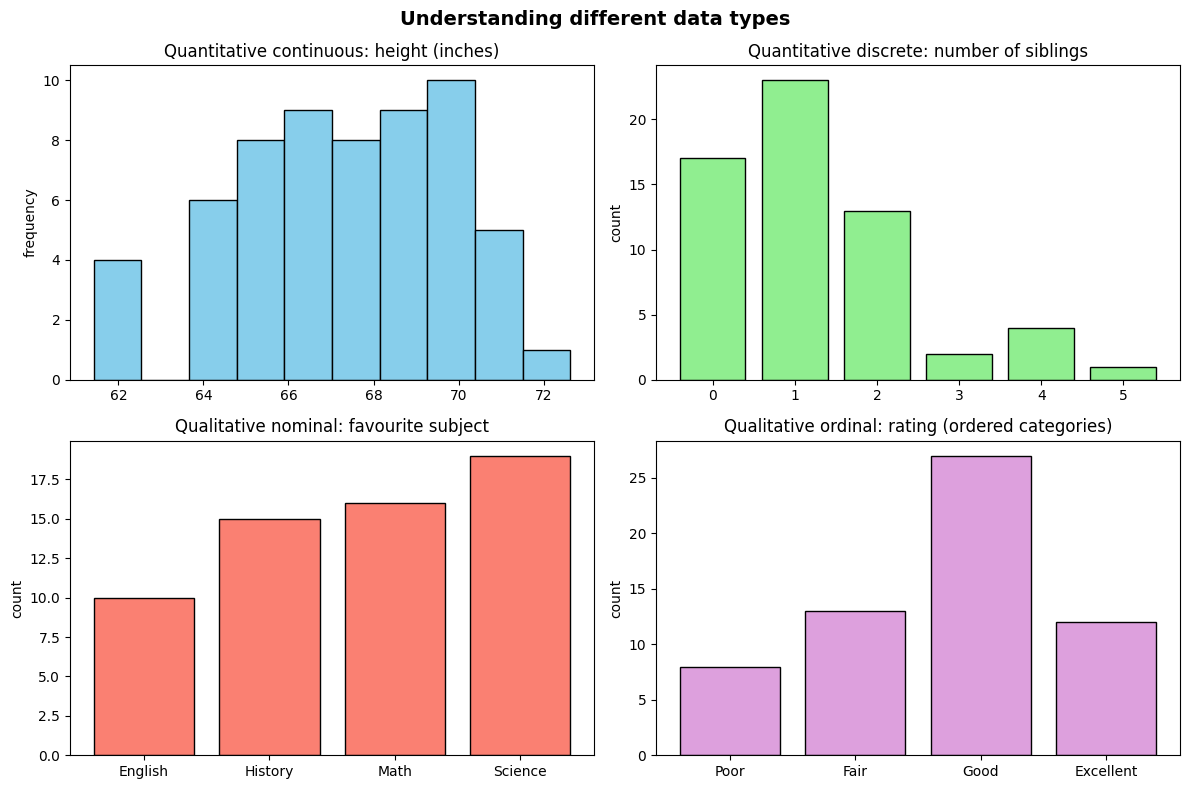

In [ ]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(10)
heights   = rng.normal(68, 3, 60)                       # quantitative, continuous (inches)
siblings  = rng.poisson(1.5, 60)                        # quantitative, discrete
subjects  = rng.choice(['Math', 'Science', 'English', 'History'], 60)           # qualitative, nominal
ratings   = rng.choice(['Poor', 'Fair', 'Good', 'Excellent'], 60, p=[0.1, 0.25, 0.4, 0.25])   # qualitative, ordinal

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Understanding different data types', fontsize=14, fontweight='bold')

ax[0, 0].hist(heights, bins=10, color='skyblue', edgecolor='black')
ax[0, 0].set_title('Quantitative continuous: height (inches)')

v, c = np.unique(siblings, return_counts=True)
ax[0, 1].bar(v, c, color='lightgreen', edgecolor='black')
ax[0, 1].set_title('Quantitative discrete: number of siblings'); ax[0, 1].set_xticks(v)

names, c = np.unique(subjects, return_counts=True)
ax[1, 0].bar(names, c, color='salmon', edgecolor='black')
ax[1, 0].set_title('Qualitative nominal: favourite subject')

order = ['Poor', 'Fair', 'Good', 'Excellent']
c = [np.sum(ratings == r) for r in order]
ax[1, 1].bar(order, c, color='plum', edgecolor='black')
ax[1, 1].set_title('Qualitative ordinal: rating (ordered categories)')

for a in ax.ravel(): a.set_ylabel('count')
ax[0, 0].set_ylabel('frequency')
plt.tight_layout()
plt.show()

# **1.3 Pandas – creating, saving and inspecting a data set**

We follow the story of **20 students** and their marks in Math, Physics and English. Kevin (STU011) struggles in all subjects and Lily (STU012) excels — they will show how outliers influence statistics. A data set is created from a Python dictionary, saved as a CSV file and read back, as is usual in real projects.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_data = {
    'Student_ID': [f'STU{i:03d}' for i in range(1, 21)],
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Ethan', 'Fiona', 'George', 'Hannah', 'Ian', 'Julia',
             'Kevin', 'Lily', 'Mike', 'Nina', 'Oscar', 'Paula', 'Quinn', 'Rita', 'Sam', 'Tina'],
    'Math':    [85, 78, 92, 67, 88, 95, 72, 81, 90, 76, 15, 99, 82, 79, 87, 91, 74, 83, 68, 89],
    'Physics': [78, 82, 85, 70, 91, 88, 76, 79, 84, 72, 25, 98, 80, 77, 86, 90, 73, 81, 69, 87],
    'English': [82, 76, 88, 71, 85, 92, 74, 80, 86, 78, 45, 99, 83, 79, 84, 89, 75, 82, 72, 88],
    'Gender':  ['F', 'M', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F'],
    'Class':   ['A', 'B'] * 10,
}
marks_df = pd.DataFrame(student_data)
print("The data set has", marks_df.shape[0], "students and", marks_df.shape[1], "columns")
display(marks_df)

# Save to a CSV file and read it back
marks_df.to_csv('student_marks_story.csv', index=False)
loaded_data = pd.read_csv('student_marks_story.csv')
print("\nSaved to 'student_marks_story.csv' and loaded back. First 5 rows:")
display(loaded_data.head())

The data set has 20 students and 7 columns


,Student_ID,Name,Math,Physics,English,Gender,Class
0,STU001,Alice,85,78,82,F,A
1,STU002,Bob,78,82,76,M,B
2,STU003,Charlie,92,85,88,M,A
3,STU004,Diana,67,70,71,F,B
4,STU005,Ethan,88,91,85,M,A
5,STU006,Fiona,95,88,92,F,B
6,STU007,George,72,76,74,M,A
7,STU008,Hannah,81,79,80,F,B
8,STU009,Ian,90,84,86,M,A
9,STU010,Julia,76,72,78,F,B



Saved to 'student_marks_story.csv' and loaded back. First 5 rows:


,Student_ID,Name,Math,Physics,English,Gender,Class
0,STU001,Alice,85,78,82,F,A
1,STU002,Bob,78,82,76,M,B
2,STU003,Charlie,92,85,88,M,A
3,STU004,Diana,67,70,71,F,B
4,STU005,Ethan,88,91,85,M,A


**Bird's-eye view.** `info()` shows column types and missing values; `describe()` gives count, mean, standard deviation, minimum, quartiles and maximum of every numeric column in one command.

In [ ]:
print("Data structure:")
loaded_data.info()
print("\nDescriptive statistics:")
display(loaded_data.describe().round(2))

Data structure:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Student_ID  20 non-null     str  
 1   Name        20 non-null     str  
 2   Math        20 non-null     int64
 3   Physics     20 non-null     int64
 4   English     20 non-null     int64
 5   Gender      20 non-null     str  
 6   Class       20 non-null     str  
dtypes: int64(3), str(4)
memory usage: 1.2 KB

Descriptive statistics:


,Math,Physics,English
count,20.00,20.00,20.00
mean,79.55,78.55,80.40
std,17.53,14.67,10.90
min,15.00,25.00,45.00
25%,75.50,75.25,75.75
50%,82.50,80.50,82.00
75%,89.25,86.25,86.50
max,99.00,98.00,99.00


# **1.4 The average trap – mean versus median**

Kevin's Math mark (15) is an **outlier**. The mean is pulled down by it, while the median — the middle value — is resistant. The *range* and *standard deviation* measure the spread of the marks.

In [ ]:
math = loaded_data['Math']
print(f"Mean   = {math.mean():.2f}")
print(f"Median = {math.median():.2f}")
print(f"The mean is lower than the median by {math.median() - math.mean():.2f} marks because of Kevin's mark of 15.\n")

print(f"Range = {math.max() - math.min()}   (Lily 99 - Kevin 15)")
print(f"Standard deviation of Math marks = {math.std():.2f}")
print("\nStandard deviation of each subject (which is the most stable?):")
print(loaded_data[['Math', 'Physics', 'English']].std().round(2))

Mean   = 79.55
Median = 82.50
The mean is lower than the median by 2.95 marks because of Kevin's mark of 15.

Range = 84   (Lily 99 - Kevin 15)
Standard deviation of Math marks = 17.53

Standard deviation of each subject (which is the most stable?):
Math       17.53
Physics    14.67
English    10.90
dtype: float64


**Visualising the outlier.** The histogram shows the shape of the class; the box plot marks values far from the rest as separate points (here, Kevin).

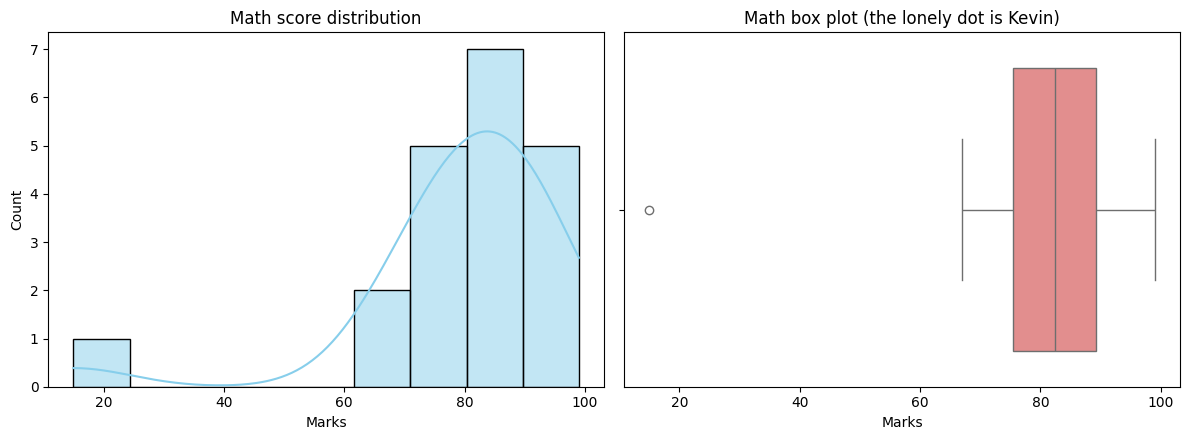

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(loaded_data['Math'], kde=True, color='skyblue', ax=ax[0])
ax[0].set_title('Math score distribution'); ax[0].set_xlabel('Marks')
sns.boxplot(x=loaded_data['Math'], color='lightcoral', ax=ax[1])
ax[1].set_title('Math box plot (the lonely dot is Kevin)'); ax[1].set_xlabel('Marks')
plt.tight_layout()
plt.show()

**Finding groups with quartiles.** The 75th percentile separates the top 25% ("creamy layer") and the 25th percentile the bottom 25% ("needs attention"). **Group comparison:** `groupby` computes statistics for every group in one line.

In [ ]:
top_cutoff, bottom_cutoff = math.quantile(0.75), math.quantile(0.25)
print(f"Top group:    Math > {top_cutoff}      Bottom group: Math < {bottom_cutoff}")
print("\nTop performers:");       display(loaded_data[loaded_data['Math'] > top_cutoff][['Name', 'Math']])
print("Needs attention:");        display(loaded_data[loaded_data['Math'] < bottom_cutoff][['Name', 'Math']])

print("\nMean marks by gender:")
display(loaded_data.groupby('Gender')[['Math', 'Physics', 'English']].mean().round(2))
print("Median marks by gender (the 'Kevin effect' disappears):")
display(loaded_data.groupby('Gender')[['Math', 'Physics', 'English']].median())

Top group:    Math > 89.25      Bottom group: Math < 75.5

Top performers:


,Name,Math
2,Charlie,92
5,Fiona,95
8,Ian,90
11,Lily,99
15,Paula,91


Needs attention:


,Name,Math
3,Diana,67
6,George,72
10,Kevin,15
16,Quinn,74
18,Sam,68



Mean marks by gender:


,Math,Physics,English
Gender,,,
F,84.5,82.0,84.0
M,74.6,75.1,76.8


Median marks by gender (the 'Kevin effect' disappears):


,Math,Physics,English
Gender,,,
F,84.0,80.0,82.0
M,80.0,81.0,79.5


# **1.5 Reading data from an Excel or CSV file**

Real data usually comes from a spreadsheet. We write the marks of the three subjects to an Excel file (no header row), read it back with `pd.read_excel`, and convert it to a NumPy array. (On Google Colab a file stored on Google Drive is read in the same way — see the commented lines.)

In [ ]:
# --- On Google Colab, to read a file stored on Google Drive, use:
# from google.colab import drive
# drive.mount('/content/drive')
# filename = "/content/drive/MyDrive/Marks.xlsx"
# For a CSV file use pd.read_csv(filename, header=None) instead of pd.read_excel.

# Here we first create the file so that the notebook runs anywhere
loaded_data[['Math', 'Physics', 'English']].to_excel('Marks.xlsx', header=False, index=False)

df = pd.read_excel('Marks.xlsx', header=None)
data = df.values.astype(float)               # 20 x 3 array: one row per student, one column per subject
print("Shape of the data array:", data.shape)
display(df.head())
print("Overall mean =", data.mean().round(3), "  median =", np.median(data), "  std =", data.std().round(3))

Shape of the data array: (20, 3)


,0,1,2
0,85,78,82
1,78,82,76
2,92,85,88
3,67,70,71
4,88,91,85


Overall mean = 79.5   median = 82.0   std = 14.269


**Selecting parts of an array** (indexing starts from 0):

| To get | Code |
|---|---|
| first row | `data[0]` |
| first column | `data[:, 0]` |
| one element | `data[i, j]` |
| rows a to b−1 | `data[a:b]` |
| columns a to b−1 | `data[:, a:b]` |
| sub-matrix | `data[a:b, c:d]` |

In [ ]:
print("First row (student 1)      :", data[0])
print("Third row (student 3)      :", data[2])
print("Rows 1 to 3                :\n", data[1:4])
print("First column (Math marks)  :", data[:, 0])
print("Sub-matrix rows 0-1, cols 1-2:\n", data[0:2, 1:3])
print("Column means (Math, Physics, English):", data.mean(axis=0).round(2))

First row (student 1)      : [85. 78. 82.]
Third row (student 3)      : [92. 85. 88.]
Rows 1 to 3                :
 [[78. 82. 76.]
 [92. 85. 88.]
 [67. 70. 71.]]
First column (Math marks)  : [85. 78. 92. 67. 88. 95. 72. 81. 90. 76. 15. 99. 82. 79. 87. 91. 74. 83.
 68. 89.]
Sub-matrix rows 0-1, cols 1-2:
 [[78. 82.]
 [82. 76.]]
Column means (Math, Physics, English): [79.55 78.55 80.4 ]


# **1.6 SciPy – probability distributions**

`scipy.stats` provides every common distribution with the same methods: `pmf` (discrete) or `pdf` (continuous), `cdf`, `ppf`, `mean`, `var`, `rvs`.

* **Binomial** – $n=10$ trials with success probability $p=0.5$: $P(X=4)$
* **Poisson** – mean rate $\lambda=3$: $P(X=2)$
* **Normal** – mean 50, standard deviation 5: $P(X\le55)$

In [ ]:
from scipy.stats import binom, poisson, norm

print("Binomial (n=10, p=0.5):  P(X = 4)  =", round(binom.pmf(4, 10, 0.5), 6))
print("Poisson  (lambda=3)   :  P(X = 2)  =", round(poisson.pmf(2, 3), 6))
print("Normal   (50, 5²)     :  P(X <= 55) =", round(norm.cdf(55, loc=50, scale=5), 6))

Binomial (n=10, p=0.5):  P(X = 4)  = 0.205078
Poisson  (lambda=3)   :  P(X = 2)  = 0.224042
Normal   (50, 5²)     :  P(X <= 55) = 0.841345


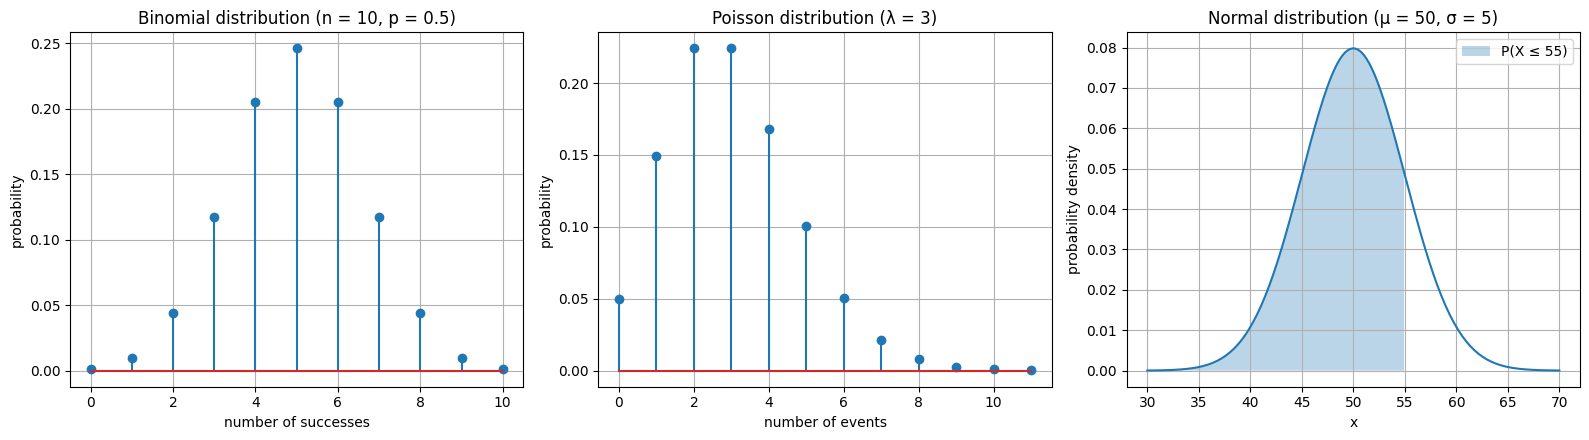

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

x = np.arange(0, 11)
ax[0].stem(x, binom.pmf(x, 10, 0.5))
ax[0].set_title('Binomial distribution (n = 10, p = 0.5)'); ax[0].set_xlabel('number of successes'); ax[0].set_ylabel('probability')

x = np.arange(0, 12)
ax[1].stem(x, poisson.pmf(x, 3))
ax[1].set_title('Poisson distribution (λ = 3)'); ax[1].set_xlabel('number of events'); ax[1].set_ylabel('probability')

x = np.linspace(30, 70, 200)
ax[2].plot(x, norm.pdf(x, loc=50, scale=5))
ax[2].fill_between(x, norm.pdf(x, 50, 5), where=x <= 55, alpha=0.3, label='P(X ≤ 55)')
ax[2].set_title('Normal distribution (μ = 50, σ = 5)'); ax[2].set_xlabel('x'); ax[2].set_ylabel('probability density'); ax[2].legend()
for a in ax: a.grid(True)
plt.tight_layout()
plt.show()

# **1.7 Generating a random process (introduction)**

A **random process** is a collection of random variables indexed by time. A single time series is one *realization* (sample path). Below, *white noise* (independent standard normal values) is generated: first one realization, then five realizations to show that every run of the experiment gives a different path.

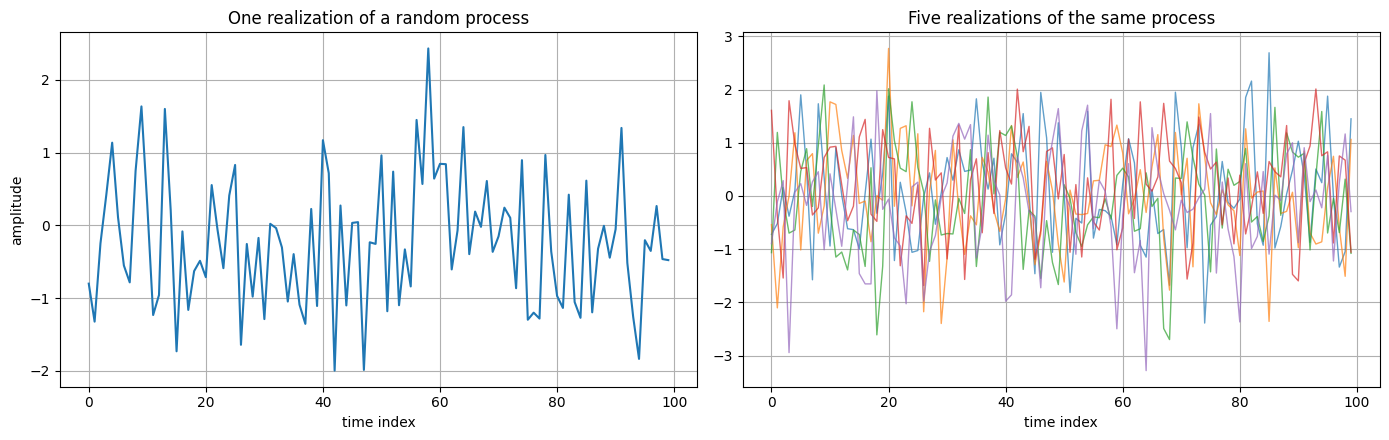

Mean of the single realization: -0.224   variance: 0.7791 (theory: 0 and 1)


In [ ]:
rng = np.random.default_rng(5)
random_process = rng.standard_normal(100)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(random_process)
ax[0].set_title('One realization of a random process'); ax[0].set_xlabel('time index'); ax[0].set_ylabel('amplitude')

for k in range(5):
    ax[1].plot(rng.standard_normal(100), alpha=0.7, lw=1)
ax[1].set_title('Five realizations of the same process'); ax[1].set_xlabel('time index')
for a in ax: a.grid(True)
plt.tight_layout()
plt.show()
print("Mean of the single realization:", random_process.mean().round(4), "  variance:", random_process.var().round(4), "(theory: 0 and 1)")

# **Result**

The Python libraries NumPy, SciPy, Pandas, Matplotlib and Seaborn were used to compute statistics, create/save/read data (CSV and Excel), identify and visualise data types, detect an outlier, compare groups, evaluate Binomial, Poisson and Normal probabilities ($P(X=4)=0.2051$, $P(X=2)=0.2240$, $P(X\le55)=0.8413$) and generate a random process.

# **Discussion**

One extreme value (Kevin's 15) lowered the Math mean noticeably but barely changed the median — so for data with outliers the median describes the "typical" student better, and a box plot reveals the outlier immediately. Statistics should therefore always be accompanied by a picture. `scipy.stats` gives a uniform interface for all distributions, which is exploited in Experiments 4–8, and a random process is simply a family of random sequences — the topic of Experiments 9 and 10.

# **Practice Problems**

**Problem 1.** Create a Pandas DataFrame with the heights (cm) of 15 students of your class. Find the mean, median, standard deviation and the 25th and 75th percentiles, and draw a histogram and a box plot.

**Problem 2.** Write the data of Problem 1 to a CSV file and read it back with `pd.read_csv`. Add a column `Category` with the values `'Tall'` for heights above the median and `'Short'` otherwise, and find the mean height of each category using `groupby`.

**Problem 3.** Use `scipy.stats` to find (i) $P(X=3)$ for a Binomial$(8,\,0.4)$ variable, (ii) $P(X\le 2)$ for a Poisson variable with $\lambda=1.5$, (iii) $P(40<X<60)$ for a Normal$(50,\,8^2)$ variable.

---

# **EXPERIMENT 2**

---

# **Measures of Central Tendency with Visualization**

# **Aim:**

To compute the **mean, median and mode** of a data set using Python, to visualise its distribution with a **histogram and a box plot**, and to interpret how outliers affect the measures of central tendency.

# **Software required:**

Python 3, NumPy, Pandas, Matplotlib, SciPy

# **Theory:**

* **Mean** — sum of the observations divided by their number: $\;\bar x=\dfrac{1}{n}\sum x_i$. Sensitive to extreme values (outliers).
* **Median** — the middle value of the sorted data. If $n$ is odd it is the middle term; if $n$ is even it is the average of the two middle terms. Robust to outliers.
* **Mode** — the most frequent value. A data set may be unimodal, bimodal or multimodal.
* **Histogram** — bar graph of the frequencies of class intervals (shape of the distribution).
* **Box plot** — shows the five-number summary: minimum, $Q_1$, median, $Q_3$, maximum; values beyond $1.5\times$ IQR from the quartiles are drawn as outliers.

**Shape of the distribution:** symmetric → mean $\approx$ median $\approx$ mode; right-skewed → mean > median > mode; left-skewed → mean < median < mode.

**Engineering relevance:** quality control, sensor data analysis, reliability studies.

# **Algorithm:**

1. Input the data.
2. Mean = (sum of data) / (number of data).
3. Sort the data; the median is the middle value (or the average of the two middle values).
4. Count the frequency of every value; the mode is the value with the highest frequency.
5. Plot the histogram and the box plot; mark the mean, median and mode.
6. Interpret the results.

# **2.1 Computing mean, median and mode from the definitions**

The three functions below follow the definitions (no statistics library is used). The results are then checked against NumPy, `statistics` and SciPy.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

data = [12, 15, 18, 20, 22, 15, 18, 25, 30, 18]
print("Given data:", data)

def calculate_mean(data):
    """Mean = (sum of all observations) / (number of observations)"""
    return sum(data) / len(data)

def calculate_median(data):
    """Median = middle value of the sorted data"""
    s = sorted(data)
    n = len(s)
    return (s[n // 2 - 1] + s[n // 2]) / 2 if n % 2 == 0 else s[n // 2]

def calculate_mode(data):
    """Mode = value with the highest frequency"""
    return Counter(data).most_common(1)[0][0]

mean_value, median_value, mode_value = calculate_mean(data), calculate_median(data), calculate_mode(data)
print("\nMeasures of central tendency (from definitions):")
print("Mean   :", mean_value)
print("Median :", median_value)
print("Mode   :", mode_value, " (appears", Counter(data)[mode_value], "times)")
print("\nSorted data:", sorted(data))

Given data: [12, 15, 18, 20, 22, 15, 18, 25, 30, 18]

Measures of central tendency (from definitions):
Mean   : 19.3
Median : 18.0
Mode   : 18  (appears 3 times)

Sorted data: [12, 15, 15, 18, 18, 18, 20, 22, 25, 30]


In [ ]:
import statistics
from scipy import stats

print("Check with libraries:")
print("NumPy      : mean =", np.mean(data), " median =", np.median(data))
print("statistics : mean =", statistics.mean(data), " median =", statistics.median(data), " mode =", statistics.mode(data),
      " all modes =", statistics.multimode(data))
print("SciPy      : mode =", stats.mode(data, keepdims=False).mode)

Check with libraries:
NumPy      : mean = 19.3  median = 18.0
statistics : mean = 19.3  median = 18.0  mode = 18  all modes = [18]
SciPy      : mode = 18


# **2.2 Visualising the data**

The histogram shows the frequency distribution and the box plot the median, quartiles, range and possible outliers. The vertical lines mark the three measures of central tendency.

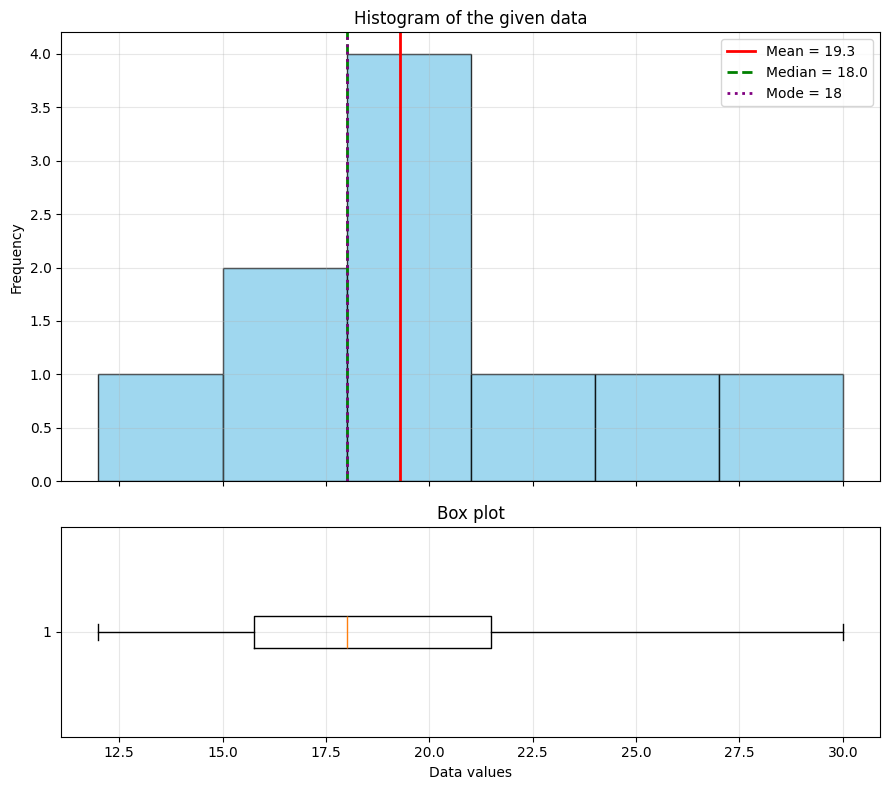

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(9, 8), gridspec_kw={'height_ratios': [3, 1.4]}, sharex=True)

ax[0].hist(data, bins=6, color='skyblue', edgecolor='black', alpha=0.8)
ax[0].axvline(mean_value, color='red', lw=2, label=f'Mean = {mean_value:.1f}')
ax[0].axvline(median_value, color='green', lw=2, ls='--', label=f'Median = {median_value:.1f}')
ax[0].axvline(mode_value, color='purple', lw=2, ls=':', label=f'Mode = {mode_value}')
ax[0].set_ylabel('Frequency'); ax[0].set_title('Histogram of the given data'); ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].boxplot(data, vert=False)
ax[1].set_xlabel('Data values'); ax[1].set_title('Box plot'); ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **2.3 Effect of an outlier on the mean, median and mode**

Add one faulty reading, 100, to the data. The mean changes a lot, the median only slightly, and the mode not at all.

Original data      mean =  19.30   median =  18.0   mode = 18
With outlier 100   mean =  26.64   median =  18.0   mode = 18


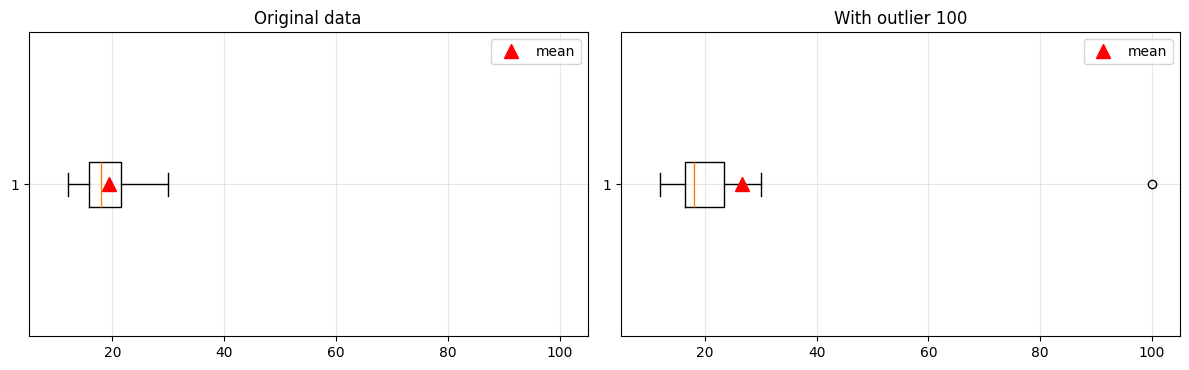

In [ ]:
data_out = data + [100]
rows = [("Original data", np.mean(data), np.median(data), calculate_mode(data)),
        ("With outlier 100", np.mean(data_out), np.median(data_out), calculate_mode(data_out))]
for name, m, md_, mo in rows:
    print(f"{name:18s} mean = {m:6.2f}   median = {md_:5.1f}   mode = {mo}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for axis, d, title in zip(ax, (data, data_out), ('Original data', 'With outlier 100')):
    axis.boxplot(d, vert=False); axis.plot(np.mean(d), 1, 'r^', ms=10, label='mean')
    axis.set_title(title); axis.set_xlim(5, 105); axis.legend(); axis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **2.4 Central tendency of data read from a file**

The marks of the 20 students in three subjects (Experiment 1) are stored in an Excel file without a header. Each *column* is a subject, so we compute the measures along the columns.

Data after transposing (rows = data sets): (3, 20)


,Mean,Median,Mode
Math,79.55,82.5,no mode
Physics,78.55,80.5,no mode
English,80.40,82.0,82.0


(All Math and all Physics marks are different, so these two data sets have no mode.)


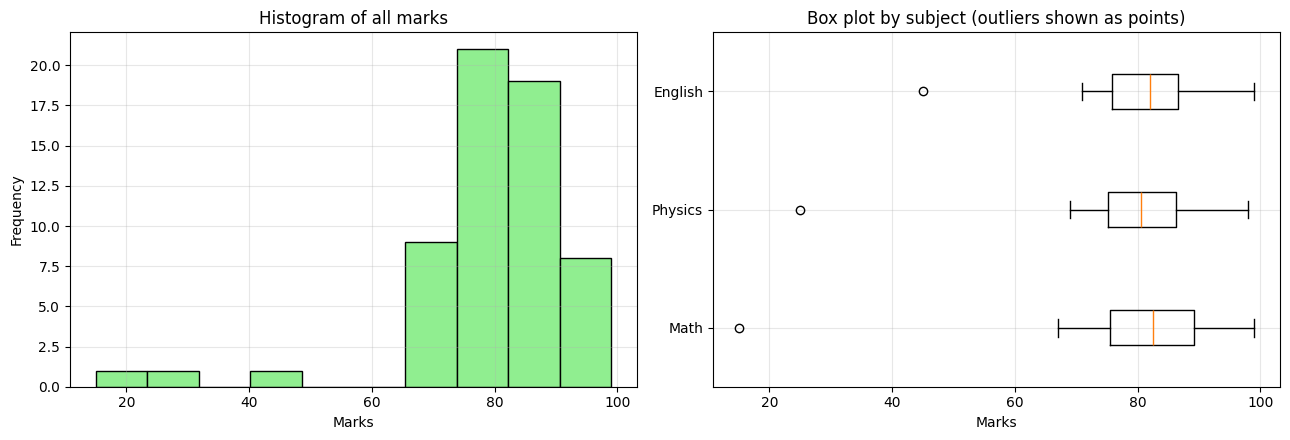

In [ ]:
import pandas as pd

student_marks = {
    'Math':    [85, 78, 92, 67, 88, 95, 72, 81, 90, 76, 15, 99, 82, 79, 87, 91, 74, 83, 68, 89],
    'Physics': [78, 82, 85, 70, 91, 88, 76, 79, 84, 72, 25, 98, 80, 77, 86, 90, 73, 81, 69, 87],
    'English': [82, 76, 88, 71, 85, 92, 74, 80, 86, 78, 45, 99, 83, 79, 84, 89, 75, 82, 72, 88],
}
pd.DataFrame(student_marks).to_excel('Marks.xlsx', header=False, index=False)      # create the file
# (On Colab:  filename = "/content/drive/MyDrive/Marks.xlsx")

df = pd.read_excel('Marks.xlsx', header=None)
D = df.values.astype(float).T                        # transpose: each ROW is now one subject (data set)
print("Data after transposing (rows = data sets):", D.shape)

def mode_of(arr):
    """Most frequent value; returns 'no mode' if every value occurs only once."""
    values, counts = np.unique(arr, return_counts=True)
    return values[np.argmax(counts)] if counts.max() > 1 else 'no mode'

result = pd.DataFrame({"Mean": D.mean(axis=1).round(2), "Median": np.median(D, axis=1),
                       "Mode": [mode_of(r) for r in D]}, index=['Math', 'Physics', 'English'])
display(result)
print("(All Math and all Physics marks are different, so these two data sets have no mode.)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(D.flatten(), bins=10, color='lightgreen', edgecolor='black')
ax[0].set_xlabel('Marks'); ax[0].set_ylabel('Frequency'); ax[0].set_title('Histogram of all marks')
ax[1].boxplot(list(D), vert=False, tick_labels=['Math', 'Physics', 'English'])
ax[1].set_xlabel('Marks'); ax[1].set_title('Box plot by subject (outliers shown as points)')
for a in ax: a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Application Problem 1 – Analysing student test scores**

**Problem statement.** A school wants to analyse the performance of a class in a mathematics exam. The scores of 30 students are 55, 67, 89, 45, 67, 72, 67, 78, 88, 93, 45, 56, 78, 89, 90, 67, 76, 83, 45, 67, 85, 91, 60, 79, 73, 68, 85, 92, 60, 55. The administration wants a quick overview: the average performance, the most common score and the middle score.

Student test scores analysis
----------------------------------------
Number of students : 30
Mean score         : 72.17
Median score       : 72.5
Mode score         : 67  (obtained by 5 students)


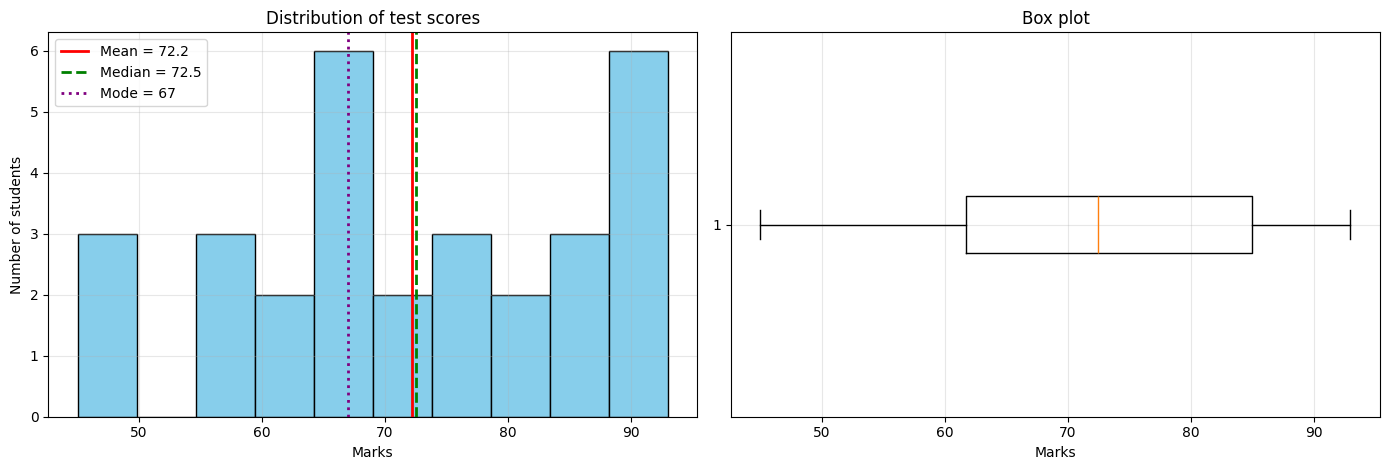

In [ ]:
scores = [55, 67, 89, 45, 67, 72, 67, 78, 88, 93,
          45, 56, 78, 89, 90, 67, 76, 83, 45, 67,
          85, 91, 60, 79, 73, 68, 85, 92, 60, 55]

mean_score, median_score = np.mean(scores), np.median(scores)
mode_score, mode_count = Counter(scores).most_common(1)[0]

print("Student test scores analysis")
print("-" * 40)
print("Number of students :", len(scores))
print(f"Mean score         : {mean_score:.2f}")
print(f"Median score       : {median_score}")
print(f"Mode score         : {mode_score}  (obtained by {mode_count} students)")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].hist(scores, bins=10, color='skyblue', edgecolor='black')
ax[0].axvline(mean_score, color='red', lw=2, label=f'Mean = {mean_score:.1f}')
ax[0].axvline(median_score, color='green', lw=2, ls='--', label=f'Median = {median_score:.1f}')
ax[0].axvline(mode_score, color='purple', lw=2, ls=':', label=f'Mode = {mode_score}')
ax[0].set_xlabel('Marks'); ax[0].set_ylabel('Number of students'); ax[0].set_title('Distribution of test scores'); ax[0].legend()
ax[1].boxplot(scores, vert=False); ax[1].set_xlabel('Marks'); ax[1].set_title('Box plot')
for a in ax: a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Application Problem 2 – Compressive strength of concrete cylinders**

**Problem statement.** An engineer analyses the compressive strength (MPa) of 30 concrete cylinders used in the foundation of a commercial building, tested under controlled laboratory conditions: 28.5, 30.2, 29.8, 31.1, 28.9, 30.0, 30.4, 29.9, 31.2, 30.6, 28.7, 29.5, 30.3, 29.7, 30.8, 30.1, 30.5, 30.0, 29.3, 31.0, 28.8, 30.9, 29.6, 30.2, 31.3, 30.0, 29.4, 30.7, 28.6, 30.3. The objective is to analyse the results statistically to evaluate consistency and quality. Besides the three measures of centre we compute the standard deviation and the **coefficient of variation** $CV=\sigma/\bar x\times100\%$ (a small CV means consistent concrete).

Concrete strength analysis
----------------------------------------
Mean strength   : 30.010 MPa
Median strength : 30.050 MPa
Mode            : 30.0 MPa
Std. deviation  : 0.794 MPa
Coefficient of variation : 2.64 %
Minimum / maximum        : 28.5 / 31.3 MPa


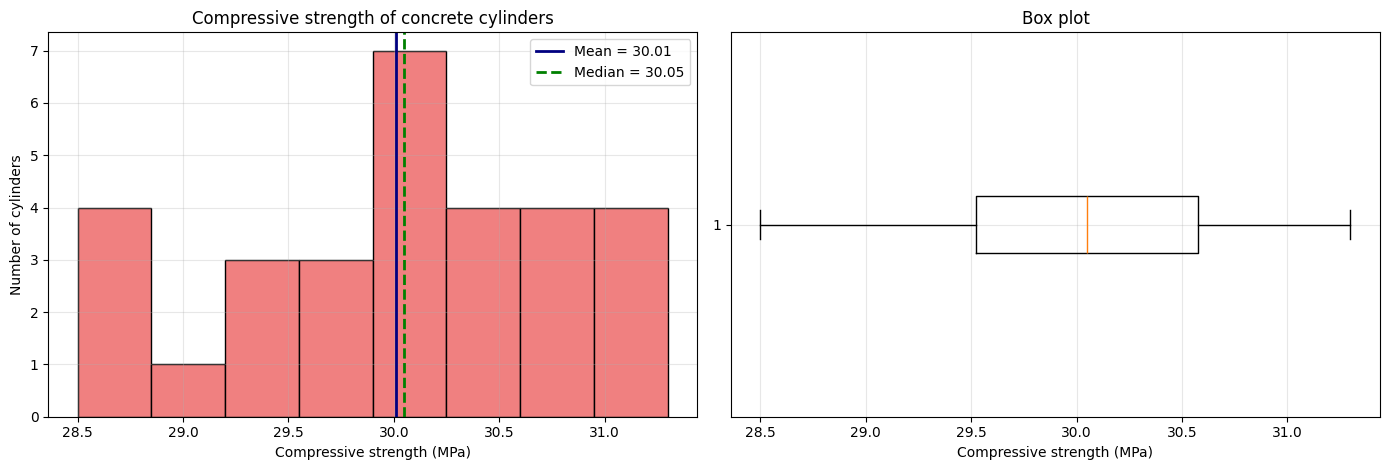

In [ ]:
strength = [28.5, 30.2, 29.8, 31.1, 28.9, 30.0, 30.4, 29.9, 31.2, 30.6,
            28.7, 29.5, 30.3, 29.7, 30.8, 30.1, 30.5, 30.0, 29.3, 31.0,
            28.8, 30.9, 29.6, 30.2, 31.3, 30.0, 29.4, 30.7, 28.6, 30.3]

mean_s, median_s = np.mean(strength), np.median(strength)
mode_s = Counter(strength).most_common(1)[0][0]
std_s = np.std(strength, ddof=1)

print("Concrete strength analysis")
print("-" * 40)
print(f"Mean strength   : {mean_s:.3f} MPa")
print(f"Median strength : {median_s:.3f} MPa")
print(f"Mode            : {mode_s} MPa")
print(f"Std. deviation  : {std_s:.3f} MPa")
print(f"Coefficient of variation : {std_s / mean_s * 100:.2f} %")
print(f"Minimum / maximum        : {min(strength)} / {max(strength)} MPa")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].hist(strength, bins=8, color='lightcoral', edgecolor='black')
ax[0].axvline(mean_s, color='navy', lw=2, label=f'Mean = {mean_s:.2f}')
ax[0].axvline(median_s, color='green', lw=2, ls='--', label=f'Median = {median_s:.2f}')
ax[0].set_xlabel('Compressive strength (MPa)'); ax[0].set_ylabel('Number of cylinders')
ax[0].set_title('Compressive strength of concrete cylinders'); ax[0].legend()
ax[1].boxplot(strength, vert=False); ax[1].set_xlabel('Compressive strength (MPa)'); ax[1].set_title('Box plot')
for a in ax: a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Result**

* The mean, median and mode of the data `[12, 15, 18, 20, 22, 15, 18, 25, 30, 18]` were computed from the definitions as $19.3$, $18.0$ and $18$, and agreed with NumPy, `statistics` and SciPy.
* A single outlier (100) raised the mean from $19.3$ to $26.64$, while the median ($18.0$) and the mode ($18$) did not change at all, showing the robustness of the median and mode.
* For the 30 test scores the mean was $72.17$, the median $72.5$ and the mode $67$ (obtained by 5 students). For the concrete cylinders the mean was $30.01$ MPa, the median $30.05$ MPa and the mode $30.0$ MPa with a standard deviation of $0.79$ MPa — a coefficient of variation of only $2.6\%$.

# **Discussion**

The mean uses every observation and is the natural "balance point", but it is dragged by outliers; the median depends only on the order of the data and is robust; the mode is the only measure usable for categorical data. When the mean and median are nearly equal (as for the concrete strengths) the distribution is roughly symmetric; a large gap signals skewness or outliers. In engineering, a small coefficient of variation shows that a process (such as concrete production) is consistent — the topic of the next experiment.

# **Practice Problems**

**Problem 1.** The response times (ms) of a server are `120, 118, 125, 122, 119, 121, 124, 123, 400`. Compute the mean, median and mode. Which measure describes the typical response time best? Draw a box plot.

**Problem 2.** Without using any statistics library, write a function that returns **all** modes of a data set (it may be bimodal). Test it on `[1, 2, 2, 3, 3, 4]`.

**Problem 3.** Read a column of data from a CSV file of your choice with `pd.read_csv`, and display the mean, median and mode together with a histogram on which the three values are marked. State whether the data is skewed.

---

# **EXPERIMENT 3**

---

# **Measures of Dispersion – Range and Standard Deviation**

# **Aim:**

To study and compute the measures of dispersion — **range, variance and standard deviation** — for a given data set (ungrouped and grouped) using Python, and to interpret the variability of engineering data.

# **Software required:**

Python 3, NumPy, `statistics`, Pandas, Matplotlib

# **Theory:**

Measures of dispersion describe how far the observations are spread around the average. Two data sets can have the same mean but very different spreads.

**1. Range** $=X_{\max}-X_{\min}$. Simple, but depends only on the two extreme values and is very sensitive to outliers.

**2. Variance and standard deviation.** For $n$ observations with mean $\bar x$:

$$\text{Population:}\;\;\sigma=\sqrt{\frac1n\sum_{i=1}^{n}(x_i-\bar x)^2},\qquad \text{Sample:}\;\;s=\sqrt{\frac1{n-1}\sum_{i=1}^{n}(x_i-\bar x)^2}.$$

Use the *population* formula when the data are the complete population and the *sample* formula (divide by $n-1$) when the data are a sample used to estimate the population.

**3. Grouped data** (class intervals with frequencies $f_i$ and mid-points $x_i$):

$$\bar x=\frac{\sum f_ix_i}{\sum f_i},\qquad \sigma=\sqrt{\frac{\sum f_i(x_i-\bar x)^2}{\sum f_i}}$$

**4. Coefficient of variation** $CV=\sigma/\bar x\times100\%$ compares the variability of data with different units or means.

**Importance in engineering:** noise analysis in signals, variation in sensor measurements, quality control of components, performance analysis of communication systems.

# **Algorithm:**

1. Input the data set.
2. Find the maximum and minimum values and compute the range.
3. Compute the mean.
4. Find the deviation of each value from the mean, square the deviations, average them (divide by $n$ or $n-1$) and take the square root.
5. Display the results.

# **3.1 Range and standard deviation from the definitions**

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

def calculate_mean(data):
    return sum(data) / len(data)

def calculate_range(data):
    return max(data) - min(data)

def calculate_std_dev(data, sample=False):
    """sigma = sqrt( sum (x - mean)^2 / n )   (divide by n-1 when sample=True)"""
    mean = calculate_mean(data)
    total = sum((x - mean) ** 2 for x in data)
    return math.sqrt(total / (len(data) - 1 if sample else len(data)))

data = [12, 15, 20, 22, 25, 30, 35]
print("Data                      :", data)
print("-" * 55)
print("Mean                      :", round(calculate_mean(data), 4))
print("Range                     :", calculate_range(data))
print("Population std. deviation :", round(calculate_std_dev(data), 4))
print("Sample std. deviation     :", round(calculate_std_dev(data, sample=True), 4))
print("Variance (population)     :", round(calculate_std_dev(data) ** 2, 4))

Data                      : [12, 15, 20, 22, 25, 30, 35]
-------------------------------------------------------
Mean                      : 22.7143
Range                     : 23
Population std. deviation : 7.4779
Sample std. deviation     : 8.077
Variance (population)     : 55.9184


**Using libraries.** NumPy: `np.ptp` (range), `np.std(ddof=0 or 1)`, `np.var`; the `statistics` module: `pstdev` (population) and `stdev` (sample). All must agree with the hand-written functions.

In [ ]:
import statistics
import pandas as pd

data2 = [10, 15, 8, 22, 17, 13, 9]

summary = pd.DataFrame({
    "From definitions": [calculate_range(data2), calculate_std_dev(data2), calculate_std_dev(data2, True)],
    "NumPy":            [np.ptp(data2), np.std(data2), np.std(data2, ddof=1)],
    "statistics":       [max(data2) - min(data2), statistics.pstdev(data2), statistics.stdev(data2)],
}, index=["Range", "Population std. dev.", "Sample std. dev."]).round(4)
print("Data:", data2)
display(summary)

q1, q3 = np.percentile(data2, [25, 75])
print(f"Interquartile range (IQR = Q3 - Q1) = {q3 - q1}   (Q1 = {q1}, Q3 = {q3})")
print(f"Coefficient of variation = {np.std(data2, ddof=1) / np.mean(data2) * 100:.2f} %")

Data: [10, 15, 8, 22, 17, 13, 9]


,From definitions,NumPy,statistics
Range,14.0000,14.0000,14.0000
Population std. dev.,4.6247,4.6247,4.6247
Sample std. dev.,4.9952,4.9952,4.9952


Interquartile range (IQR = Q3 - Q1) = 6.5   (Q1 = 9.5, Q3 = 16.0)
Coefficient of variation = 37.20 %


# **3.2 Same mean, different spread**

Two data sets with the same mean but different standard deviations: the range and standard deviation reveal the difference that the mean cannot.

Data set A: mean =  50.14   range =  18.45   std. deviation =  3.10
Data set B: mean =  50.23   range =  71.67   std. deviation = 11.85


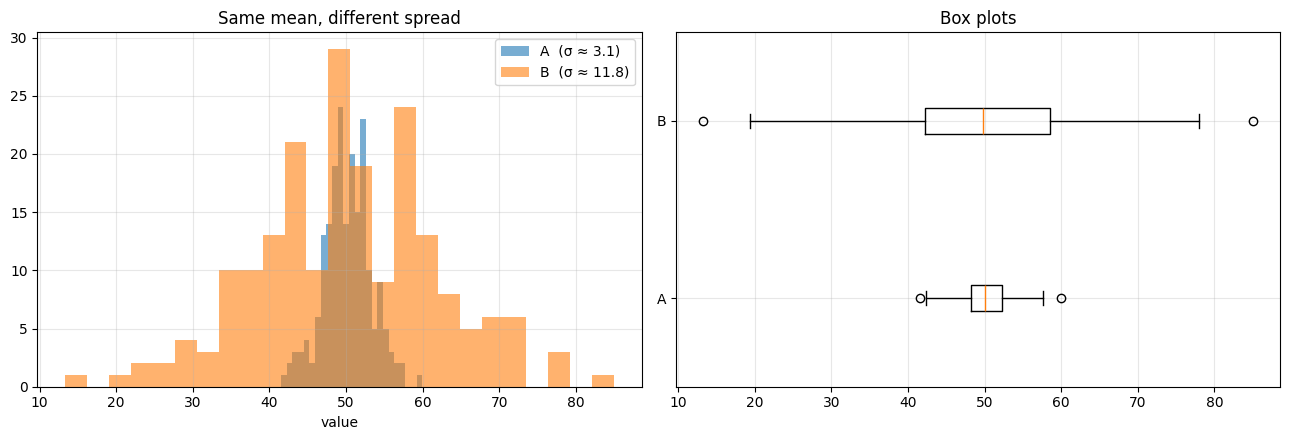

In [ ]:
rng = np.random.default_rng(3)
A_set = rng.normal(50, 3, 200)
B_set = rng.normal(50, 12, 200)

for name, d in (("Data set A", A_set), ("Data set B", B_set)):
    print(f"{name}: mean = {d.mean():6.2f}   range = {np.ptp(d):6.2f}   std. deviation = {d.std(ddof=1):5.2f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(A_set, bins=25, alpha=0.6, label=f'A  (σ ≈ {A_set.std():.1f})', color='tab:blue')
ax[0].hist(B_set, bins=25, alpha=0.6, label=f'B  (σ ≈ {B_set.std():.1f})', color='tab:orange')
ax[0].set_title('Same mean, different spread'); ax[0].set_xlabel('value'); ax[0].legend()
ax[1].boxplot([A_set, B_set], vert=False); ax[1].set_yticklabels(['A', 'B']); ax[1].set_title('Box plots')
for a in ax: a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **3.3 Grouped data**

When the data are given as class intervals with frequencies, the class **mid-points** represent the values. Marks of 50 students:

| Class interval | 0–10 | 10–20 | 20–30 | 30–40 | 40–50 |
|---|---|---|---|---|---|
| Frequency | 5 | 8 | 15 | 16 | 6 |

Class intervals : [(0, 10), (10, 20), (20, 30), (30, 40), (40, 50)]
Frequencies     : [5, 8, 15, 16, 6]   (total = 50 )
Mid-points      : [5.0, 15.0, 25.0, 35.0, 45.0]
Mean               = 27.00
Standard deviation = 11.49
Range (approx.)    = 50  (upper limit of last class - lower limit of first class)


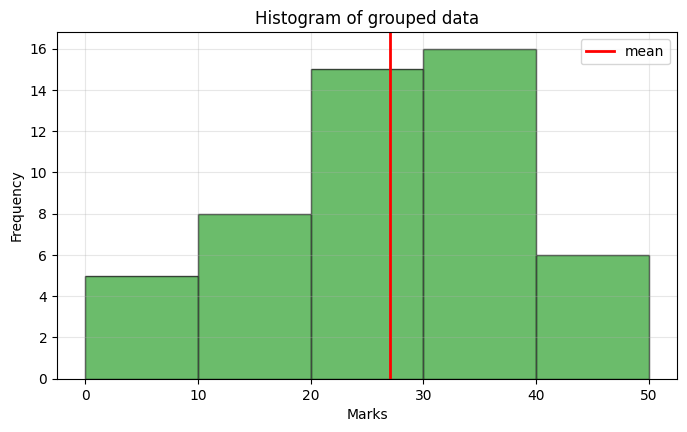

In [ ]:
classes = [(0, 10), (10, 20), (20, 30), (30, 40), (40, 50)]
frequencies = [5, 8, 15, 16, 6]

def calculate_midpoints(classes):
    return [(lo + hi) / 2 for lo, hi in classes]

def grouped_mean(mid, f):
    return sum(m * fi for m, fi in zip(mid, f)) / sum(f)

def grouped_std(mid, f):
    mean = grouped_mean(mid, f)
    return math.sqrt(sum(fi * (m - mean) ** 2 for m, fi in zip(mid, f)) / sum(f))

mid = calculate_midpoints(classes)
print("Class intervals :", classes)
print("Frequencies     :", frequencies, "  (total =", sum(frequencies), ")")
print("Mid-points      :", mid)
print(f"Mean               = {grouped_mean(mid, frequencies):.2f}")
print(f"Standard deviation = {grouped_std(mid, frequencies):.2f}")
print(f"Range (approx.)    = {classes[-1][1] - classes[0][0]}  (upper limit of last class - lower limit of first class)")

plt.figure(figsize=(8, 4.5))
plt.bar(mid, frequencies, width=10, edgecolor='black', alpha=0.7, color='tab:green')
plt.axvline(grouped_mean(mid, frequencies), color='red', lw=2, label='mean')
plt.xlabel('Marks'); plt.ylabel('Frequency'); plt.title('Histogram of grouped data'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# **Application Problem 1 – Analysis of manufacturing tolerances**

**Problem statement.** A quality engineer analyses the diameter (mm) of metal rods produced by a CNC machine: 10.01, 10.03, 9.98, 10.05, 10.00, 10.02, 10.04, 9.99, 10.01, 10.03, 9.97, 10.06, 10.02, 10.01, 9.98, 10.00, 10.04, 9.96, 10.02, 10.01. Consistency is critical — too much variation may lead to assembly failures. To assess precision, the engineer calculates the **range and standard deviation** of the rod diameters. A control chart (values with the lines mean ± 3σ) shows whether any rod is unusual.

Rod diameters (mm) analysis
---------------------------------------------
Number of rods            : 20
Mean diameter             : 10.0115 mm
Range                     : 0.100 mm
Std. deviation (population): 0.0259 mm
Std. deviation (sample)    : 0.0266 mm
Mean ± 3σ limits          : 9.932 to 10.091 mm
Any rod outside the 3σ limits? False


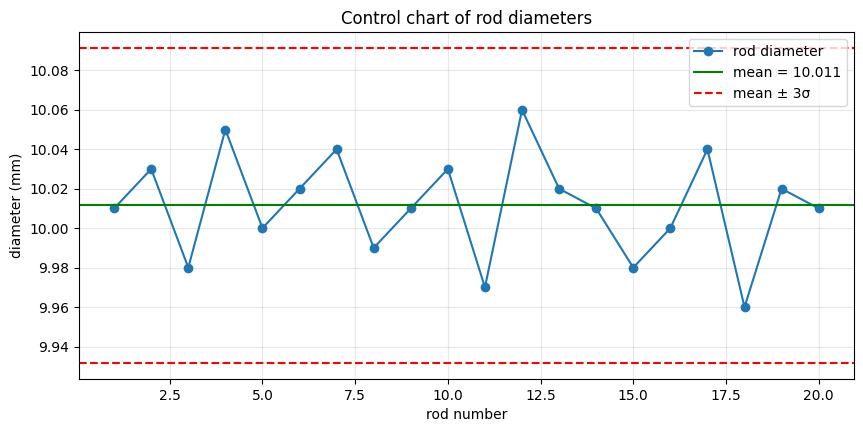

In [ ]:
rod = [10.01, 10.03, 9.98, 10.05, 10.00, 10.02, 10.04, 9.99, 10.01, 10.03,
       9.97, 10.06, 10.02, 10.01, 9.98, 10.00, 10.04, 9.96, 10.02, 10.01]

mean_r, range_r = calculate_mean(rod), calculate_range(rod)
std_pop, std_smp = calculate_std_dev(rod), calculate_std_dev(rod, sample=True)

print("Rod diameters (mm) analysis")
print("-" * 45)
print(f"Number of rods            : {len(rod)}")
print(f"Mean diameter             : {mean_r:.4f} mm")
print(f"Range                     : {range_r:.3f} mm")
print(f"Std. deviation (population): {std_pop:.4f} mm")
print(f"Std. deviation (sample)    : {std_smp:.4f} mm")
print(f"Mean ± 3σ limits          : {mean_r - 3 * std_smp:.3f} to {mean_r + 3 * std_smp:.3f} mm")
print("Any rod outside the 3σ limits?", any(abs(x - mean_r) > 3 * std_smp for x in rod))

plt.figure(figsize=(10, 4.5))
plt.plot(range(1, len(rod) + 1), rod, 'o-', label='rod diameter')
plt.axhline(mean_r, color='green', label=f'mean = {mean_r:.3f}')
plt.axhline(mean_r + 3 * std_smp, color='red', ls='--', label='mean ± 3σ')
plt.axhline(mean_r - 3 * std_smp, color='red', ls='--')
plt.xlabel('rod number'); plt.ylabel('diameter (mm)'); plt.title('Control chart of rod diameters'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# **Application Problem 2 – Sensor accuracy analysis in a manufacturing plant**

**Problem statement.** A sensor in a high-precision machine records the temperature every hour. The readings (°C) over a 10-hour shift are 22.4, 22.7, 22.5, 22.9, 22.8, 22.6, 22.7, 22.3, 22.9, 22.6. Calculate the range and the standard deviation of the readings.

Temperature readings (°C) analysis
---------------------------------------------
Mean temperature           : 22.64 °C
Range                      : 0.60 °C
Std. deviation (population): 0.191 °C
Std. deviation (sample)    : 0.201 °C


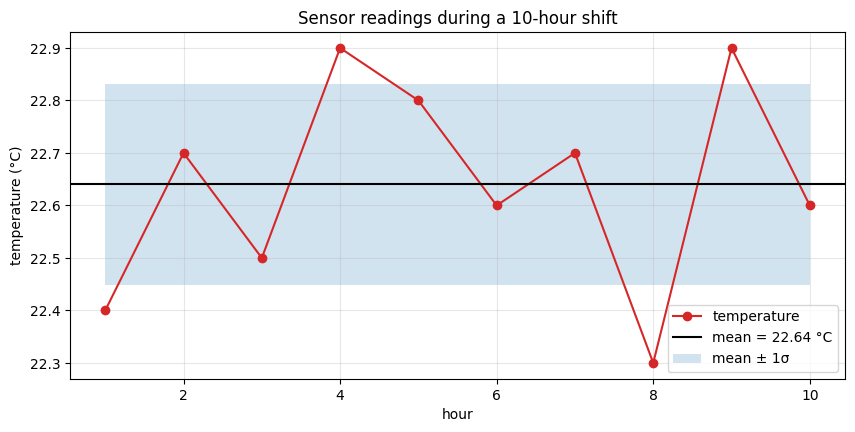

In [ ]:
temperatures = [22.4, 22.7, 22.5, 22.9, 22.8, 22.6, 22.7, 22.3, 22.9, 22.6]

mean_t, range_t = calculate_mean(temperatures), calculate_range(temperatures)
std_t = calculate_std_dev(temperatures)

print("Temperature readings (°C) analysis")
print("-" * 45)
print(f"Mean temperature           : {mean_t:.2f} °C")
print(f"Range                      : {range_t:.2f} °C")
print(f"Std. deviation (population): {std_t:.3f} °C")
print(f"Std. deviation (sample)    : {calculate_std_dev(temperatures, sample=True):.3f} °C")

plt.figure(figsize=(10, 4.5))
hours = range(1, len(temperatures) + 1)
plt.plot(hours, temperatures, 'o-', color='tab:red', label='temperature')
plt.axhline(mean_t, color='black', label=f'mean = {mean_t:.2f} °C')
plt.fill_between(hours, mean_t - std_t, mean_t + std_t, alpha=0.2, label='mean ± 1σ')
plt.xlabel('hour'); plt.ylabel('temperature (°C)'); plt.title('Sensor readings during a 10-hour shift'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# **Result**

The range and standard deviation were computed from the definitions (population and sample versions), with NumPy and with the `statistics` module, for ungrouped and grouped data, with identical results. For the rod diameters the range was $0.10$ mm and the standard deviation $0.026$ mm (population) or $0.027$ mm (sample), with no rod outside the $\pm3\sigma$ limits, and for the sensor readings the range was $0.6\,^\circ$C with a standard deviation of $0.19\,^\circ$C (population) or $0.20\,^\circ$C (sample).

# **Discussion**

The range uses only the two extreme observations, whereas the standard deviation uses all observations and is therefore the preferred measure of variability. A *small* standard deviation means that the readings are clustered closely around the mean (a precise process); a *large* one means wide scatter. Two data sets with the same mean can have very different spreads, so the mean must always be reported together with a measure of dispersion. Dividing by $n-1$ instead of $n$ gives a slightly larger value — an unbiased estimate of the population variance when only a sample is available.

# **Practice Problems**

**Problem 1.** Two machines produce bolts. Machine A: `9.9, 10.1, 10.0, 10.2, 9.8`; machine B: `9.5, 10.5, 10.0, 10.4, 9.6`. Compute the mean, range, standard deviation and coefficient of variation of each and decide which machine is more precise.

**Problem 2.** Show numerically that the sum of the deviations from the mean, $\sum(x_i-\bar x)$, is zero for any data set, and that the standard deviation is unchanged if the same constant is added to every value but is multiplied by $c$ if every value is multiplied by $c$.

**Problem 3.** The weights (kg) of 40 packages are grouped as 10–20: 4, 20–30: 9, 30–40: 14, 40–50: 8, 50–60: 5. Compute the mean and standard deviation from the grouped data and draw the histogram.

---

# **EXPERIMENT 4**

---

# **Probability of Successes of a Random Variable Following the Binomial Distribution**

# **Aim:**

To calculate the probability of obtaining exactly $x$ successes (and cumulative probabilities) in $n$ independent Bernoulli trials using the Binomial distribution, and to visualise the probability mass function (PMF).

# **Software required:**

Python 3, NumPy, SciPy (`scipy.stats.binom`), Matplotlib, Pandas

# **Theory:**

A **Bernoulli trial** has two outcomes, success (probability $p$) and failure (probability $q=1-p$). If $X$ is the number of successes in $n$ independent trials with the same $p$, then $X\sim\text{Binomial}(n,p)$ with

$$P(X=x)=\binom{n}{x}p^{x}(1-p)^{n-x},\qquad x=0,1,\dots,n$$

$$E[X]=np,\qquad \operatorname{Var}(X)=np(1-p).$$

**Cumulative probabilities:** $P(X\le x)=\sum_{k=0}^{x}P(X=k)$ (`binom.cdf`), $P(X>x)=1-P(X\le x)$ (`binom.sf`), and $P(a\le X\le b)=F(b)-F(a-1)$.

**Conditions:** fixed number of trials, only two outcomes, constant $p$, independent trials.

# **Algorithm:**

1. Import `binom` from `scipy.stats`.
2. Define the parameters $n$, $p$ and the number of successes $x$.
3. Compute $P(X=x)$ with `binom.pmf(x, n, p)`; cumulative probabilities with `binom.cdf`.
4. Display the results in a clear format.
5. Plot the complete PMF and highlight the required value(s).

# **4.1 Case: exactly 6 heads in 10 tosses of a fair coin**

$n=10,\;p=0.5,\;x=6$. The library value is checked against the formula $\binom{10}{6}(0.5)^6(0.5)^4$.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb
from scipy.stats import binom

n, p, x = 10, 0.5, 6

probability = binom.pmf(k=x, n=n, p=p)
by_formula = comb(n, x) * p ** x * (1 - p) ** (n - x)

print("Binomial probability calculation")
print("-" * 50)
print(f"Number of trials (n)        : {n}")
print(f"Probability of success (p)  : {p}")
print(f"Desired number of successes : {x}")
print("-" * 50)
print(f"P(X = {x}) from binom.pmf     : {probability:.6f}")
print(f"P(X = {x}) from the formula   : {by_formula:.6f}")
print(f"Mean np = {n * p},  variance np(1-p) = {n * p * (1 - p)},  std. deviation = {np.sqrt(n * p * (1 - p)):.4f}")

Binomial probability calculation
--------------------------------------------------
Number of trials (n)        : 10
Probability of success (p)  : 0.5
Desired number of successes : 6
--------------------------------------------------
P(X = 6) from binom.pmf     : 0.205078
P(X = 6) from the formula   : 0.205078
Mean np = 5.0,  variance np(1-p) = 2.5,  std. deviation = 1.5811


**Visualising the PMF.** The same PMF is drawn as a bar chart and as a stem plot; the required value $x=6$ is highlighted.

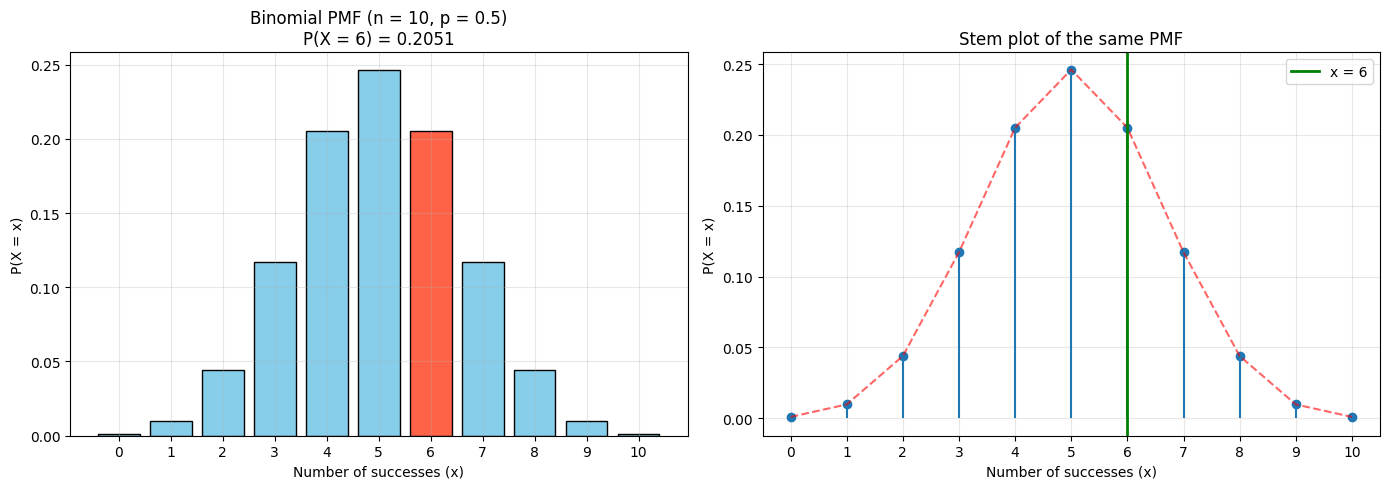

In [ ]:
possible_x = np.arange(0, n + 1)
pmf_values = binom.pmf(possible_x, n, p)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

colors = ['tomato' if k == x else 'skyblue' for k in possible_x]
ax[0].bar(possible_x, pmf_values, color=colors, edgecolor='black')
ax[0].set_title(f'Binomial PMF (n = {n}, p = {p})\nP(X = {x}) = {probability:.4f}')

ax[1].stem(possible_x, pmf_values, basefmt=' ')
ax[1].plot(possible_x, pmf_values, 'r--', alpha=0.6)
ax[1].axvline(x, color='green', lw=2, label=f'x = {x}')
ax[1].set_title('Stem plot of the same PMF'); ax[1].legend()

for a in ax:
    a.set_xlabel('Number of successes (x)'); a.set_ylabel('P(X = x)'); a.set_xticks(possible_x); a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **4.2 Cumulative probabilities**

The full distribution table, and the usual types of questions: $P(X\le4)$, $P(X>6)$ and $P(3\le X\le7)$. Remember $P(a\le X\le b)=F(b)-F(a-1)$ because $X$ is discrete.

,P(X = x),P(X <= x),P(X > x)
x,,,
0,0.0010,0.0010,0.9990
1,0.0098,0.0107,0.9893
2,0.0439,0.0547,0.9453
3,0.1172,0.1719,0.8281
4,0.2051,0.3770,0.6230
5,0.2461,0.6230,0.3770
6,0.2051,0.8281,0.1719
7,0.1172,0.9453,0.0547
8,0.0439,0.9893,0.0107


P(X <= 4)       = 0.377
P(X > 6)        = 0.1719    (= 1 - P(X <= 6))
P(3 <= X <= 7)  = 0.8906
Total of all probabilities = 1.0


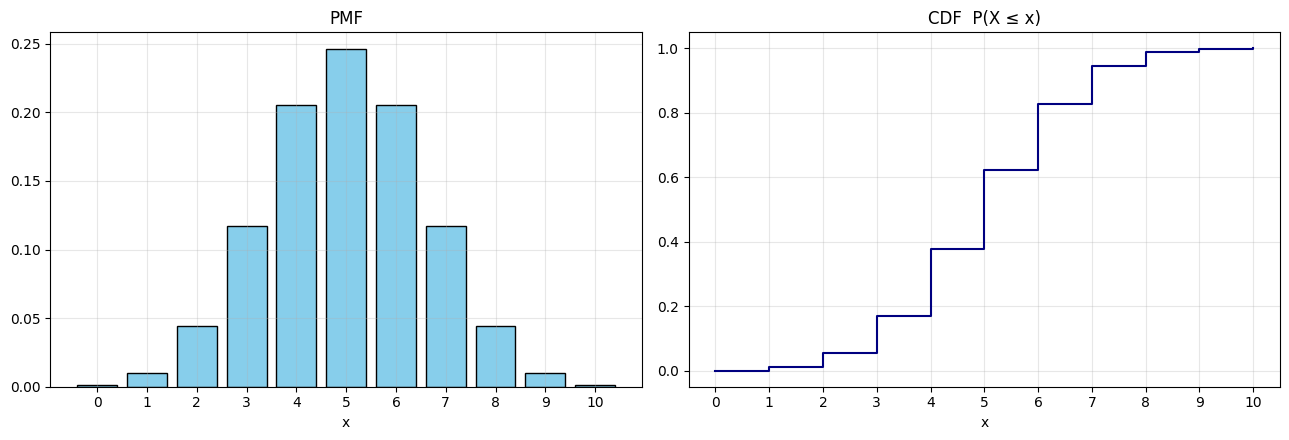

In [ ]:
table = pd.DataFrame({"x": possible_x, "P(X = x)": binom.pmf(possible_x, n, p),
                      "P(X <= x)": binom.cdf(possible_x, n, p), "P(X > x)": binom.sf(possible_x, n, p)}).set_index("x")
display(table.round(4))

print("P(X <= 4)       =", round(binom.cdf(4, n, p), 4))
print("P(X > 6)        =", round(binom.sf(6, n, p), 4), "   (= 1 - P(X <= 6))")
print("P(3 <= X <= 7)  =", round(binom.cdf(7, n, p) - binom.cdf(2, n, p), 4))
print("Total of all probabilities =", round(pmf_values.sum(), 10))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(possible_x, pmf_values, color='skyblue', edgecolor='black'); ax[0].set_title('PMF')
ax[1].step(possible_x, binom.cdf(possible_x, n, p), where='post', color='navy'); ax[1].set_title('CDF  P(X ≤ x)')
for a in ax: a.set_xlabel('x'); a.grid(True, alpha=0.3); a.set_xticks(possible_x)
plt.tight_layout()
plt.show()

# **4.3 Effect of the success probability and verification by simulation**

For $p<0.5$ the distribution is skewed to the right, for $p=0.5$ it is symmetric and for $p>0.5$ it is skewed to the left. A simulation of 10 000 experiments reproduces the theoretical probabilities.

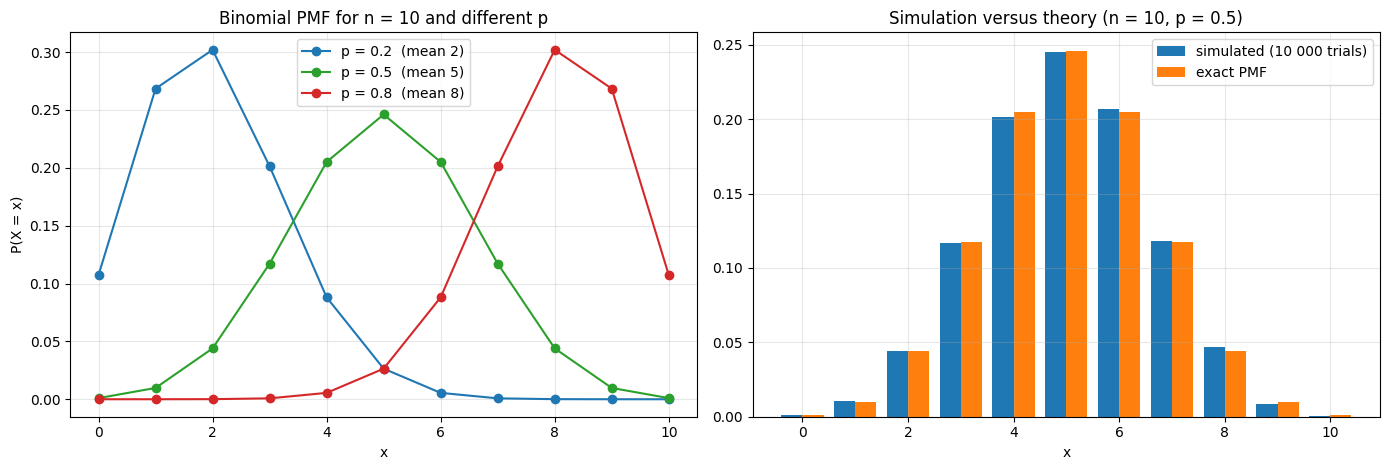

Simulated P(X = 6) = 0.2069   exact = 0.2051
Simulated mean = 5.003 (theory 5.0),   simulated variance = 2.507 (theory 2.5)


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for pp, color in zip((0.2, 0.5, 0.8), ('tab:blue', 'tab:green', 'tab:red')):
    ax[0].plot(possible_x, binom.pmf(possible_x, n, pp), 'o-', color=color, label=f'p = {pp}  (mean {n * pp:g})')
ax[0].set_title('Binomial PMF for n = 10 and different p'); ax[0].set_xlabel('x'); ax[0].set_ylabel('P(X = x)'); ax[0].legend(); ax[0].grid(True, alpha=0.3)

rng = np.random.default_rng(4)
sim = rng.binomial(n, p, size=10_000)
freq = np.bincount(sim, minlength=n + 1) / len(sim)
ax[1].bar(possible_x - 0.2, freq, width=0.4, label='simulated (10 000 trials)')
ax[1].bar(possible_x + 0.2, pmf_values, width=0.4, label='exact PMF')
ax[1].set_title('Simulation versus theory (n = 10, p = 0.5)'); ax[1].set_xlabel('x'); ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Simulated P(X = 6) = {freq[6]:.4f}   exact = {probability:.4f}")
print(f"Simulated mean = {sim.mean():.3f} (theory {n * p}),   simulated variance = {sim.var(ddof=1):.3f} (theory {n * p * (1 - p)})")

# **Application Problem 1 – Network packet transmission**

**Problem statement.** A network engineer analyses a wireless communication system. Each data packet has a 95% chance of being transmitted successfully. If 15 packets are transmitted, what is the probability of receiving (1) exactly 13 packets, (2) fewer than 13 packets, (3) between 5 and 10 packets successfully? Visualise the distribution of the number of successful packets (0 to 15).

Here $n=15$, $p=0.95$. "Fewer than 13" means $P(X\le12)$.

Network packet transmission (n = 15, p = 0.95)
Mean number of successful packets : 14.25     Variance : 0.7125
--------------------------------------------------------------
1. P(exactly 13 successful)      = 0.134752   (13.48%)
2. P(fewer than 13 successful)   = 0.036200   (3.62%)
3. P(between 5 and 10 inclusive) = 6.15e-04   (practically impossible)


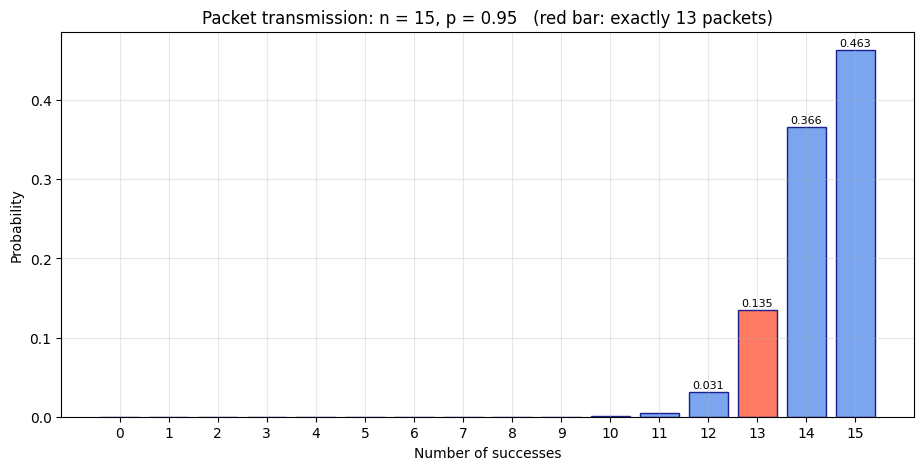

In [ ]:
def plot_binomial(n, p, highlight, title, color_hl='tomato', ax=None):
    ks = np.arange(0, n + 1)
    pmf = binom.pmf(ks, n, p)
    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(ks, pmf, color=[color_hl if k in highlight else 'cornflowerblue' for k in ks], edgecolor='navy', alpha=0.85)
    for k, v in zip(ks, pmf):
        if v > 0.01: ax.text(k, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)
    ax.set_title(title); ax.set_xlabel('Number of successes'); ax.set_ylabel('Probability'); ax.set_xticks(ks); ax.grid(True, alpha=0.3)
    if show: plt.show()

n1, p1 = 15, 0.95
p_exactly_13       = binom.pmf(13, n1, p1)
p_less_than_13     = binom.cdf(12, n1, p1)                          # P(X <= 12) = P(X < 13)
p_between_5_and_10 = binom.cdf(10, n1, p1) - binom.cdf(4, n1, p1)   # P(5 <= X <= 10)

print(f"Network packet transmission (n = {n1}, p = {p1})")
print(f"Mean number of successful packets : {n1 * p1:.2f}     Variance : {n1 * p1 * (1 - p1):.4f}")
print("-" * 62)
print(f"1. P(exactly 13 successful)      = {p_exactly_13:.6f}   ({p_exactly_13:.2%})")
print(f"2. P(fewer than 13 successful)   = {p_less_than_13:.6f}   ({p_less_than_13:.2%})")
print(f"3. P(between 5 and 10 inclusive) = {p_between_5_and_10:.2e}   (practically impossible)")

plot_binomial(n1, p1, {13}, f'Packet transmission: n = {n1}, p = {p1}   (red bar: exactly 13 packets)')

# **Application Problem 2 – Quality control in a manufacturing process**

**Problem statement.** An automated assembly line produces electronic components; each component has a 98% chance of passing inspection. An engineer randomly selects 20 components. Find the probability that (1) exactly 19 pass, (2) all 20 pass, (3) at most 18 pass, (4) between 17 and 19 (inclusive) pass. Visualise the distribution.

Here $n=20$, $p=0.98$.

Quality control – electronic components (n = 20, p = 0.98)
Mean number of good components : 19.60     Variance : 0.3920
--------------------------------------------------------------
1. P(exactly 19 pass)        = 0.272493   (27.25%)
2. P(all 20 pass)            = 0.667608   (66.76%)
3. P(at most 18 pass)        = 0.059899   (5.99%)
4. P(17 to 19 inclusive)     = 0.331792   (33.18%)


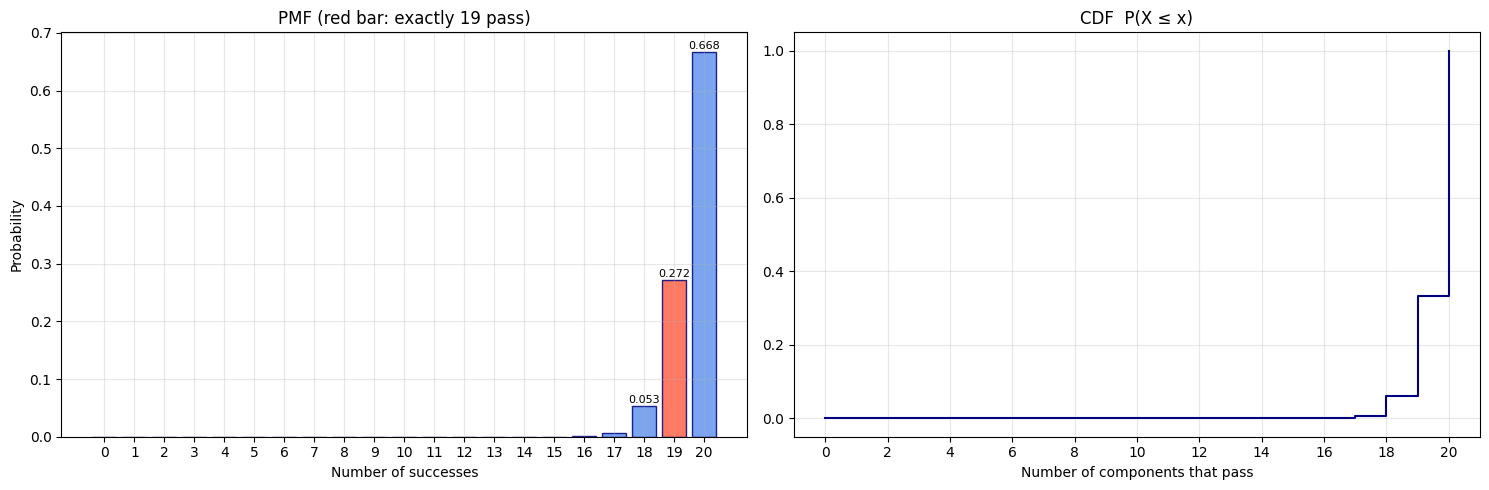

In [ ]:
n2, p2 = 20, 0.98
p_exactly_19   = binom.pmf(19, n2, p2)
p_all_20       = binom.pmf(20, n2, p2)
p_at_most_18   = binom.cdf(18, n2, p2)
p_17_to_19     = binom.cdf(19, n2, p2) - binom.cdf(16, n2, p2)

print(f"Quality control – electronic components (n = {n2}, p = {p2})")
print(f"Mean number of good components : {n2 * p2:.2f}     Variance : {n2 * p2 * (1 - p2):.4f}")
print("-" * 62)
print(f"1. P(exactly 19 pass)        = {p_exactly_19:.6f}   ({p_exactly_19:.2%})")
print(f"2. P(all 20 pass)            = {p_all_20:.6f}   ({p_all_20:.2%})")
print(f"3. P(at most 18 pass)        = {p_at_most_18:.6f}   ({p_at_most_18:.2%})")
print(f"4. P(17 to 19 inclusive)     = {p_17_to_19:.6f}   ({p_17_to_19:.2%})")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_binomial(n2, p2, {19}, 'PMF (red bar: exactly 19 pass)', ax=ax[0])
ax[1].step(np.arange(0, n2 + 1), binom.cdf(np.arange(0, n2 + 1), n2, p2), where='post', color='navy')
ax[1].set_title('CDF  P(X ≤ x)'); ax[1].set_xlabel('Number of components that pass'); ax[1].grid(True, alpha=0.3); ax[1].set_xticks(range(0, n2 + 1, 2))
plt.tight_layout()
plt.show()

# **Result**

* For $n=10$, $p=0.5$ the probability of exactly 6 successes is $P(X=6)=0.2051$ (20.51%); the library value agreed with the formula.
* Network packets ($n=15$, $p=0.95$): $P(X=13)=0.1348$, $P(X\le12)=0.0362$, and $P(5\le X\le10)\approx 6\times10^{-4}$ — receiving only 5 to 10 packets is practically impossible.
* Electronic components ($n=20$, $p=0.98$): $P(X=19)=0.2725$, $P(X=20)=0.6676$, $P(X\le18)=0.0599$, $P(17\le X\le19)=0.3318$.

# **Discussion**

The Binomial distribution models the number of successes in a fixed number of independent two-outcome trials. Its PMF peaks near the mean $np$ and its shape depends on $p$: symmetric at $p=0.5$ and increasingly skewed as $p$ approaches 0 or 1. In the high-reliability applications the probability piles up near $n$ (13–15 packets, 19–20 components), so the "all pass" event is the most likely one, and even a 2% defect rate gives a 33% chance that at least one of 20 components fails ($1-0.6676$). Simulation with 10 000 repetitions reproduced the exact PMF closely.

# **Practice Problems**

**Problem 1.** A multiple-choice test has 12 questions with 4 options each. A student guesses every answer. Find the probability of (i) exactly 3 correct answers, (ii) at least 6 correct answers, (iii) between 2 and 4 correct answers. Plot the PMF.

**Problem 2.** A fair die is rolled 8 times; a "success" is rolling a six. Find the mean and standard deviation of the number of sixes, and the probability of at least one six.

**Problem 3.** A communication channel flips a transmitted bit with probability 0.02. A 50-bit message is sent. Find the probability that (i) no bit is flipped, (ii) at most 2 bits are flipped. Check your answers by simulating $10^5$ messages.

---

# **EXPERIMENT 5**

---

# **Probability of an Event of a Random Variable Following the Poisson Distribution**

# **Aim:**

To calculate the probability of a given number of events occurring in a fixed interval of time or space using the Poisson distribution, and to visualise its PMF and CDF.

# **Software required:**

Python 3, NumPy, SciPy (`scipy.stats.poisson`), Matplotlib, Pandas

# **Theory:**

If events occur independently at a constant average rate, the number $X$ of events in an interval in which $\lambda$ events are expected follows the **Poisson distribution**:

$$P(X=x)=\frac{e^{-\lambda}\lambda^{x}}{x!},\qquad x=0,1,2,\dots$$

$$E[X]=\lambda,\qquad \operatorname{Var}(X)=\lambda\quad(\text{mean}=\text{variance}).$$

* The CDF is $P(X\le x)=\sum_{k=0}^{x}P(X=k)$ (`poisson.cdf`) and $P(X>x)=1-P(X\le x)$ (`poisson.sf`).
* If the rate is $r$ events per unit time and the interval has length $t$, then $\lambda=rt$.
* **Poisson approximation to the Binomial:** for large $n$ and small $p$, Binomial$(n,p)\approx$ Poisson$(\lambda=np)$.
* Typical uses: arrivals of calls or packets, defects per metre of wire, particle counts, failures per year.

# **Algorithm:**

1. Import `poisson` from `scipy.stats`.
2. Define the mean rate $\lambda$ and the number of events $x$.
3. Compute the PMF value `poisson.pmf(x, lam)` and cumulative probabilities.
4. Display the results.
5. Plot the PMF (bar chart) and the CDF (step plot).

# **5.1 Case: average rate of 4 events**

Find the probability of observing exactly 2 events (and exactly 3 events) when the average rate is $\lambda=4$.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import exp, factorial
from scipy.stats import poisson, binom

lam = 4
print(f"Poisson distribution with lambda = {lam}")
print("-" * 45)
for x in (2, 3):
    print(f"P(X = {x}) = {poisson.pmf(x, lam):.4f}      (formula: {exp(-lam) * lam ** x / factorial(x):.4f})")
print(f"P(X <= 2) = {poisson.cdf(2, lam):.4f}")
print(f"P(X > 6)  = {poisson.sf(6, lam):.4f}")
print(f"Mean = Variance = {lam};  standard deviation = {np.sqrt(lam):.3f}")

xs = np.arange(0, 11)
display(pd.DataFrame({"x": xs, "P(X = x)": poisson.pmf(xs, lam), "P(X <= x)": poisson.cdf(xs, lam)}).set_index("x").round(4).T)

Poisson distribution with lambda = 4
---------------------------------------------
P(X = 2) = 0.1465      (formula: 0.1465)
P(X = 3) = 0.1954      (formula: 0.1954)
P(X <= 2) = 0.2381
P(X > 6)  = 0.1107
Mean = Variance = 4;  standard deviation = 2.000


x,0,1,2,3,4,5,6,7,8,9,10
P(X = x),0.0183,0.0733,0.1465,0.1954,0.1954,0.1563,0.1042,0.0595,0.0298,0.0132,0.0053
P(X <= x),0.0183,0.0916,0.2381,0.4335,0.6288,0.7851,0.8893,0.9489,0.9786,0.9919,0.9972


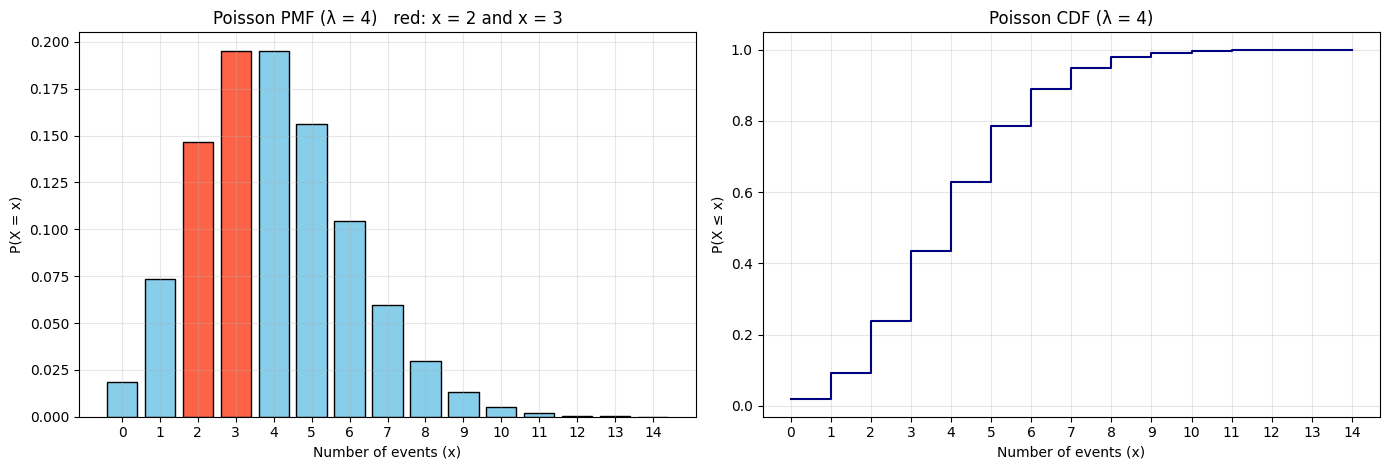

In [ ]:
x_values = np.arange(0, 15)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

ax[0].bar(x_values, poisson.pmf(x_values, lam), color=['tomato' if k in (2, 3) else 'skyblue' for k in x_values], edgecolor='black')
ax[0].set_title(f'Poisson PMF (λ = {lam})   red: x = 2 and x = 3')
ax[0].set_xlabel('Number of events (x)'); ax[0].set_ylabel('P(X = x)')

ax[1].step(x_values, poisson.cdf(x_values, lam), where='post', color='navy')
ax[1].set_title(f'Poisson CDF (λ = {lam})'); ax[1].set_xlabel('Number of events (x)'); ax[1].set_ylabel('P(X ≤ x)')
for a in ax: a.grid(True, alpha=0.3); a.set_xticks(x_values)
plt.tight_layout()
plt.show()

# **5.2 Comparing Poisson distributions and the Poisson approximation of the Binomial**

**Left:** a larger rate $\lambda$ moves the distribution to the right and makes it wider and more symmetric. **Right:** for $n=100$ and $p=0.03$ the Binomial probabilities are almost the same as the Poisson probabilities with $\lambda=np=3$.

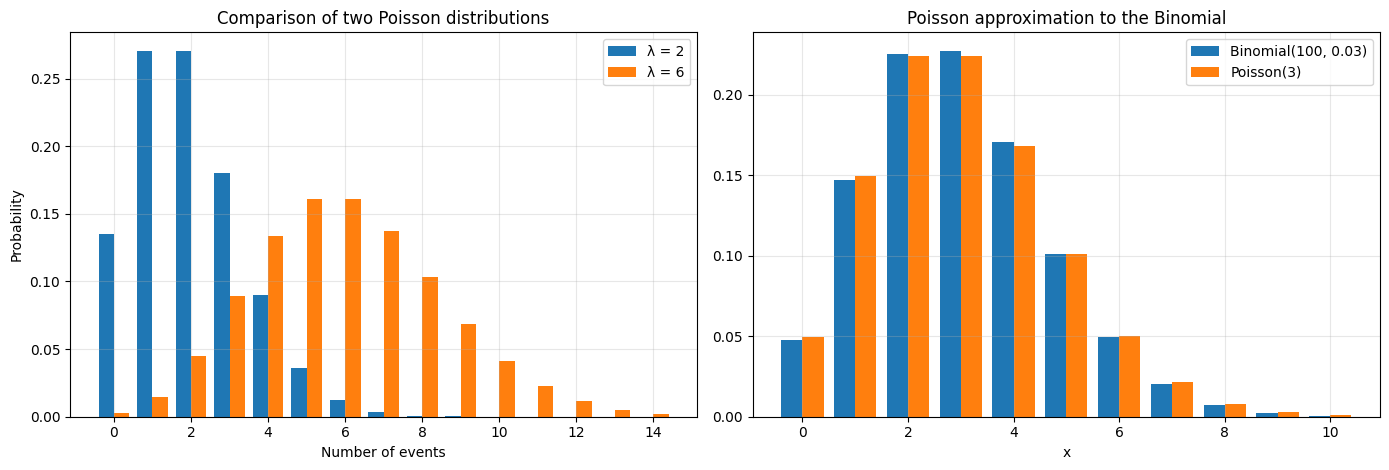

Largest difference between the Binomial and Poisson probabilities: 0.0034


In [ ]:
x = np.arange(0, 15)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].bar(x - 0.2, poisson.pmf(x, 2), width=0.4, label='λ = 2')
ax[0].bar(x + 0.2, poisson.pmf(x, 6), width=0.4, label='λ = 6')
ax[0].set_xlabel('Number of events'); ax[0].set_ylabel('Probability'); ax[0].set_title('Comparison of two Poisson distributions'); ax[0].legend()

k = np.arange(0, 11)
ax[1].bar(k - 0.2, binom.pmf(k, 100, 0.03), width=0.4, label='Binomial(100, 0.03)')
ax[1].bar(k + 0.2, poisson.pmf(k, 3), width=0.4, label='Poisson(3)')
ax[1].set_xlabel('x'); ax[1].set_title('Poisson approximation to the Binomial'); ax[1].legend()
for a in ax: a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Largest difference between the Binomial and Poisson probabilities:", np.max(np.abs(binom.pmf(k, 100, 0.03) - poisson.pmf(k, 3))).round(4))

# **5.3 Verification by simulation**

10 000 Poisson random numbers with $\lambda=4$: the sample mean and variance are both close to 4, and the relative frequencies follow the PMF.

Simulated mean = 3.966, simulated variance = 3.996   (theory: both = 4)
Simulated P(X = 3) = 0.1901   exact = 0.1954


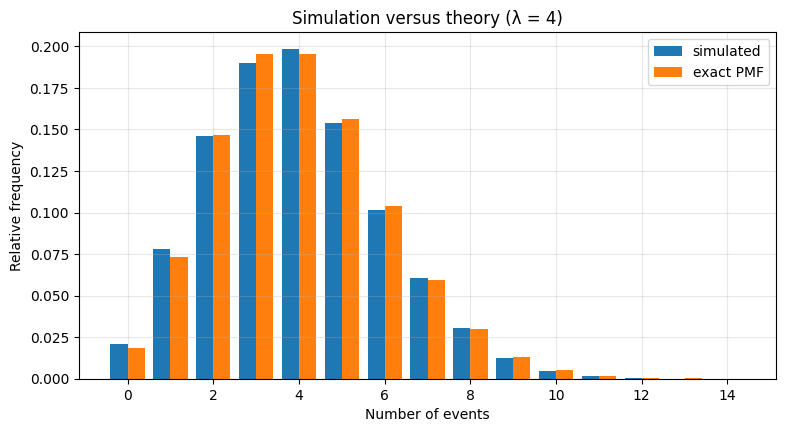

In [ ]:
rng = np.random.default_rng(5)
sim = rng.poisson(lam, 10_000)
print(f"Simulated mean = {sim.mean():.3f}, simulated variance = {sim.var(ddof=1):.3f}   (theory: both = {lam})")
print(f"Simulated P(X = 3) = {np.mean(sim == 3):.4f}   exact = {poisson.pmf(3, lam):.4f}")

freq = np.bincount(sim, minlength=15)[:15] / len(sim)
plt.figure(figsize=(9, 4.5))
plt.bar(x_values - 0.2, freq, width=0.4, label='simulated')
plt.bar(x_values + 0.2, poisson.pmf(x_values, lam), width=0.4, label='exact PMF')
plt.xlabel('Number of events'); plt.ylabel('Relative frequency'); plt.title('Simulation versus theory (λ = 4)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# **Application Problem 1 – Robot sensor event detection**

**Problem statement.** An autonomous mobile robot uses a proximity sensor to detect obstacles in a corridor; on average the sensor detects **4 obstacle events per minute** (Poisson). (1) Find the probability of exactly 3 obstacles in one minute. (2) Find the probability of at most 2 obstacles. (3) Plot the PMF for $x=0$ to $10$. (4) From the PMF, identify the most probable number of detections.

1. P(exactly 3 obstacles)   = 0.1954
2. P(at most 2 obstacles)   = 0.2381
4. Most probable number(s) of detections: [3 4]  (each with probability 0.1954)


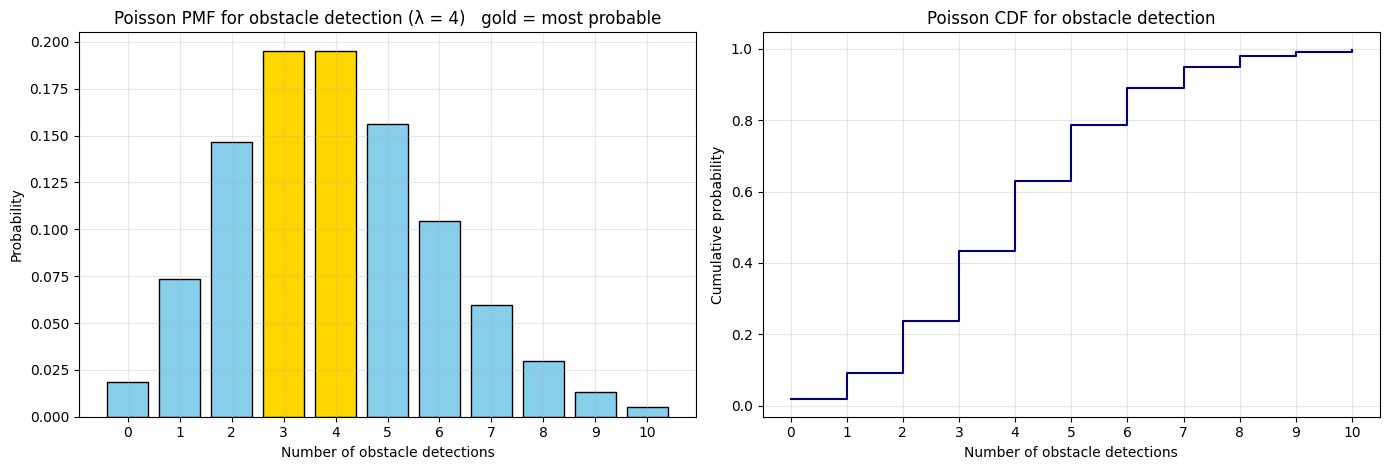

In [ ]:
lam1 = 4
prob_exact_3   = poisson.pmf(3, lam1)
prob_at_most_2 = poisson.cdf(2, lam1)
print(f"1. P(exactly 3 obstacles)   = {prob_exact_3:.4f}")
print(f"2. P(at most 2 obstacles)   = {prob_at_most_2:.4f}")

xv = np.arange(0, 11)
pmf = poisson.pmf(xv, lam1)
modes = xv[np.isclose(pmf, pmf.max())]
print(f"4. Most probable number(s) of detections: {modes}  (each with probability {pmf.max():.4f})")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].bar(xv, pmf, color=['gold' if k in modes else 'skyblue' for k in xv], edgecolor='black')
ax[0].set_title('Poisson PMF for obstacle detection (λ = 4)   gold = most probable')
ax[0].set_xlabel('Number of obstacle detections'); ax[0].set_ylabel('Probability')
ax[1].step(xv, poisson.cdf(xv, lam1), where='post', color='navy')
ax[1].set_title('Poisson CDF for obstacle detection'); ax[1].set_xlabel('Number of obstacle detections'); ax[1].set_ylabel('Cumulative probability')
for a in ax: a.grid(True, alpha=0.3); a.set_xticks(xv)
plt.tight_layout()
plt.show()

# **Application Problem 2 – Packet arrival in a robotic control system**

**Problem statement.** Control packets arrive at a processing unit at an average rate of **6 packets per second** (Poisson). (1) Find the probability that exactly 5 packets arrive in one second. (2) Find the probability that more than 6 packets arrive. (3) Plot the PMF for $x=0$ to $12$. (4) Plot the CDF and interpret it.

1. P(exactly 5 packets)      = 0.1606
2. P(more than 6 packets)    = 0.3937


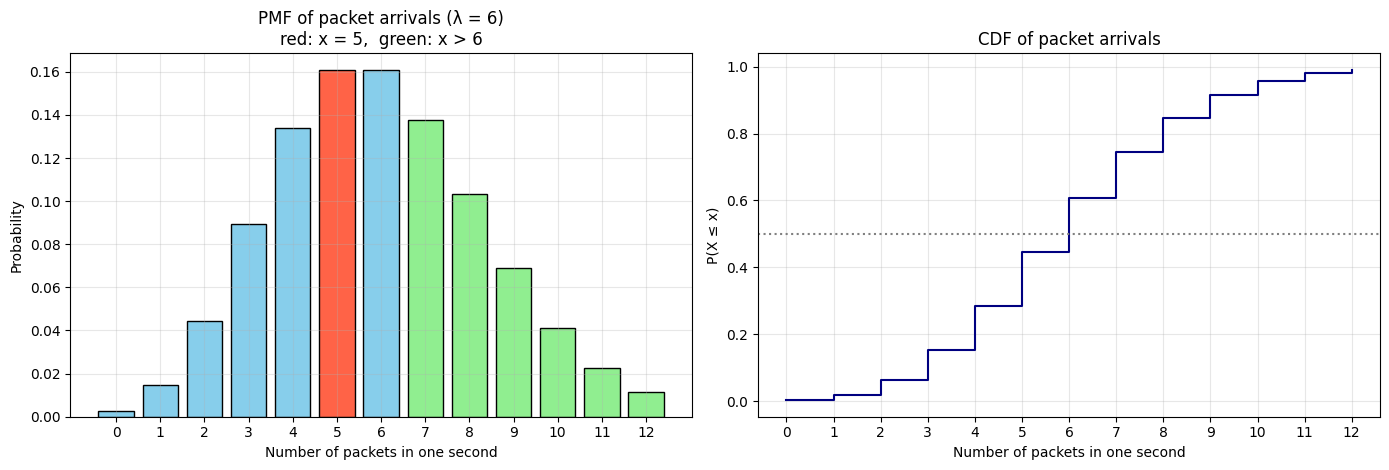

Interpretation of the CDF: P(X <= 8) = 0.8472 -> the unit receives at most 8 packets in about 85% of the seconds; the buffer must be designed for such bursts.


In [ ]:
lam2 = 6
prob_exact_5     = poisson.pmf(5, lam2)
prob_more_than_6 = 1 - poisson.cdf(6, lam2)       # P(X > 6) = 1 - P(X <= 6)
print(f"1. P(exactly 5 packets)      = {prob_exact_5:.4f}")
print(f"2. P(more than 6 packets)    = {prob_more_than_6:.4f}")

xv = np.arange(0, 13)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].bar(xv, poisson.pmf(xv, lam2), color=['tomato' if k == 5 else ('lightgreen' if k > 6 else 'skyblue') for k in xv], edgecolor='black')
ax[0].set_title('PMF of packet arrivals (λ = 6)\nred: x = 5,  green: x > 6')
ax[0].set_xlabel('Number of packets in one second'); ax[0].set_ylabel('Probability')
ax[1].step(xv, poisson.cdf(xv, lam2), where='post', color='navy')
ax[1].axhline(0.5, color='gray', ls=':')
ax[1].set_title('CDF of packet arrivals'); ax[1].set_xlabel('Number of packets in one second'); ax[1].set_ylabel('P(X ≤ x)')
for a in ax: a.grid(True, alpha=0.3); a.set_xticks(xv)
plt.tight_layout()
plt.show()
print("Interpretation of the CDF: P(X <= 8) =", round(poisson.cdf(8, lam2), 4),
      "-> the unit receives at most 8 packets in about 85% of the seconds; the buffer must be designed for such bursts.")

# **Result**

* For $\lambda=4$: $P(X=2)=0.1465$ and $P(X=3)=0.1954$.
* Robot sensor ($\lambda=4$): $P(X=3)=0.1954$, $P(X\le2)=0.2381$; the PMF has two equally likely peaks, at $x=3$ and $x=4$ (both $0.1954$).
* Packet arrivals ($\lambda=6$): $P(X=5)=0.1606$ and $P(X>6)=0.3937$.
* The simulation confirmed mean $\approx$ variance $\approx\lambda$, and the Poisson distribution with $\lambda=np=3$ approximated the Binomial$(100,0.03)$ closely.

# **Discussion**

The Poisson distribution models the *count* of random, independent events in a fixed interval when only the average rate is known; it is determined by a single parameter, and its mean and variance are equal. When $\lambda$ is an integer there are two modes, $\lambda-1$ and $\lambda$, as seen for $\lambda=4$ and $\lambda=6$. As $\lambda$ increases the distribution becomes wider and more symmetric. The CDF is the tool for questions like "what is the chance of at most $x$ events" — the basis for sizing buffers, queues and spare capacity in robotic and network systems.

# **Practice Problems**

**Problem 1.** A fibre-optic cable has on average 0.8 faults per kilometre (Poisson). Find the probability that a 3 km length has (i) no faults, (ii) exactly 2 faults, (iii) more than 3 faults. (Hint: $\lambda=0.8\times3$.)

**Problem 2.** A server receives on average 120 requests per minute. Find the probability of at least 2 requests in a given second. Use `poisson.sf`.

**Problem 3.** The number of misprints per page of a book is Poisson with mean 2. Estimate the number of pages with no misprint in a book of 300 pages. Verify your answer by simulating $10^4$ pages.

---

# **EXPERIMENT 6**

---

# **Probability of a Continuous Random Variable Following the Normal Distribution**

# **Aim:**

To compute probabilities for a normally distributed continuous random variable falling in specified intervals using Python, to apply the results to real-world problems, and to visualise the probability as a shaded area under the curve.

# **Software required:**

Python 3, NumPy, SciPy (`scipy.stats.norm`), Matplotlib

# **Theory:**

A continuous random variable $X\sim N(\mu,\sigma^2)$ has the bell-shaped probability density

$$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\,e^{-(x-\mu)^2/(2\sigma^2)}.$$

Probabilities are *areas under the curve*; they are obtained from the cumulative distribution function $F(x)=P(X\le x)$:

$$P(a\le X\le b)=F(b)-F(a),\qquad P(X>a)=1-F(a).$$

**Standardisation:** $Z=\dfrac{X-\mu}{\sigma}\sim N(0,1)$, with CDF $\Phi$, so $P(a\le X\le b)=\Phi\!\left(\frac{b-\mu}{\sigma}\right)-\Phi\!\left(\frac{a-\mu}{\sigma}\right)$.

**Empirical (68–95–99.7) rule:** about 68.27%, 95.45% and 99.73% of the values lie within $1\sigma$, $2\sigma$ and $3\sigma$ of the mean.

For a large sample of size $N$ the expected number of observations in an interval is $N\times P(\text{interval})$.

# **Algorithm:**

1. Import `norm` from `scipy.stats`, NumPy and Matplotlib.
2. Define the parameters $\mu$, $\sigma$ and the interval limits $a$, $b$ (or the tail condition).
3. Compute the CDF values with `norm.cdf(x, loc=mu, scale=sigma)` and the required probability.
4. For a sample of size $N$, multiply the probability by $N$ and round.
5. Plot the density curve and shade the region that corresponds to the probability.
6. Print and interpret the results.

# **Part A – Standard normal distribution**

**Problem.** Find $P(-1\le Z\le1)$ for $Z\sim N(0,1)$, verify the empirical rule and find the $z$-values that enclose the central 90%, 95% and 99% of the distribution.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, sigma, a, b = 0, 1, -1, 1
cdf_a, cdf_b = norm.cdf(a, mu, sigma), norm.cdf(b, mu, sigma)
prob = cdf_b - cdf_a

print("Standard normal distribution")
print(f"P({a} <= Z <= {b}) = {cdf_b:.6f} - {cdf_a:.6f} = {prob:.6f}   ({prob * 100:.3f} %)")

rule = pd.DataFrame({"interval": ["μ ± 1σ", "μ ± 2σ", "μ ± 3σ"],
                     "probability": [norm.cdf(k) - norm.cdf(-k) for k in (1, 2, 3)]})
rule["percentage"] = (rule["probability"] * 100).round(2)
display(rule.round(6))

print("z-values enclosing the central probability (norm.ppf):")
for level in (0.90, 0.95, 0.99):
    print(f"  central {level:.0%}:  z = ±{norm.ppf(0.5 + level / 2):.4f}")

Standard normal distribution
P(-1 <= Z <= 1) = 0.841345 - 0.158655 = 0.682689   (68.269 %)


,interval,probability,percentage
0,μ ± 1σ,0.682689,68.27
1,μ ± 2σ,0.954500,95.45
2,μ ± 3σ,0.997300,99.73


z-values enclosing the central probability (norm.ppf):
  central 90%:  z = ±1.6449
  central 95%:  z = ±1.9600
  central 99%:  z = ±2.5758


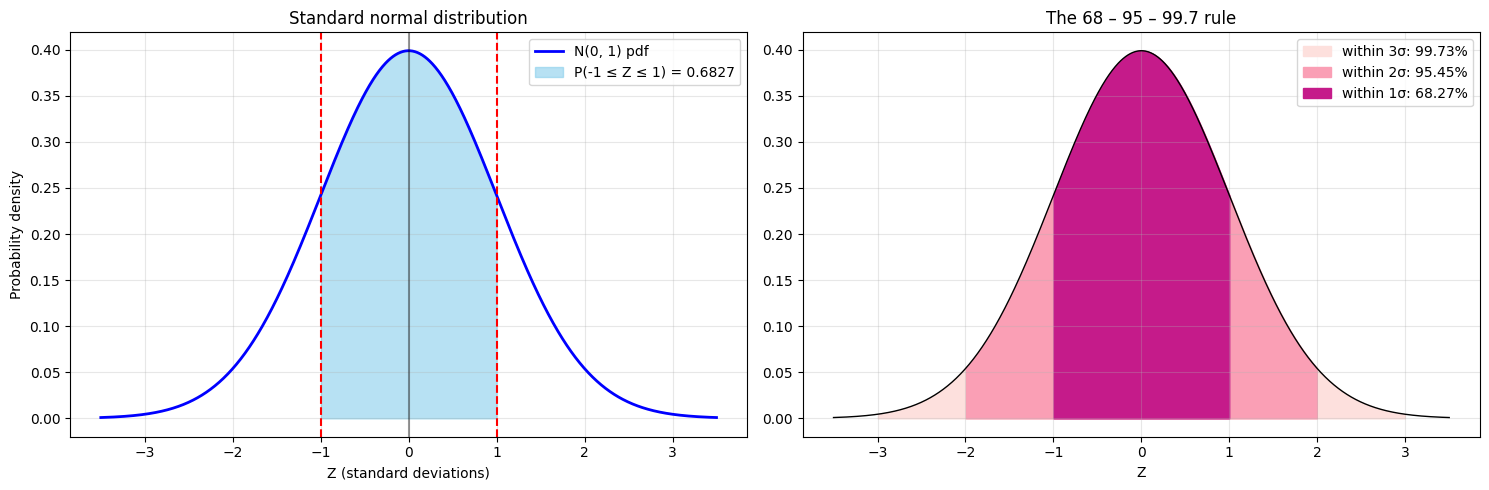

In [ ]:
x = np.linspace(-3.5, 3.5, 1000)
y = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(x, y, 'b-', lw=2, label='N(0, 1) pdf')
ax[0].fill_between(x, y, where=(x >= a) & (x <= b), color='skyblue', alpha=0.6, label=f'P({a} ≤ Z ≤ {b}) = {prob:.4f}')
ax[0].axvline(a, color='red', ls='--'); ax[0].axvline(b, color='red', ls='--'); ax[0].axvline(0, color='black', alpha=0.4)
ax[0].set_title('Standard normal distribution'); ax[0].set_xlabel('Z (standard deviations)'); ax[0].set_ylabel('Probability density'); ax[0].legend()

for k, c in zip((3, 2, 1), ('#fde0dd', '#fa9fb5', '#c51b8a')):
    ax[1].fill_between(x, y, where=(abs(x) <= k), color=c, label=f'within {k}σ: {norm.cdf(k) - norm.cdf(-k):.2%}')
ax[1].plot(x, y, 'k', lw=1); ax[1].set_title('The 68 – 95 – 99.7 rule'); ax[1].set_xlabel('Z'); ax[1].legend()
for a_ in ax: a_.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Part B – Application: weekly wages of 1000 workmen**

**Problem.** The weekly wages of 1000 workmen are normally distributed with mean ₹70 and standard deviation ₹5. Estimate the number of workers whose weekly wages are (i) between ₹70 and ₹72, (ii) more than ₹75, (iii) less than ₹65.

Weekly wages analysis (N = 1000, mean = ₹70, std. deviation = ₹5)
--------------------------------------------------------------
(i)   ₹70 to ₹72  :  P = 0.1554  (15.54 %)  ->   155 workers
(ii)  above ₹75   :  P = 0.1587  (15.87 %)  ->   159 workers
(iii) below ₹65   :  P = 0.1587  (15.87 %)  ->   159 workers

Both tails (ii) and (iii) are equal because the normal curve is symmetric about the mean:
about 31.7% of the workers earn unusually high or low wages.


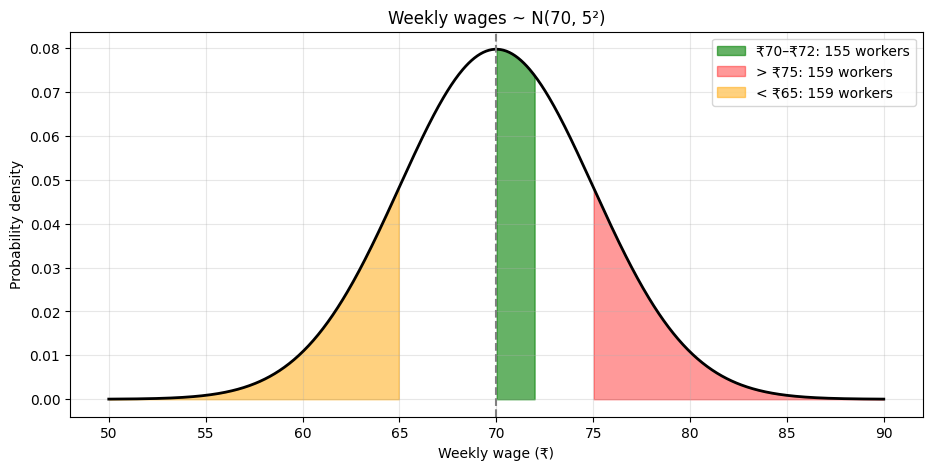

In [ ]:
mu, sigma, n_workers = 70, 5, 1000

p1 = norm.cdf(72, mu, sigma) - norm.cdf(70, mu, sigma)     # (i)   70 <= X <= 72
p2 = 1 - norm.cdf(75, mu, sigma)                           # (ii)  X > 75
p3 = norm.cdf(65, mu, sigma)                               # (iii) X < 65

print(f"Weekly wages analysis (N = {n_workers}, mean = ₹{mu}, std. deviation = ₹{sigma})")
print("-" * 62)
print(f"(i)   ₹70 to ₹72  :  P = {p1:.4f}  ({p1 * 100:5.2f} %)  ->  {round(p1 * n_workers):4d} workers")
print(f"(ii)  above ₹75   :  P = {p2:.4f}  ({p2 * 100:5.2f} %)  ->  {round(p2 * n_workers):4d} workers")
print(f"(iii) below ₹65   :  P = {p3:.4f}  ({p3 * 100:5.2f} %)  ->  {round(p3 * n_workers):4d} workers")
print("\nBoth tails (ii) and (iii) are equal because the normal curve is symmetric about the mean:")
print(f"about {(p2 + p3) * 100:.1f}% of the workers earn unusually high or low wages.")

x = np.linspace(50, 90, 800)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(11, 5))
plt.plot(x, y, 'k', lw=2)
plt.fill_between(x, y, where=(x >= 70) & (x <= 72), color='green', alpha=0.6, label=f'₹70–₹72: {round(p1 * n_workers)} workers')
plt.fill_between(x, y, where=(x > 75), color='red', alpha=0.4, label=f'> ₹75: {round(p2 * n_workers)} workers')
plt.fill_between(x, y, where=(x < 65), color='orange', alpha=0.5, label=f'< ₹65: {round(p3 * n_workers)} workers')
plt.axvline(mu, color='gray', ls='--')
plt.xlabel('Weekly wage (₹)'); plt.ylabel('Probability density'); plt.title('Weekly wages ~ N(70, 5²)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# **Part C – Application: engineer measuring bolt diameters**

**Problem.** A mechanical engineer tests the diameter of bolts that should be **10 mm**. Because of machine variability the diameters are normally distributed, and from past data the standard deviation is known to be **0.2 mm**. The engineer measures **500 bolts** and wants to check whether the diameters are centred around the target of 10 mm, and to visualise the distribution.

*(The measurements are simulated below with a slight shift of 0.01 mm; replace `diameters` by your actual data if available.)*

**Method.** With $\sigma=0.2$ known, the sample mean $\bar x$ has standard error $\sigma/\sqrt n$, and the test statistic for $H_0:\mu=10$ is $z=\dfrac{\bar x-10}{\sigma/\sqrt n}$. The 95% confidence interval for $\mu$ is $\bar x\pm1.96\,\sigma/\sqrt n$.

Bolt diameter analysis (n = 500)
------------------------------------------------------------
Sample mean                 : 10.0021 mm   (deviation from target: +0.0021 mm)
Sample standard deviation   : 0.2045 mm
Standard error (σ/√n)       : 0.0089 mm
z statistic                 : 0.231,   two-sided p-value = 0.8170
95% confidence interval     : (9.9845, 10.0196) mm
Conclusion: no significant difference from 10 mm -> the process is centred on the target
P(9.6 mm <= diameter <= 10.4 mm) = 0.9496  -> about 25 of 500 bolts outside the ±0.4 mm tolerance


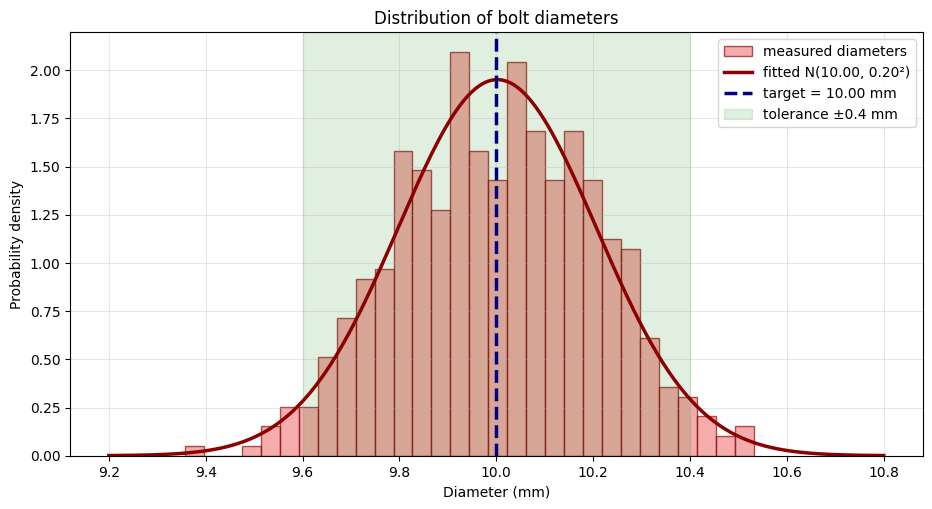

In [ ]:
rng = np.random.default_rng(101)
diameters = rng.normal(10.01, 0.2, 500)

target, sigma_known = 10.0, 0.2
n = len(diameters)
mean, std = diameters.mean(), diameters.std(ddof=1)

se = sigma_known / np.sqrt(n)
z = (mean - target) / se
p_value = 2 * (1 - norm.cdf(abs(z)))
ci = (mean - 1.96 * se, mean + 1.96 * se)

tol_low, tol_high = 9.6, 10.4
p_tol = norm.cdf(tol_high, mean, std) - norm.cdf(tol_low, mean, std)

print(f"Bolt diameter analysis (n = {n})")
print("-" * 60)
print(f"Sample mean                 : {mean:.4f} mm   (deviation from target: {mean - target:+.4f} mm)")
print(f"Sample standard deviation   : {std:.4f} mm")
print(f"Standard error (σ/√n)       : {se:.4f} mm")
print(f"z statistic                 : {z:.3f},   two-sided p-value = {p_value:.4f}")
print(f"95% confidence interval     : ({ci[0]:.4f}, {ci[1]:.4f}) mm")
print("Conclusion:", "the mean differs significantly from 10 mm" if p_value < 0.05
      else "no significant difference from 10 mm -> the process is centred on the target")
print(f"P(9.6 mm <= diameter <= 10.4 mm) = {p_tol:.4f}  -> about {round((1 - p_tol) * n)} of 500 bolts outside the ±0.4 mm tolerance")

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.hist(diameters, bins=30, density=True, alpha=0.65, color='lightcoral', edgecolor='maroon', label='measured diameters')
xg = np.linspace(9.2, 10.8, 400)
ax.plot(xg, norm.pdf(xg, mean, std), 'darkred', lw=2.5, label=f'fitted N({mean:.2f}, {std:.2f}²)')
ax.axvline(target, color='navy', ls='--', lw=2.5, label='target = 10.00 mm')
ax.axvspan(tol_low, tol_high, alpha=0.12, color='green', label='tolerance ±0.4 mm')
ax.set_xlabel('Diameter (mm)'); ax.set_ylabel('Probability density'); ax.set_title('Distribution of bolt diameters'); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

# **Result**

* $P(-1\le Z\le1)=0.6827$ (68.27%), in agreement with the empirical rule; the central 95% corresponds to $z=\pm1.96$.
* Weekly wages $N(70,5^2)$, 1000 workers: 155 workers earn ₹70–₹72, 159 earn more than ₹75 and 159 earn less than ₹65.
* Bolt diameters (500 simulated bolts): sample mean $10.002$ mm, standard deviation $0.2045$ mm; the $z$-test gave $z=0.23$, $p=0.82$ (no significant deviation from 10 mm) with 95% confidence interval $(9.985,\,10.020)$ mm, and about 95% of the bolts (all but roughly 25 of 500) lay within the $\pm0.4$ mm tolerance.

# **Discussion**

Probabilities for a continuous variable are areas under the density curve, computed from the CDF; $P(X=a)=0$ for any single value. Standardisation shows that every normal probability reduces to the standard normal table, which is what `norm.cdf` evaluates. The symmetric tails in the wage problem (both 15.9%) and the 68–95–99.7 rule are quick checks for numerical work. In the bolt problem the sampling distribution of the mean is narrow ($\sigma/\sqrt{500}\approx0.009$ mm), so even a very small shift could be detected — the idea behind the hypothesis tests of statistical quality control.

# **Practice Problems**

**Problem 1.** The lifetime of a bulb is normal with mean 1200 h and standard deviation 150 h. Find the probability that a bulb lasts (i) more than 1400 h, (ii) between 1000 and 1300 h, (iii) less than 900 h. In a lot of 2000 bulbs, how many are expected to last less than 900 h?

**Problem 2.** The marks in an examination are $N(60,\,12^2)$. Find the mark that is exceeded by only the top 10% of the students (use `norm.ppf`), and the minimum mark needed to be in the top 25%.

**Problem 3.** Simulate 5000 values from $N(50,\,8^2)$ and compare the fraction of values within $1\sigma$, $2\sigma$, $3\sigma$ of the mean with the empirical rule.

---

# **EXPERIMENT 7**

---

# **Uniform Distribution – Mean, Variance and PDF Visualization**

# **Aim:**

To obtain the mean and variance of a random variable following the uniform distribution over a given interval, to compute probabilities and to visualise its probability density function (PDF) and CDF.

# **Software required:**

Python 3, NumPy, SciPy (`scipy.stats.uniform`), Matplotlib

# **Theory:**

A continuous random variable $X$ is **uniformly distributed** over $[a,b]$ if every value in the interval is equally likely. Its PDF and CDF are

$$f(x)=\begin{cases}\dfrac{1}{b-a}, & a\le x\le b\\[2mm] 0,&\text{otherwise}\end{cases}\qquad F(x)=\frac{x-a}{b-a}\;\;(a\le x\le b).$$

**Mean:** $\mu=E[X]=\dfrac{a+b}{2}$  **Variance:** $\sigma^2=\dfrac{(b-a)^2}{12}$  **Standard deviation:** $\sigma=\dfrac{b-a}{\sqrt{12}}$

**Probability of a sub-interval:** $P(c\le X\le d)=\dfrac{d-c}{b-a}$ — the area of a rectangle.

In SciPy: `uniform(loc=a, scale=b-a)`.

# **Algorithm:**

1. Import NumPy, Matplotlib and `scipy.stats.uniform`.
2. Define the limits $a$ and $b$.
3. Compute the mean $(a+b)/2$ and the variance $(b-a)^2/12$.
4. Generate $x$ values slightly wider than $[a,b]$ and compute the PDF with `uniform.pdf(x, loc=a, scale=b-a)`.
5. Plot the PDF, shade the support and mark the mean.
6. Verify the results by simulation.

# **7.1 Case: uniform distribution over [2, 8]**

A random variable $X$ is uniformly distributed over $[2,8]$. Obtain the mean and variance and plot the PDF. The function `uniform_analysis` is reused in the applications.

=== Case study : Uniform[2, 8] ===
Mean (μ)            : 5.00 
Variance (σ²)       : 3.00 ²
Standard deviation  : 1.73 
PDF height 1/(b-a)  : 0.1667
P(3 <= X <= 5)   : 0.3333   (= 2/6;  uniform.cdf check: 0.3333)
Simulation (10 000 values): mean = 5.005, variance = 3.030


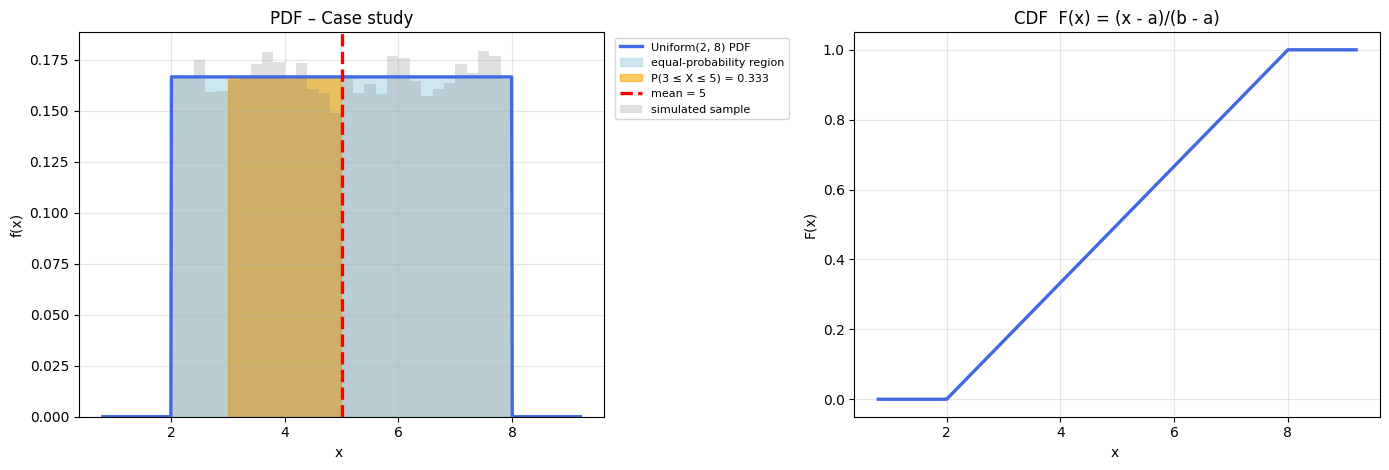

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

def uniform_analysis(a, b, unit='', title='', color='royalblue', fill='lightblue', c=None, d=None, seed=7):
    """Print mean, variance, sd; plot PDF and CDF; check by simulation. Optional probability P(c <= X <= d)."""
    mean, var = (a + b) / 2, (b - a) ** 2 / 12
    print(f"=== {title} : Uniform[{a}, {b}] ===")
    print(f"Mean (μ)            : {mean:.2f} {unit}")
    print(f"Variance (σ²)       : {var:.2f} {unit}²")
    print(f"Standard deviation  : {np.sqrt(var):.2f} {unit}")
    print(f"PDF height 1/(b-a)  : {1 / (b - a):.4f}")
    if c is not None:
        print(f"P({c} <= X <= {d})   : {(d - c) / (b - a):.4f}   (= {d - c}/{b - a};  uniform.cdf check: {uniform.cdf(d, a, b - a) - uniform.cdf(c, a, b - a):.4f})")

    sim = np.random.default_rng(seed).uniform(a, b, 10_000)
    print(f"Simulation (10 000 values): mean = {sim.mean():.3f}, variance = {sim.var(ddof=1):.3f}")

    x = np.linspace(a - 0.2 * (b - a), b + 0.2 * (b - a), 800)
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
    ax[0].plot(x, uniform.pdf(x, a, b - a), color=color, lw=2.4, label=f'Uniform({a}, {b}) PDF')
    ax[0].fill_between(x, uniform.pdf(x, a, b - a), where=(x >= a) & (x <= b), color=fill, alpha=0.6, label='equal-probability region')
    if c is not None:
        ax[0].fill_between(x, uniform.pdf(x, a, b - a), where=(x >= c) & (x <= d), color='orange', alpha=0.6, label=f'P({c} ≤ X ≤ {d}) = {(d - c) / (b - a):.3f}')
    ax[0].axvline(mean, color='red', ls='--', lw=2.4, label=f'mean = {mean:g}')
    ax[0].hist(sim, bins=30, density=True, alpha=0.25, color='gray', label='simulated sample')
    ax[0].set_title(f'PDF – {title}'); ax[0].set_xlabel(f'x {unit}'); ax[0].set_ylabel('f(x)'); ax[0].legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
    ax[1].plot(x, uniform.cdf(x, a, b - a), color=color, lw=2.4)
    ax[1].set_title('CDF  F(x) = (x - a)/(b - a)'); ax[1].set_xlabel(f'x {unit}'); ax[1].set_ylabel('F(x)')
    for a_ in ax: a_.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

uniform_analysis(2, 8, title='Case study', c=3, d=5)

# **Application Problem 1 – Temperature control in a furnace**

**Problem statement.** During normal operation the temperature of a small industrial furnace fluctuates uniformly between 200 °C and 250 °C, i.e. every temperature in that range is equally likely. The engineer wants to (1) model the temperature as $X\sim\text{Uniform}[200,250]$, (2) calculate the mean and variance, and (3) plot the PDF. In addition, we find the probability that the temperature exceeds 240 °C.

=== Furnace temperature : Uniform[200, 250] ===
Mean (μ)            : 225.00 °C
Variance (σ²)       : 208.33 °C²
Standard deviation  : 14.43 °C
PDF height 1/(b-a)  : 0.0200
P(240 <= X <= 250)   : 0.2000   (= 10/50;  uniform.cdf check: 0.2000)
Simulation (10 000 values): mean = 225.046, variance = 210.422


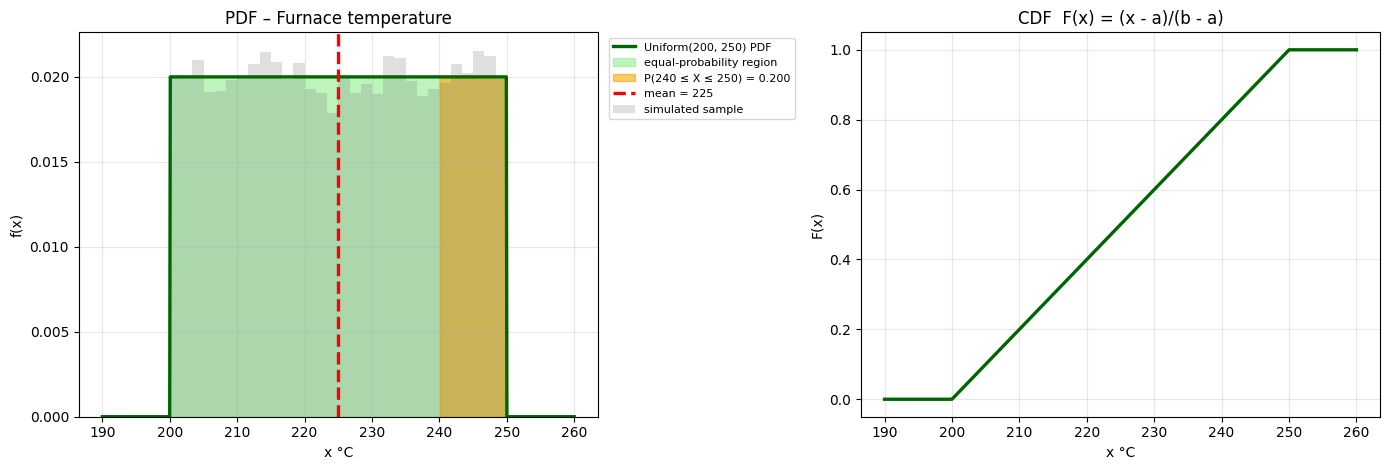

In [ ]:
uniform_analysis(200, 250, unit='°C', title='Furnace temperature', color='darkgreen', fill='lightgreen', c=240, d=250)

# **Application Problem 2 – Quality control in bolt manufacturing**

**Problem statement.** The diameter of every bolt made by an automated machine must lie between 3 mm and 9 mm and, by design, any diameter in this range is equally likely. The engineer wants to (1) model the diameter as $X\sim\text{Uniform}[3,9]$ mm, (2) calculate the mean and variance, and (3) visualise the PDF. In addition, find the probability that a bolt has a diameter between 5 mm and 7 mm.

=== Bolt diameter : Uniform[3, 9] ===
Mean (μ)            : 6.00 mm
Variance (σ²)       : 3.00 mm²
Standard deviation  : 1.73 mm
PDF height 1/(b-a)  : 0.1667
P(5 <= X <= 7)   : 0.3333   (= 2/6;  uniform.cdf check: 0.3333)
Simulation (10 000 values): mean = 6.005, variance = 3.030


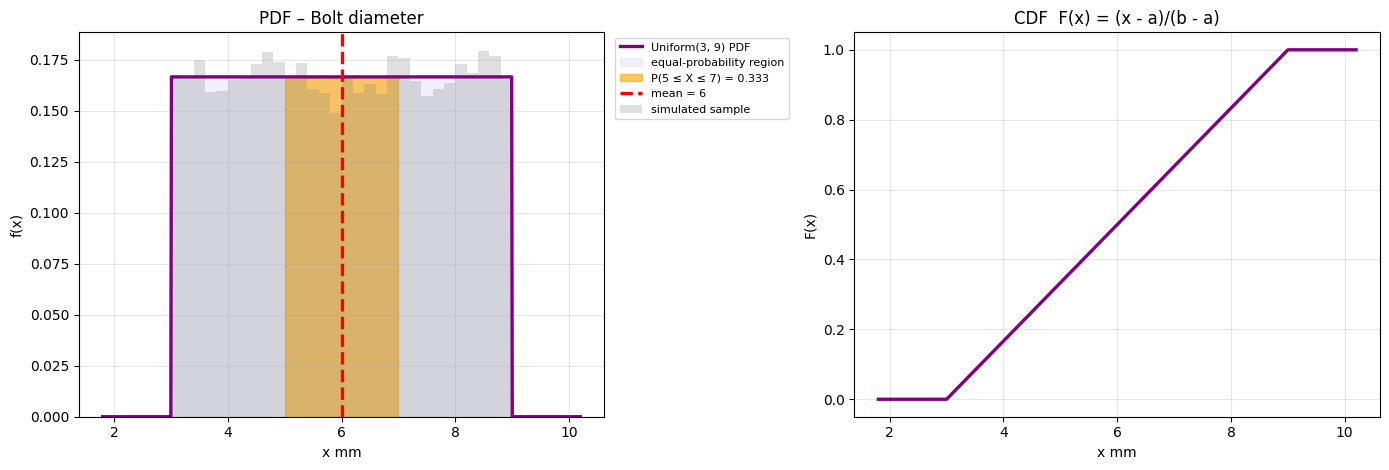

In [ ]:
uniform_analysis(3, 9, unit='mm', title='Bolt diameter', color='purple', fill='lavender', c=5, d=7)

# **Result**

* $X\sim U[2,8]$: mean $=5$, variance $=3$, standard deviation $=1.73$; $P(3\le X\le5)=1/3$.
* Furnace temperature $U[200,250]$ °C: mean $=225$ °C, variance $=208.33$ °C², standard deviation $=14.43$ °C; $P(X\ge240)=0.2$.
* Bolt diameter $U[3,9]$ mm: mean $=6$ mm, variance $=3$ mm², standard deviation $=1.73$ mm; $P(5\le X\le7)=1/3$.
* In all cases the simulated mean and variance agreed with the formulas.

# **Discussion**

The uniform PDF is a rectangle of height $1/(b-a)$, so all sub-intervals of equal length have equal probability, and the mean is the mid-point of the interval. The variance depends only on the *length* of the interval: doubling the length quadruples the variance. The uniform distribution is the model of complete ignorance within known limits (e.g. rounding errors, random phase of a signal) and it is the building block of random-number generators — in Experiment 9 a uniform random phase is used to build a random process.

# **Practice Problems**

**Problem 1.** A bus arrives every 20 minutes and a passenger arrives at a random time, so the waiting time is $U[0,20]$ minutes. Find the mean waiting time and the probability of waiting more than 15 minutes.

**Problem 2.** The error in rounding a measurement to the nearest unit is $U[-0.5,\,0.5]$. Find its mean, variance and standard deviation, and the probability that the error exceeds $0.4$ in magnitude.

**Problem 3.** If $X\sim U[0,1]$, simulate $Y=-\ln(X)/2$ for $10^5$ values and compare its histogram with the exponential PDF $2e^{-2y}$ (this is the inverse-transform method used in Experiment 8).

---

# **EXPERIMENT 8**

---

# **Analysis of Time Gaps Using the Exponential Distribution**

# **Aim:**

To calculate probabilities for the waiting (inter-arrival) time between random events using the Exponential distribution, and to visualise its probability density function (PDF) with the regions that correspond to the calculated probabilities shaded.

# **Software required:**

Python 3, NumPy, SciPy (`scipy.stats.expon`), Matplotlib, Pandas

# **Theory:**

The time $T$ between consecutive random events (calls, packets, shipments) that occur at an average rate $\lambda$ per unit time follows the **Exponential distribution**:

$$f(t)=\lambda e^{-\lambda t},\quad t\ge0,\qquad F(t)=P(T\le t)=1-e^{-\lambda t},\qquad P(T>t)=e^{-\lambda t}.$$

$$E[T]=\frac1\lambda=\text{mean time},\qquad \operatorname{Var}(T)=\frac{1}{\lambda^2}.$$

* In SciPy the **mean** is passed as `scale`: `expon.cdf(t, scale=mean_time)`, with $\lambda=1/\text{mean time}$.
* $P(t_1<T<t_2)=e^{-\lambda t_1}-e^{-\lambda t_2}$.
* **Memoryless property:** $P(T>s+t\mid T>s)=P(T>t)$ — the time already waited does not change the remaining waiting time.
* **Link with the Poisson distribution:** if the number of events in a fixed time is Poisson($\lambda t$), the gaps between events are Exponential($\lambda$) (used in Experiment 10).

# **Algorithm:**

1. Set the mean time and compute the rate $\lambda=1/\text{mean}$.
2. Use the CDF to compute $P(T<a)$ and $P(T>b)$.
3. Compute the PDF over a range of times.
4. Plot the PDF and shade the areas that correspond to the probabilities.
5. Interpret the results.

# **8.1 Case: requests with a mean gap of 10 minutes**

Find the probability that the time between two consecutive requests, exponentially distributed with a mean of 10 minutes, is (i) less than 5 minutes and (ii) greater than 15 minutes. Plot the PDF and shade the two areas. The helper function `analyse_exponential` is reused in the applications.

Time between two consecutive requests:  mean = 10 minutes,  rate λ = 0.1000 per minute
   P(T < 5 minutes)  = 0.3935   (formula 1 - exp(-5/10) = 0.3935)
   P(T > 15 minutes) = 0.2231   (formula exp(-15/10) = 0.2231)


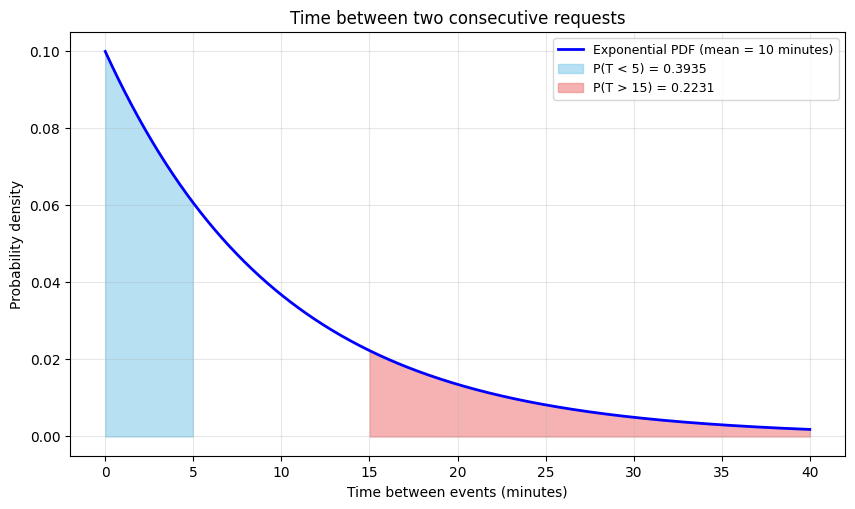

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import expon

def analyse_exponential(mean_time, low, high, unit, title, ax=None, x_max=None):
    """P(T < low) and P(T > high) for an exponential variable with the given mean; shaded PDF plot."""
    lam = 1 / mean_time
    p_low  = expon.cdf(low, scale=mean_time)                 # P(T < low)
    p_high = 1 - expon.cdf(high, scale=mean_time)            # P(T > high)
    unit1 = unit[:-1] if unit.endswith("s") else unit          # singular form for "per ..."
    print(f"{title}:  mean = {mean_time} {unit},  rate λ = {lam:.4f} per {unit1}")
    print(f"   P(T < {low} {unit})  = {p_low:.4f}   (formula 1 - exp(-{low}/{mean_time}) = {1 - np.exp(-low / mean_time):.4f})")
    print(f"   P(T > {high} {unit}) = {p_high:.4f}   (formula exp(-{high}/{mean_time}) = {np.exp(-high / mean_time):.4f})")

    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5.5))
    x = np.linspace(0, x_max or 4 * mean_time, 1000)
    pdf = expon.pdf(x, scale=mean_time)
    ax.plot(x, pdf, color='blue', lw=2, label=f'Exponential PDF (mean = {mean_time} {unit})')
    ax.fill_between(x, pdf, where=(x <= low), color='skyblue', alpha=0.6, label=f'P(T < {low}) = {p_low:.4f}')
    ax.fill_between(x, pdf, where=(x >= high), color='lightcoral', alpha=0.6, label=f'P(T > {high}) = {p_high:.4f}')
    ax.set_title(title); ax.set_xlabel(f'Time between events ({unit})'); ax.set_ylabel('Probability density')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    if show: plt.show()
    return p_low, p_high

_ = analyse_exponential(10, 5, 15, 'minutes', 'Time between two consecutive requests')

# **8.2 The memoryless property**

If a request has not arrived for 5 minutes, the probability that we must wait more than 10 *additional* minutes is the same as for a fresh start: $P(T>15\mid T>5)=P(T>10)=e^{-1}=0.3679$. This is checked analytically and by simulation of 200 000 gaps.

In [ ]:
mean_time = 10
exact_cond   = expon.sf(15, scale=mean_time) / expon.sf(5, scale=mean_time)       # P(T>15 | T>5)
exact_fresh  = expon.sf(10, scale=mean_time)                                       # P(T>10)

rng = np.random.default_rng(8)
T = rng.exponential(mean_time, 200_000)
sim_cond  = np.mean(T[T > 5] > 15)                    # among gaps that exceeded 5, fraction exceeding 15
sim_fresh = np.mean(T > 10)

print(f"Exact:      P(T > 15 | T > 5) = {exact_cond:.4f}      P(T > 10) = {exact_fresh:.4f}      e^-1 = {np.exp(-1):.4f}")
print(f"Simulation: P(T > 15 | T > 5) = {sim_cond:.4f}      P(T > 10) = {sim_fresh:.4f}")

Exact:      P(T > 15 | T > 5) = 0.3679      P(T > 10) = 0.3679      e^-1 = 0.3679
Simulation: P(T > 15 | T > 5) = 0.3696      P(T > 10) = 0.3681


# **8.3 Simulation versus theory, and the effect of the mean**

**Left:** 10 000 simulated gaps with mean 10 minutes against the exact PDF; the sample mean and standard deviation are both close to 10 (for the exponential distribution the standard deviation equals the mean). **Right:** shorter mean times give a steeper density — events are more frequent.

Sample mean = 10.014,  sample std. deviation = 9.862   (theory: both = 10)
Simulated P(T < 5) = 0.3919   exact = 0.3935


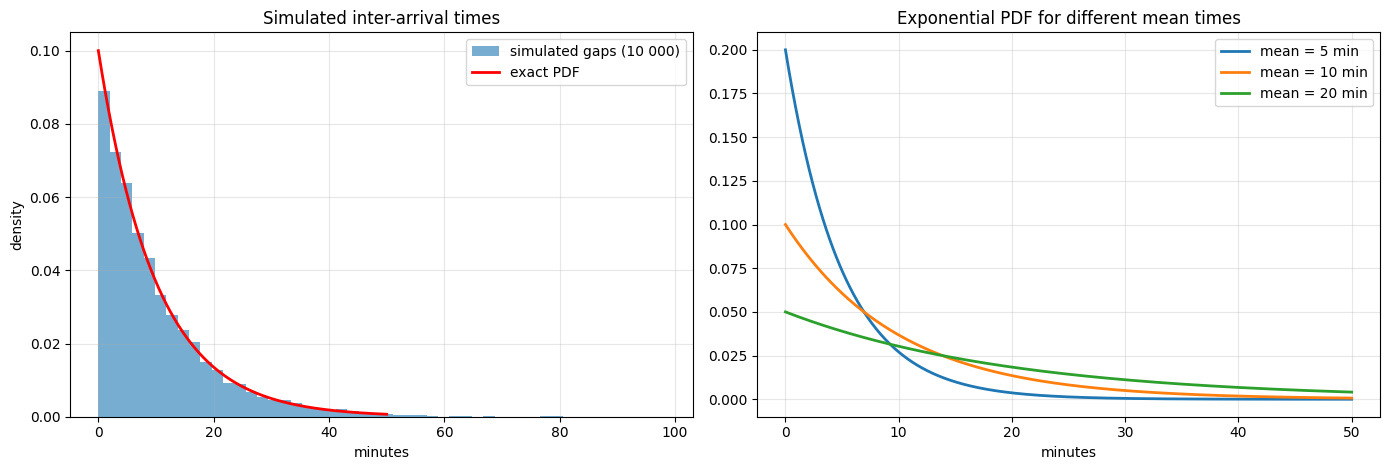

In [ ]:
print(f"Sample mean = {T[:10000].mean():.3f},  sample std. deviation = {T[:10000].std(ddof=1):.3f}   (theory: both = {mean_time})")
print(f"Simulated P(T < 5) = {np.mean(T < 5):.4f}   exact = {expon.cdf(5, scale=mean_time):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
xg = np.linspace(0, 50, 500)
ax[0].hist(T[:10000], bins=50, density=True, alpha=0.6, label='simulated gaps (10 000)')
ax[0].plot(xg, expon.pdf(xg, scale=mean_time), 'r-', lw=2, label='exact PDF')
ax[0].set_title('Simulated inter-arrival times'); ax[0].set_xlabel('minutes'); ax[0].set_ylabel('density'); ax[0].legend()

for m in (5, 10, 20):
    ax[1].plot(xg, expon.pdf(xg, scale=m), lw=2, label=f'mean = {m} min')
ax[1].set_title('Exponential PDF for different mean times'); ax[1].set_xlabel('minutes'); ax[1].legend()
for a in ax: a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Application Problem 1 – Call arrival time analysis**

**Problem statement.** A call centre receives calls at random times; the time between two consecutive calls is exponentially distributed with a mean of **8 minutes**. Calculate the probability that the time between two consecutive calls is (i) less than 4 minutes and (ii) greater than 12 minutes. Plot the PDF and shade the corresponding areas.

Call inter-arrival time (mean = 8 minutes):  mean = 8 minutes,  rate λ = 0.1250 per minute
   P(T < 4 minutes)  = 0.3935   (formula 1 - exp(-4/8) = 0.3935)
   P(T > 12 minutes) = 0.2231   (formula exp(-12/8) = 0.2231)


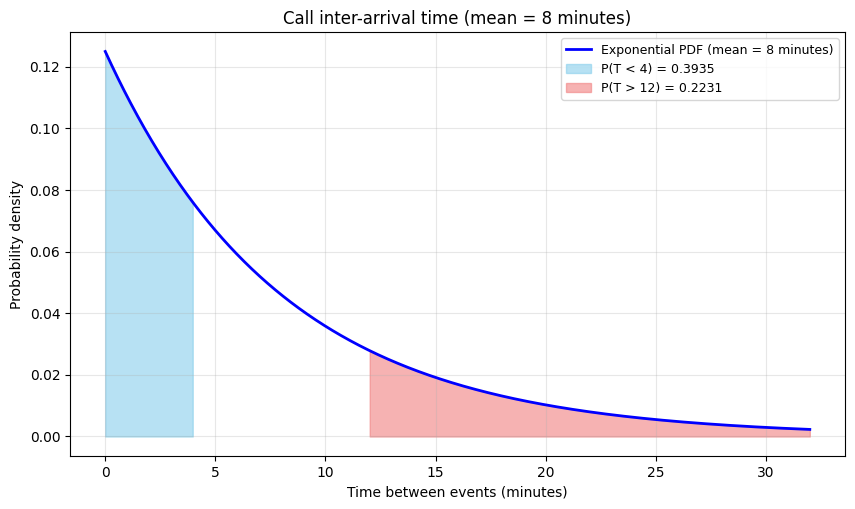

In [ ]:
_ = analyse_exponential(8, 4, 12, 'minutes', 'Call inter-arrival time (mean = 8 minutes)')

# **Application Problem 2 – Packet arrival modelling in network routers**

**Problem statement.** Packets arrive at a router at random; the time between successive packet arrivals is exponentially distributed with an average of **8 milliseconds**. Calculate the probability that the time between two packets is (i) less than 4 ms and (ii) greater than 12 ms. Plot the PDF and shade the regions.

Packet inter-arrival time (mean = 8 ms):  mean = 8 milliseconds,  rate λ = 0.1250 per millisecond
   P(T < 4 milliseconds)  = 0.3935   (formula 1 - exp(-4/8) = 0.3935)
   P(T > 12 milliseconds) = 0.2231   (formula exp(-12/8) = 0.2231)


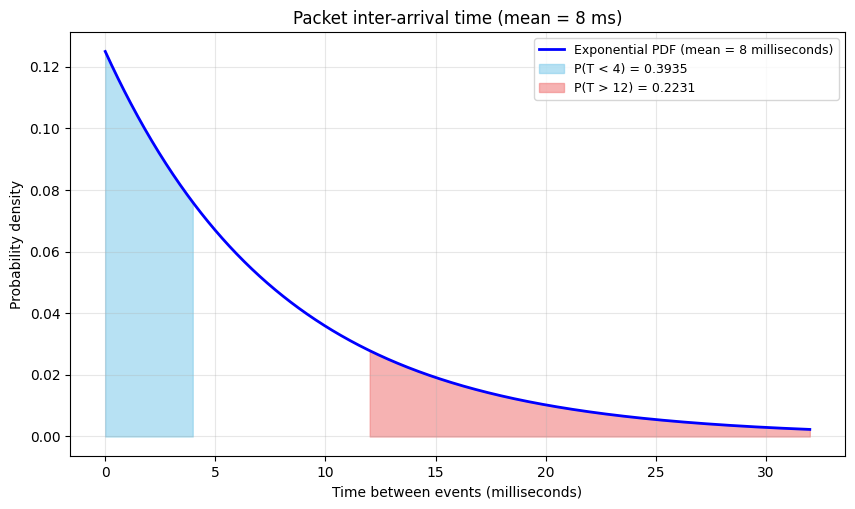

In [ ]:
_ = analyse_exponential(8, 4, 12, 'milliseconds', 'Packet inter-arrival time (mean = 8 ms)')

# **Application Problem 3 – Shipment arrivals at a warehouse**

**Problem statement.** A warehouse receives shipments at random times; the time between two consecutive shipments is exponentially distributed with a mean of **20 minutes**. Calculate the probability that the time between two consecutive shipments is (i) less than 10 minutes and (ii) greater than 30 minutes, and plot the PDF with the corresponding areas shaded.

Shipment inter-arrival time (mean = 20 minutes):  mean = 20 minutes,  rate λ = 0.0500 per minute
   P(T < 10 minutes)  = 0.3935   (formula 1 - exp(-10/20) = 0.3935)
   P(T > 30 minutes) = 0.2231   (formula exp(-30/20) = 0.2231)


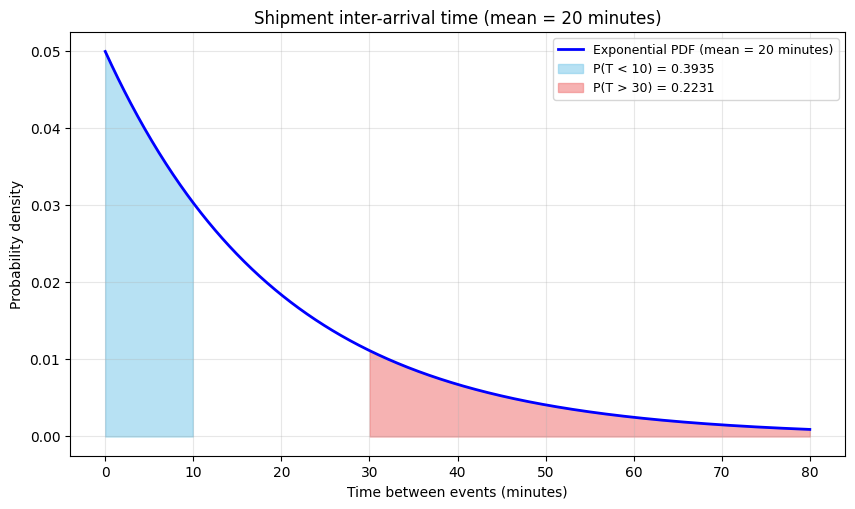

In [ ]:
_ = analyse_exponential(20, 10, 30, 'minutes', 'Shipment inter-arrival time (mean = 20 minutes)', x_max=80)

**Comparison.** The three problems give *identical* probabilities, because $P(T<t)=1-e^{-t/\text{mean}}$ depends only on the **ratio** $t/\text{mean}$ — here $0.5$ and $1.5$ in every case.

In [ ]:
rows = [("Requests (Case)", 10, 5, 15), ("Calls (Application 1)", 8, 4, 12), ("Packets (Application 2)", 8, 4, 12), ("Shipments (Application 3)", 20, 10, 30)]
summary = pd.DataFrame([{"Problem": n, "mean": m, "t1": a, "t2": b, "t1/mean": a / m, "t2/mean": b / m,
                         "P(T < t1)": expon.cdf(a, scale=m), "P(T > t2)": expon.sf(b, scale=m)} for n, m, a, b in rows]).set_index("Problem")
display(summary.round(4))

,mean,t1,t2,t1/mean,t2/mean,P(T < t1),P(T > t2)
Problem,,,,,,,
Requests (Case),10,5,15,0.5,1.5,0.3935,0.2231
Calls (Application 1),8,4,12,0.5,1.5,0.3935,0.2231
Packets (Application 2),8,4,12,0.5,1.5,0.3935,0.2231
Shipments (Application 3),20,10,30,0.5,1.5,0.3935,0.2231


# **Result**

* Requests, mean 10 min: $P(T<5)=0.3935$ (39.35%) and $P(T>15)=0.2231$ (22.31%).
* Calls (mean 8 min, thresholds 4 and 12 min), packets (mean 8 ms, thresholds 4 and 12 ms) and shipments (mean 20 min, thresholds 10 and 30 min) all gave $P(T<t_1)=0.3935$ and $P(T>t_2)=0.2231$.
* The memoryless property was verified: $P(T>15\mid T>5)=P(T>10)=0.3679$ (exact and simulated).

# **Discussion**

Short gaps are the most likely, and the probability of a long gap decreases exponentially — the PDF is highest at $t=0$ and falls off steadily; the shaded areas show the probabilities. The three applications give the same numbers because the probabilities depend only on the ratio of the time to the mean time (a *scale-free* property), although their units and time scales are entirely different. The memoryless property means that how long we have already waited carries no information about how much longer we must wait; this is why the exponential distribution is the natural model for the gaps of a Poisson process (Experiment 10).

# **Practice Problems**

**Problem 1.** The lifetime of an electronic component is exponential with a mean of 500 hours. Find the probability that it (i) fails within 100 hours, (ii) lasts more than 800 hours, (iii) fails between 200 and 600 hours.

**Problem 2.** Buses arrive at a stop as a Poisson process with a mean gap of 12 minutes. A passenger has already waited 10 minutes. What is the probability that the bus arrives within the next 5 minutes? Explain why the answer does not depend on the 10 minutes already waited.

**Problem 3.** Find the time $t$ such that 90% of the gaps are shorter than $t$ for a mean gap of 8 minutes (use `expon.ppf(0.9, scale=8)`). Check your result by simulation.

---

# **EXPERIMENT 9**

---

# **Generation and Verification of a Wide-Sense Stationary (WSS) Process**

# **Aim:**

To generate a sine wave with a random phase and to verify that it is a **Wide-Sense Stationary (WSS)** process by analysing its ensemble mean and autocorrelation function.

# **Software required:**

Python 3, NumPy, Matplotlib, Pandas

# **Theory:**

A **random process** $X(t)$ is a family of random variables indexed by time; every outcome of the experiment gives one *realization* (sample path). The **ensemble mean** $E[X(t)]$ and the **autocorrelation** $R_X(t_1,t_2)=E[X(t_1)X(t_2)]$ are averages over *all realizations* at fixed times.

$X(t)$ is **Wide-Sense Stationary (WSS)** if

* **Condition 1 – constant mean:** $E[X(t)]=\mu$ for all $t$;
* **Condition 2 – autocorrelation depends only on the lag:** $R_X(t,\,t+\tau)=R_X(\tau)$, a function of $\tau=t_2-t_1$ alone, not of $t$.

**Random-phase sinusoid.** Let $X(t)=a\sin(\omega_0t+\Theta)$ with $\Theta\sim U[0,2\pi]$ (amplitude $a$ and frequency $\omega_0$ fixed).

$$E[X(t)]=\frac{a}{2\pi}\int_0^{2\pi}\sin(\omega_0t+\theta)\,d\theta=0$$

$$R_X(t,t+\tau)=E\big[a^2\sin(\omega_0t+\Theta)\sin(\omega_0(t+\tau)+\Theta)\big]=\frac{a^2}{2}\cos(\omega_0\tau)-\frac{a^2}{2}E\big[\cos(\omega_0(2t+\tau)+2\Theta)\big]=\frac{a^2}{2}\cos(\omega_0\tau)$$

since the last expectation is zero. The mean is constant and $R_X$ depends only on $\tau$, so the process is WSS. The average power is $R_X(0)=a^2/2$. The same holds for $a\cos(\omega_0t+\Theta)$ and for any other frequency, e.g. $\omega_0+\Delta\omega$ (Doppler shift), with $\omega_0$ replaced by the new frequency.

# **Procedure / Algorithm:**

1. Define the amplitude $a$, the frequency, the time vector $t\in[0,2]$ s (500 points) and the lag vector $\tau\in[-1,1]$ s (501 points).
2. Generate $N=10\,000$ random phases $\Theta\sim U[0,2\pi]$ and form the $500\times N$ matrix of realizations by broadcasting.
3. Ensemble mean: average **across realizations** (axis = 1) at each time instant.
4. Autocorrelation: for several starting times $t_0$ and for each lag $\tau$, average $X(t_0)X(t_0+\tau)$ over the realizations.
5. Compare with the theoretical $\frac{a^2}{2}\cos(\omega_0\tau)$ and check that the curves for different $t_0$ coincide.
6. Plot sample paths, ensemble mean and autocorrelation.

**Expected observations.** The ensemble mean fluctuates very close to zero (within about $\pm0.03$ for $N=10\,000$); the empirical autocorrelation matches $\frac{a^2}{2}\cos(\omega_0\tau)$ for *every* starting time $t_0$.

# **9.1 A function to simulate and test a process**

`simulate_wss` generates the realizations of $X(t)$ for a given waveform function, computes the ensemble mean and the autocorrelation for four different starting times $t_0$, and plots the results. Checking several $t_0$ is essential: Condition 2 requires the autocorrelation to be the same whatever $t_0$ is.

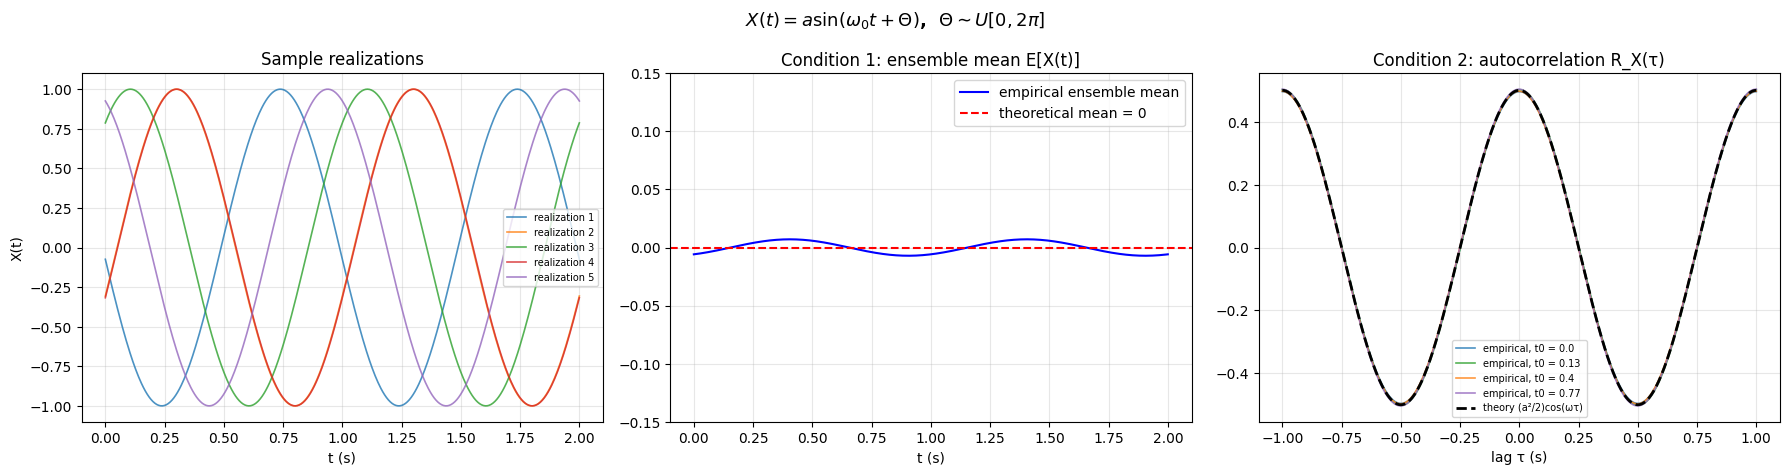

Maximum |ensemble mean|                       : 0.0071  (theory 0)
Maximum |empirical R_X - theoretical R_X|     : 0.0045
Maximum difference between the curves for different t0: 0.009  (theory 0)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

a      = 1.0
omega0 = 2 * np.pi                       # 1 Hz
N      = 10_000                          # number of realizations
t      = np.linspace(0, 2, 500)          # time axis (s)
taus   = np.linspace(-1, 1, 501)         # lag axis (s)
t0_list = [0.0, 0.13, 0.40, 0.77]        # starting times used to test Condition 2

def simulate_wss(waveform, omega, title, seed, show=True):
    """waveform(t, theta) -> X(t).  omega = angular frequency used in the theoretical R_X."""
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, N)                    # random phase, one per realization
    X = waveform(t[:, None], theta)                         # (500, N): column = one realization

    mean_X = X.mean(axis=1)                                 # ensemble mean at every time (average over realizations)
    R_theory = 0.5 * a ** 2 * np.cos(omega * taus)
    R_emp = {t0: np.mean(waveform(t0, theta) * waveform(t0 + taus[:, None], theta), axis=1) for t0 in t0_list}
    max_dev = max(np.max(np.abs(R - R_theory)) for R in R_emp.values())
    spread = np.max([R_emp[t0] for t0 in t0_list], axis=0) - np.min([R_emp[t0] for t0 in t0_list], axis=0)

    if show:
        fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
        for k in range(5):
            ax[0].plot(t, X[:, k], lw=1.2, alpha=0.8, label=f'realization {k + 1}')
        ax[0].set_title('Sample realizations'); ax[0].set_xlabel('t (s)'); ax[0].set_ylabel('X(t)'); ax[0].legend(fontsize=7)

        ax[1].plot(t, mean_X, 'b-', lw=1.5, label='empirical ensemble mean')
        ax[1].axhline(0, color='r', ls='--', label='theoretical mean = 0')
        ax[1].set_ylim(-0.15, 0.15); ax[1].set_title('Condition 1: ensemble mean E[X(t)]'); ax[1].set_xlabel('t (s)'); ax[1].legend()

        for t0, col in zip(t0_list, ('tab:blue', 'tab:green', 'tab:orange', 'tab:purple')):
            ax[2].plot(taus, R_emp[t0], color=col, lw=1.2, alpha=0.8, label=f'empirical, t0 = {t0}')
        ax[2].plot(taus, R_theory, 'k--', lw=2, label='theory (a²/2)cos(ωτ)')
        ax[2].set_title('Condition 2: autocorrelation R_X(τ)'); ax[2].set_xlabel('lag τ (s)'); ax[2].legend(fontsize=7)
        for a_ in ax: a_.grid(True, alpha=0.3)
        fig.suptitle(title, fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
    return {"max |mean|": np.max(np.abs(mean_X)), "max |R_emp - R_theory|": max_dev, "max spread over t0": spread.max()}

res_sin = simulate_wss(lambda tt, th: a * np.sin(omega0 * tt + th), omega0, r'$X(t)=a\sin(\omega_0 t+\Theta)$,  $\Theta\sim U[0,2\pi]$', seed=1)
print("Maximum |ensemble mean|                       :", round(res_sin["max |mean|"], 4), " (theory 0)")
print("Maximum |empirical R_X - theoretical R_X|     :", round(res_sin["max |R_emp - R_theory|"], 4))
print("Maximum difference between the curves for different t0:", round(res_sin["max spread over t0"], 4), " (theory 0)")

# **Application Problem 1 – Random phase in wireless communication**

**Problem statement.** In wireless systems, signals suffer random distortions from multipath fading, oscillator phase noise and other channel effects. A common one is a *random phase shift*, modelled by a uniformly distributed random variable. The received signal is

$$X(t)=a\cos(\omega_0t+\Theta),\qquad \omega_0=2\pi f_0,\;f_0=1\text{ Hz},\;\Theta\sim U[0,2\pi],$$

where the phase offset is constant over time but unknown and random (reflections, lack of synchronisation). Determine whether $X(t)$ is Wide-Sense Stationary and plot it.

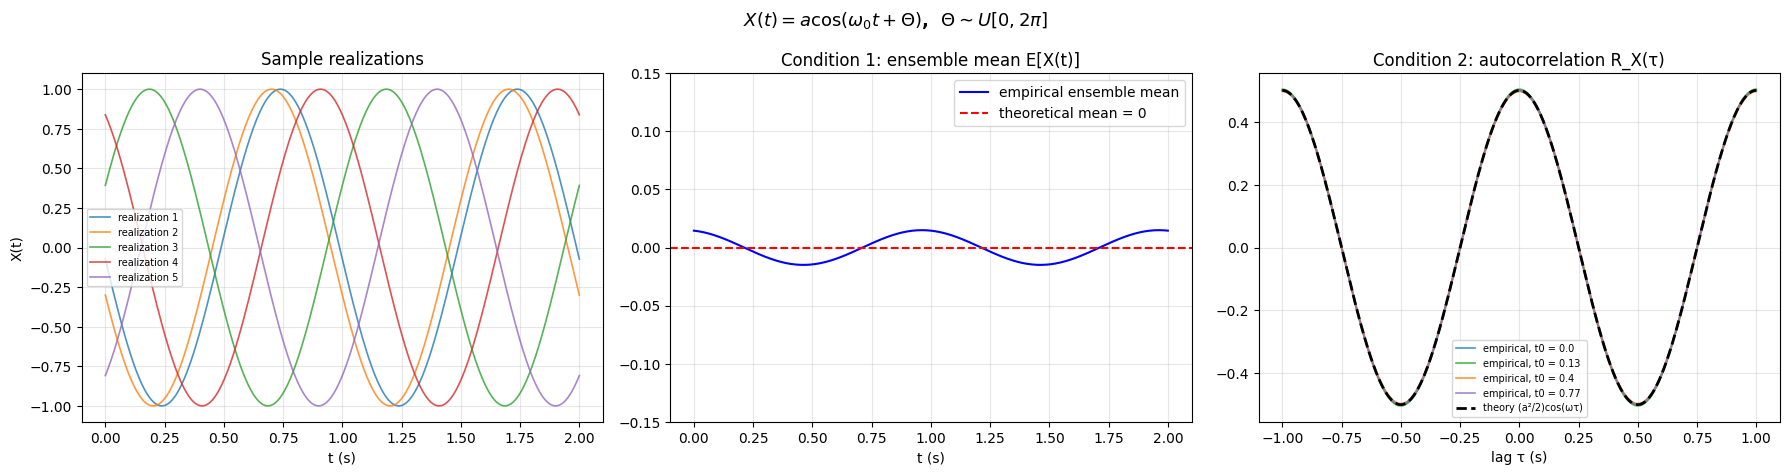

WSS check for X(t) = a cos(ω0 t + Θ)
-------------------------------------------------------
Max |ensemble mean|                : 0.0150   (≈ 0 -> Condition 1 satisfied)
Max |R_empirical - R_theory|       : 0.0040   (≈ 0)
Max difference between t0 curves   : 0.0080   (≈ 0 -> Condition 2 satisfied)

Theory: E[X(t)] = 0 and R_X(τ) = (a²/2)cos(ω0 τ)  ->  the process IS wide-sense stationary.


In [ ]:
res_cos = simulate_wss(lambda tt, th: a * np.cos(omega0 * tt + th), omega0, r'$X(t)=a\cos(\omega_0 t+\Theta)$,  $\Theta\sim U[0,2\pi]$', seed=2)
print("WSS check for X(t) = a cos(ω0 t + Θ)")
print("-" * 55)
print(f"Max |ensemble mean|                : {res_cos['max |mean|']:.4f}   (≈ 0 -> Condition 1 satisfied)")
print(f"Max |R_empirical - R_theory|       : {res_cos['max |R_emp - R_theory|']:.4f}   (≈ 0)")
print(f"Max difference between t0 curves   : {res_cos['max spread over t0']:.4f}   (≈ 0 -> Condition 2 satisfied)")
print("\nTheory: E[X(t)] = 0 and R_X(τ) = (a²/2)cos(ω0 τ)  ->  the process IS wide-sense stationary.")

# **Application Problem 2 – Doppler-shifted signal**

**Problem statement.** In wireless and satellite communication, relative motion between transmitter and receiver causes a Doppler shift. Examine the wide-sense stationarity of

$$X(t)=a\cos\big((\omega_0+\Delta\omega)t+\Theta\big),\qquad \Theta\sim U[0,2\pi],\;\Delta f=0.3\text{ Hz},\;\Delta\omega=2\pi\Delta f,$$

and plot it. Also show the effect of the Doppler shift on the autocorrelation.

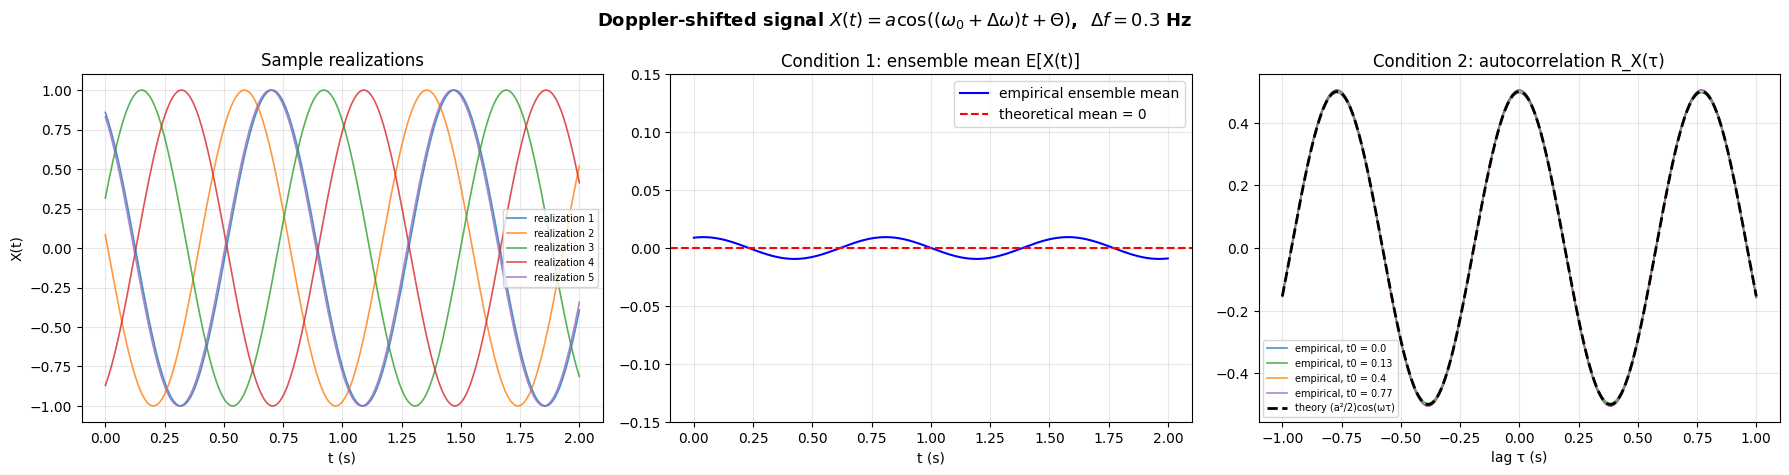

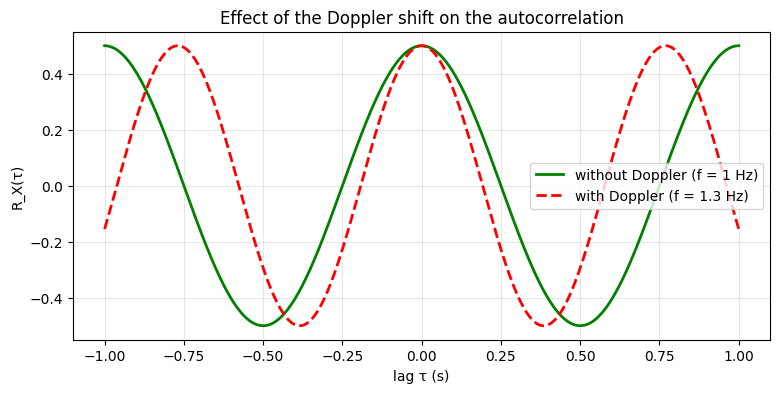

WSS check for the Doppler-shifted signal
-------------------------------------------------------
Effective frequency f0 + Δf       : 1.3 Hz
Max |ensemble mean|               : 0.0094   (≈ 0)
Max |R_empirical - R_theory|      : 0.0047   (≈ 0)
Max difference between t0 curves  : 0.0083   (≈ 0)

The Doppler shift changes the FREQUENCY of the autocorrelation cosine, but R_X still depends only on τ,
so the process remains wide-sense stationary.


In [ ]:
delta_f = 0.3
omega_total = omega0 + 2 * np.pi * delta_f

res_dop = simulate_wss(lambda tt, th: a * np.cos(omega_total * tt + th), omega_total,
                       r'Doppler-shifted signal $X(t)=a\cos((\omega_0+\Delta\omega)t+\Theta)$,  $\Delta f=0.3$ Hz', seed=3)

plt.figure(figsize=(9, 4))
plt.plot(taus, 0.5 * a ** 2 * np.cos(omega0 * taus), 'g-', lw=2, label='without Doppler (f = 1 Hz)')
plt.plot(taus, 0.5 * a ** 2 * np.cos(omega_total * taus), 'r--', lw=2, label='with Doppler (f = 1.3 Hz)')
plt.xlabel('lag τ (s)'); plt.ylabel('R_X(τ)'); plt.title('Effect of the Doppler shift on the autocorrelation'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print("WSS check for the Doppler-shifted signal")
print("-" * 55)
print(f"Effective frequency f0 + Δf       : {1 + delta_f} Hz")
print(f"Max |ensemble mean|               : {res_dop['max |mean|']:.4f}   (≈ 0)")
print(f"Max |R_empirical - R_theory|      : {res_dop['max |R_emp - R_theory|']:.4f}   (≈ 0)")
print(f"Max difference between t0 curves  : {res_dop['max spread over t0']:.4f}   (≈ 0)")
print("\nThe Doppler shift changes the FREQUENCY of the autocorrelation cosine, but R_X still depends only on τ,")
print("so the process remains wide-sense stationary.")

# **9.2 A process that is *not* WSS**

Let $X(t)=A\sin(\omega_0t)$ where the **amplitude** $A\sim N(0,1)$ is random but the phase is fixed. Then $E[X(t)]=E[A]\sin(\omega_0t)=0$ (Condition 1 holds), but

$$R_X(t,t+\tau)=E[A^2]\sin(\omega_0t)\sin(\omega_0(t+\tau))=\sin(\omega_0t)\sin(\omega_0(t+\tau))$$

depends on $t$, not only on $\tau$ — Condition 2 fails. The heat maps show $R_X(t_1,t_2)$ estimated from the realizations: for a WSS process the pattern depends only on $t_2-t_1$ (constant along each diagonal, **left**); for the non-WSS process it does not (**right**).

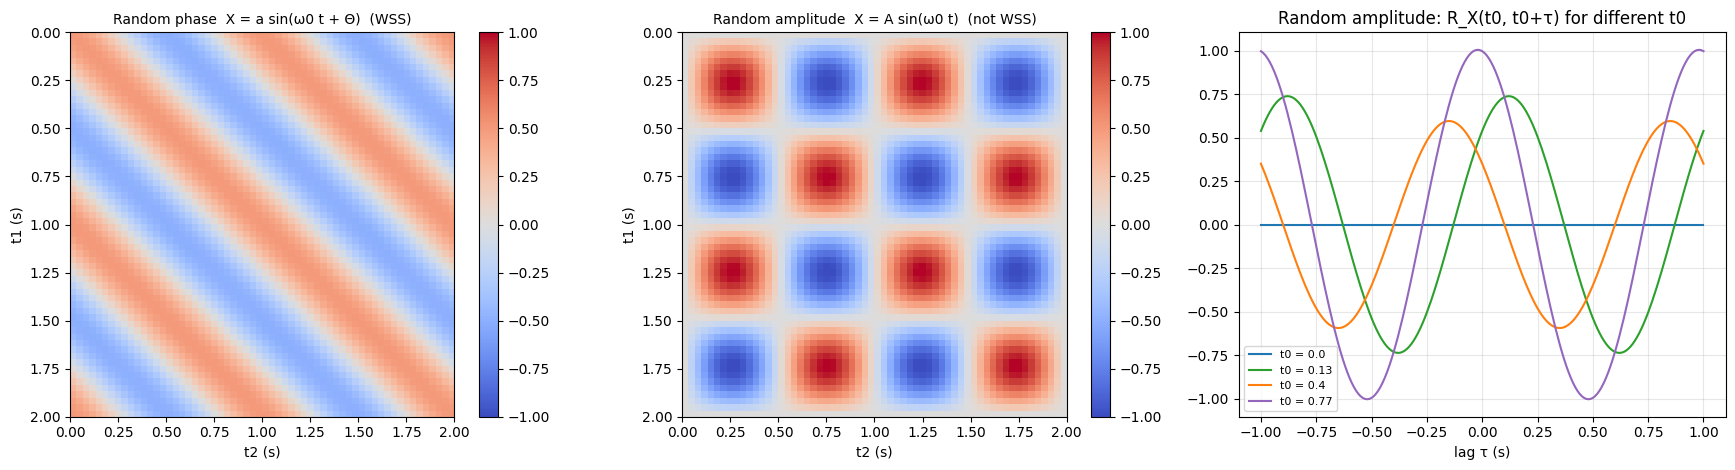

Random amplitude process: E[X(t)^2] = sin^2(ω0 t) -> at t = 0.25 s : 1.006   at t = 0.5 s : 0.003
The mean power changes with time, so the process is NOT wide-sense stationary.


In [ ]:
rng = np.random.default_rng(9)
theta = rng.uniform(0, 2 * np.pi, N)
A_amp = rng.standard_normal(N)

tg = np.linspace(0, 2, 60)
X_wss = np.sin(omega0 * tg[:, None] + theta[None, :])                  # random phase  -> WSS
X_amp = A_amp[None, :] * np.sin(omega0 * tg[:, None])                   # random amplitude -> not WSS
R_wss = X_wss @ X_wss.T / N                                             # estimate of R_X(t1, t2)
R_amp = X_amp @ X_amp.T / N

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
for axis, R, title in zip(ax[:2], (R_wss, R_amp), ('Random phase  X = a sin(ω0 t + Θ)  (WSS)', 'Random amplitude  X = A sin(ω0 t)  (not WSS)')):
    im = axis.imshow(R, extent=[0, 2, 2, 0], cmap='coolwarm', vmin=-1, vmax=1)
    axis.set_title(title, fontsize=10); axis.set_xlabel('t2 (s)'); axis.set_ylabel('t1 (s)'); plt.colorbar(im, ax=axis, fraction=0.046)

taus_ = np.linspace(-1, 1, 201)
for t0, col in zip(t0_list, ('tab:blue', 'tab:green', 'tab:orange', 'tab:purple')):
    R_t0 = np.mean(A_amp[None, :] ** 2 * (np.sin(omega0 * t0) * np.sin(omega0 * (t0 + taus_))[:, None]), axis=1)
    ax[2].plot(taus_, R_t0, color=col, label=f't0 = {t0}')
ax[2].set_title('Random amplitude: R_X(t0, t0+τ) for different t0'); ax[2].set_xlabel('lag τ (s)'); ax[2].legend(fontsize=8); ax[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Random amplitude process: E[X(t)^2] = sin^2(ω0 t) -> at t = 0.25 s :", round(np.mean(X_amp[np.argmin(abs(tg - 0.25))] ** 2), 3),
      "  at t = 0.5 s :", round(np.mean(X_amp[np.argmin(abs(tg - 0.5))] ** 2), 3))
print("The mean power changes with time, so the process is NOT wide-sense stationary.")

In [ ]:
summary = pd.DataFrame({
    "Process": ["a sin(ω0 t + Θ)", "a cos(ω0 t + Θ)", "a cos((ω0+Δω) t + Θ)"],
    "max |mean|": [res_sin["max |mean|"], res_cos["max |mean|"], res_dop["max |mean|"]],
    "max |R_emp - R_theory|": [res_sin["max |R_emp - R_theory|"], res_cos["max |R_emp - R_theory|"], res_dop["max |R_emp - R_theory|"]],
    "max spread over t0": [res_sin["max spread over t0"], res_cos["max spread over t0"], res_dop["max spread over t0"]],
    "WSS?": ["Yes", "Yes", "Yes"],
}).set_index("Process").round(4)
display(summary)

,max |mean|,max |R_emp - R_theory|,max spread over t0,WSS?
Process,,,,
a sin(ω0 t + Θ),0.0071,0.0045,0.0090,Yes
a cos(ω0 t + Θ),0.0150,0.0040,0.0080,Yes
a cos((ω0+Δω) t + Θ),0.0094,0.0047,0.0083,Yes


# **Result**

The processes $X(t)=a\sin(\omega_0t+\Theta)$, $a\cos(\omega_0t+\Theta)$ and the Doppler-shifted $a\cos((\omega_0+\Delta\omega)t+\Theta)$ with $\Theta\sim U[0,2\pi]$ were simulated with 10 000 realizations each and verified to be **wide-sense stationary**:

* the ensemble mean $E[X(t)]\approx0$ for all $t$ (WSS Condition 1);
* the empirical autocorrelation agreed with $R_X(\tau)=\frac{a^2}{2}\cos(\omega\tau)$ and was the same for every starting time $t_0$ (WSS Condition 2).

The process $A\sin(\omega_0t)$ with random amplitude had a zero mean but an autocorrelation that depended on $t$, so it is **not** WSS.

# **Discussion**

Averages for a random process are taken *across realizations* (the ensemble), at fixed times — averaging each realization over time (axis = 0) would give a different quantity. For a WSS process the autocorrelation depends only on the lag, so $R_X(\tau)$ is an even function with its maximum $a^2/2$ (the average power) at $\tau=0$; the random phase "forgets" the time origin, which is what makes the process stationary. The Doppler shift only changes the frequency of $R_X(\tau)$, while a random amplitude with a fixed phase breaks stationarity because the signal power then varies with time. WSS is the property required to define the power spectral density (Wiener–Khinchin theorem) used in communication-system analysis.

# **Practice Problems**

**Problem 1.** Show analytically that $X(t)=a\cos(\omega_0t+\Theta)$ with $\Theta\sim U[0,2\pi]$ has $R_X(\tau)=\frac{a^2}{2}\cos(\omega_0\tau)$, and verify the value $R_X(0)=a^2/2$ by simulating with $a=3$.

**Problem 2.** Repeat the simulation with $\Theta\sim U[0,\pi]$. Compute the ensemble mean and show that it depends on $t$ (the process is not WSS).

**Problem 3.** Consider $Y(t)=X(t)+W(t)$, where $X$ is the random-phase sinusoid and $W(t)$ is independent white noise of variance $\sigma^2=0.25$ at each time instant. Estimate the autocorrelation of $Y$ for lags $\tau=0$ and $\tau\ne0$ and explain what changes.

**Problem 4.** For the Doppler-shifted signal with $\Delta f=0.3$ Hz compute the time average $\frac{1}{T}\int_0^T X(t)\,dt$ of a *single* realization for $T=100$ s and compare it with the ensemble mean (ergodicity).

---

# **EXPERIMENT 10**

---

# **Modelling and Visualization of Events Using Exponential Inter-Arrival Times (Poisson Process)**

# **Aim:**

To simulate a Poisson arrival process by generating inter-arrival times from the Exponential distribution, and to visualise the event times and the distribution of inter-arrival times in order to understand the stochastic behaviour of such processes.

# **Software required:**

Python 3, NumPy, SciPy, Matplotlib, Pandas

# **Theory:**

A **Poisson process** models events that occur randomly in time. It is characterised by:

1. **Arrival rate $\lambda$:** the average number of events per unit time.
2. **Inter-arrival times** $T_1,T_2,\dots$ are independent and Exponential with mean $1/\lambda$:

$$f_T(t)=\lambda e^{-\lambda t},\quad t\ge0,\qquad E[T]=\frac1\lambda,\qquad \operatorname{Var}(T)=\frac{1}{\lambda^2}.$$

3. **Memoryless property:** $P(T>s+t\mid T>s)=P(T>t)$.
4. The **event (arrival) times** are the cumulative sums $S_n=T_1+\dots+T_n$.
5. The **counting process** $N(t)$ — the number of events in $[0,t]$ — is Poisson with mean $\lambda t$:
   $P(N(t)=k)=e^{-\lambda t}(\lambda t)^k/k!$; counts in disjoint intervals are independent, and the expected count grows linearly, $E[N(t)]=\lambda t$.

# **Objectives:**

* Generate inter-arrival times from the exponential distribution with rate $\lambda$.
* Obtain the event times with `np.cumsum` and draw them as a step plot of $N(t)$.
* Verify the exponential nature of the gaps with a histogram and the exact PDF.
* Verify that the number of events per unit time interval is Poisson($\lambda$).

# **Algorithm:**

1. Choose $\lambda$ and the number of events.
2. Generate the inter-arrival times with `rng.exponential(scale=1/lam, size=n)`.
3. Compute the event times with `np.cumsum`.
4. Plot the step plot (event number against time) and the histogram of gaps with the theoretical PDF.
5. Count the events in unit intervals and compare their distribution with the Poisson PMF.

# **Part 1 – Base case**

**Case.** Generate 1000 inter-arrival times from the exponential distribution with rate $\lambda=2$ customers per unit time. The function `poisson_process_demo` generates the process, plots the results and prints the comparison with theory; it is reused in the applications.

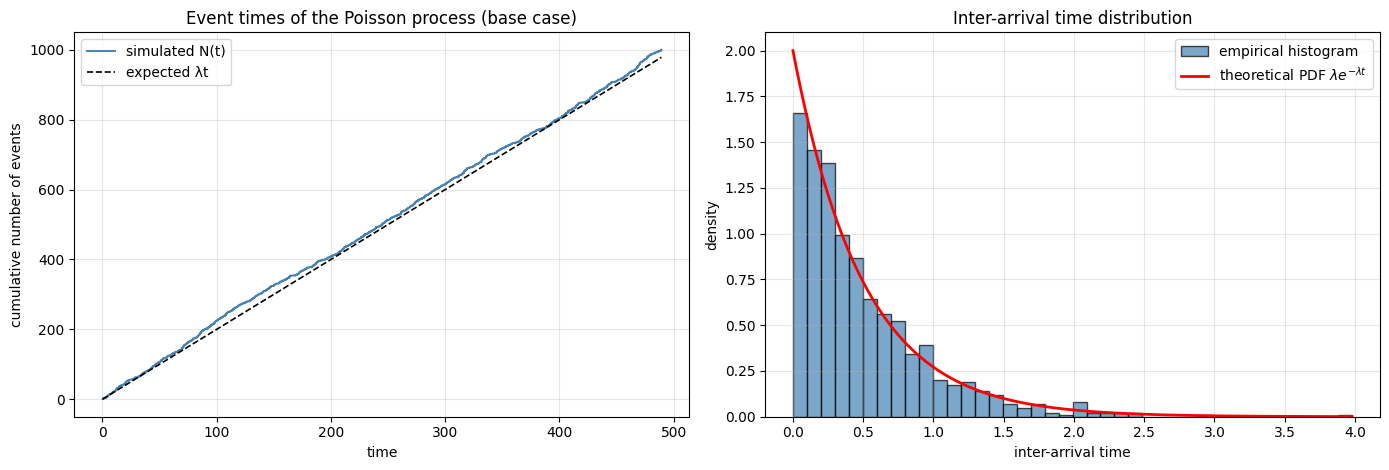

base case:  λ = 2 per time unit,  1000 events observed over 489.26 time units
  mean inter-arrival time : 0.4893   (theory 1/λ = 0.5000)
  std. deviation of gaps  : 0.4670   (theory 1/λ = 0.5000)
  observed arrival rate   : 2.0439 per time unit   (theory λ = 2)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import expon, poisson

def poisson_process_demo(lam, n_events, seed, title, unit, color):
    rng = np.random.default_rng(seed)
    inter = rng.exponential(scale=1 / lam, size=n_events)         # inter-arrival times ~ Exp(lam)
    times = np.cumsum(inter)                                      # event (arrival) times
    T_total = times[-1]

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
    ax[0].step(times, np.arange(1, n_events + 1), where='post', color=color, lw=1.4, label='simulated N(t)')
    ax[0].plot([0, T_total], [0, lam * T_total], 'k--', lw=1.2, label='expected λt')
    tl = 'time' if unit == 'time units' else f'time ({unit})'
    ax[0].set_title(f'Event times of the Poisson process ({title})'); ax[0].set_xlabel(tl); ax[0].set_ylabel('cumulative number of events'); ax[0].legend()

    ax[1].hist(inter, bins=40, density=True, alpha=0.7, color=color, edgecolor='black', label='empirical histogram')
    tg = np.linspace(0, inter.max(), 300)
    ax[1].plot(tg, lam * np.exp(-lam * tg), 'r-', lw=2, label=r'theoretical PDF $\lambda e^{-\lambda t}$')
    ax[1].set_title('Inter-arrival time distribution'); ax[1].set_xlabel('inter-arrival time' if unit == 'time units' else f'inter-arrival time ({unit})'); ax[1].set_ylabel('density'); ax[1].legend()
    for a_ in ax: a_.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    unit1 = unit[:-1] if unit.endswith("s") else unit          # singular form for "per ..."
    print(f"{title}:  λ = {lam} per {unit1},  {n_events} events observed over {T_total:.2f} {unit}")
    print(f"  mean inter-arrival time : {inter.mean():.4f}   (theory 1/λ = {1 / lam:.4f})")
    print(f"  std. deviation of gaps  : {inter.std(ddof=1):.4f}   (theory 1/λ = {1 / lam:.4f})")
    print(f"  observed arrival rate   : {n_events / T_total:.4f} per {unit1}   (theory λ = {lam})")
    return inter, times

inter_base, times_base = poisson_process_demo(2, 1000, seed=10, title='base case', unit='time units', color='steelblue')

# **Counts per unit interval are Poisson($\lambda$)**

Divide the time axis into intervals of length 1 and count the events in each. If the gaps are exponential, these counts must follow the Poisson distribution with mean $\lambda$ (and variance $\lambda$).

Number of events in [0, 2000)     : 3988   (expected λT = 4000)
Number of unit intervals observed : 2000
Mean count per interval           : 1.994   (theory λ = 2)
Variance of the counts            : 1.856   (theory λ = 2; for a Poisson variable mean = variance)


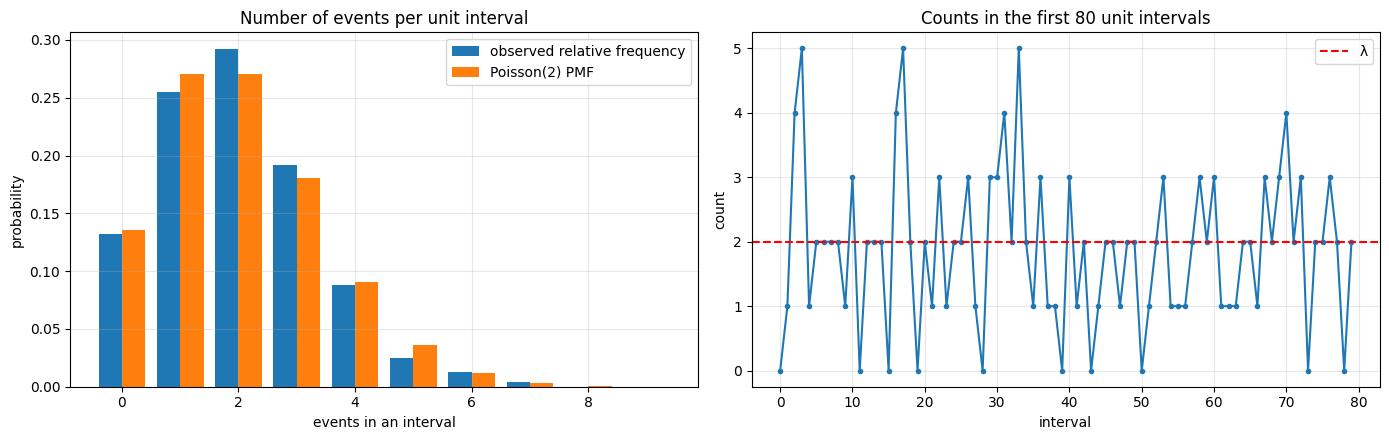

In [ ]:
lam = 2
T_obs = 2000                                                       # observe the process for 2000 time units
rng = np.random.default_rng(15)
gaps = rng.exponential(1 / lam, size=int(1.3 * lam * T_obs))      # more than enough gaps
event_times = np.cumsum(gaps)
event_times = event_times[event_times < T_obs]                    # keep the events inside [0, T_obs)
n_intervals = T_obs
counts = np.histogram(event_times, bins=np.arange(0, T_obs + 1))[0]

print(f"Number of events in [0, {T_obs})     : {len(event_times)}   (expected λT = {lam * T_obs})")
print(f"Number of unit intervals observed : {n_intervals}")
print(f"Mean count per interval           : {counts.mean():.3f}   (theory λ = {lam})")
print(f"Variance of the counts            : {counts.var(ddof=1):.3f}   (theory λ = {lam}; for a Poisson variable mean = variance)")

k = np.arange(0, 10)
freq = np.bincount(counts, minlength=10)[:10] / n_intervals
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(k - 0.2, freq, width=0.4, label='observed relative frequency')
ax[0].bar(k + 0.2, poisson.pmf(k, lam), width=0.4, label=f'Poisson({lam}) PMF')
ax[0].set_title('Number of events per unit interval'); ax[0].set_xlabel('events in an interval'); ax[0].set_ylabel('probability'); ax[0].legend()
ax[1].plot(counts[:80], 'o-', ms=3); ax[1].axhline(lam, color='red', ls='--', label='λ')
ax[1].set_title('Counts in the first 80 unit intervals'); ax[1].set_xlabel('interval'); ax[1].set_ylabel('count'); ax[1].legend()
for a_ in ax: a_.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Part 2 – Application Problem 1: customer arrivals at a service centre**

**Problem statement.** Customers arrive at a service centre randomly according to a Poisson process with an average arrival rate of **$\lambda=2$ customers per unit time**. Generate 1000 inter-arrival times, compute the cumulative arrival times and visualise the arrival process and the distribution of the inter-arrival times.

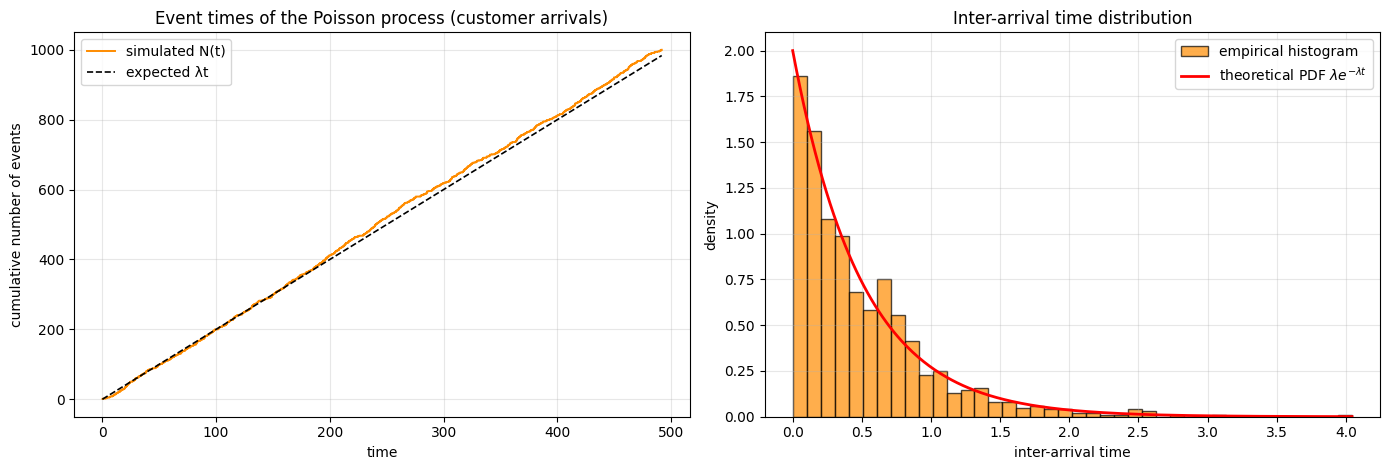

customer arrivals:  λ = 2 per time unit,  1000 events observed over 491.81 time units
  mean inter-arrival time : 0.4918   (theory 1/λ = 0.5000)
  std. deviation of gaps  : 0.4877   (theory 1/λ = 0.5000)
  observed arrival rate   : 2.0333 per time unit   (theory λ = 2)


In [ ]:
inter_service, times_service = poisson_process_demo(2, 1000, seed=21, title='customer arrivals', unit='time units', color='darkorange')

# **Part 3 – Application Problem 2: patient arrivals in a hospital emergency department**

**Problem statement.** A hospital emergency department wants to simulate patient arrivals to plan its staffing. Patient arrivals follow a Poisson process with a mean arrival rate of **$\lambda=3$ patients per hour**. Generate 1000 inter-arrival times, compute the actual arrival times, visualise the arrival process and confirm the exponential distribution with a histogram. In addition, find the probability that no patient arrives in a given 30-minute period.

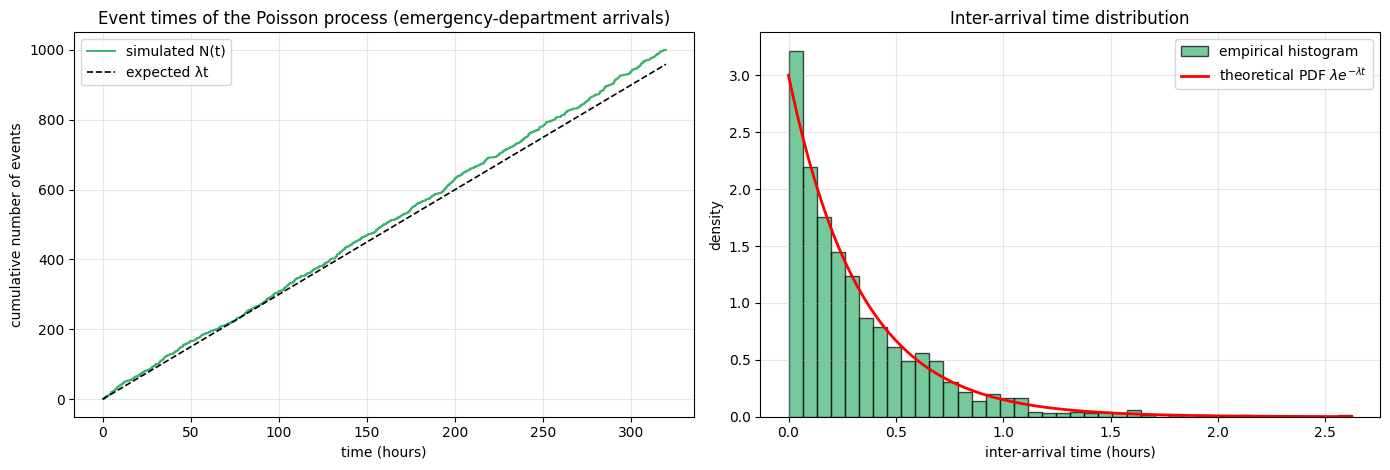

emergency-department arrivals:  λ = 3 per hour,  1000 events observed over 319.53 hours
  mean inter-arrival time : 0.3195   (theory 1/λ = 0.3333)
  std. deviation of gaps  : 0.3265   (theory 1/λ = 0.3333)
  observed arrival rate   : 3.1296 per hour   (theory λ = 3)

P(no patient in a 30-minute period) = P(N(0.5) = 0) = exp(-λ·0.5) = 0.2231
Observed fraction of 30-minute periods with no arrival = 0.2034
Mean number of patients per hour (simulated) = 3.130


In [ ]:
inter_hosp, times_hosp = poisson_process_demo(3, 1000, seed=31, title='emergency-department arrivals', unit='hours', color='mediumseagreen')

lam_h = 3
print(f"\nP(no patient in a 30-minute period) = P(N(0.5) = 0) = exp(-λ·0.5) = {np.exp(-lam_h * 0.5):.4f}")
half_hours = np.histogram(times_hosp, bins=np.arange(0, times_hosp[-1], 0.5))[0]
print(f"Observed fraction of 30-minute periods with no arrival = {np.mean(half_hours == 0):.4f}")
print(f"Mean number of patients per hour (simulated) = {1000 / times_hosp[-1]:.3f}")

# **Result and Discussion**

In [ ]:
rows = []
for name, lam_, inter_, times_ in (("Base case", 2, inter_base, times_base), ("Application 1 – service centre", 2, inter_service, times_service),
                                   ("Application 2 – hospital ED", 3, inter_hosp, times_hosp)):
    rows.append({"Part": name, "λ": lam_, "Theoretical mean gap 1/λ": 1 / lam_, "Observed mean gap": inter_.mean(),
                 "Theoretical std": 1 / lam_, "Observed std": inter_.std(ddof=1), "Observed rate": len(inter_) / times_[-1]})
display(pd.DataFrame(rows).set_index("Part").round(4))

,λ,Theoretical mean gap 1/λ,Observed mean gap,Theoretical std,Observed std,Observed rate
Part,,,,,,
Base case,2,0.5000,0.4893,0.5000,0.4670,2.0439
Application 1 – service centre,2,0.5000,0.4918,0.5000,0.4877,2.0333
Application 2 – hospital ED,3,0.3333,0.3195,0.3333,0.3265,3.1296


**Observations**

1. The step plots show events accumulating almost linearly, close to the line $\lambda t$, with small random fluctuations — the signature of a Poisson process.
2. The histograms of the gaps follow the exponential PDF $\lambda e^{-\lambda t}$ closely, and the observed mean and standard deviation agree with the theoretical value $1/\lambda$ (for the exponential distribution these two are equal).
3. A higher rate ($\lambda=3$ against $\lambda=2$) gives shorter gaps on average, a steeper PDF and a more densely populated step plot.
4. The number of events in unit intervals followed the Poisson($\lambda$) distribution with mean $\approx$ variance $\approx\lambda$.
5. The observed mean gap and observed rate approach $1/\lambda$ and $\lambda$ as the number of events grows (law of large numbers).

**Conclusion.** The simulation successfully models Poisson arrival processes for both the service-centre and the hospital scenarios; the exponential distribution of the inter-arrival times and the Poisson distribution of the counts were confirmed visually and numerically in all cases.

# **Practice Problems**

**Problem 1.** Simulate a Poisson process with rate $\lambda=5$ events per minute for 60 minutes. Compare the total number of events with the theoretical mean $\lambda t=300$ and repeat the simulation 200 times to estimate the standard deviation of the total (theory: $\sqrt{300}\approx17.3$).

**Problem 2.** Two independent Poisson processes with rates 2 and 3 are **merged**. Simulate each, merge the event times and show that the combined gaps have mean $1/5$ (the merged process is Poisson with rate 5).

**Problem 3.** Each event of a Poisson process of rate $\lambda=4$ is independently kept with probability $0.25$ ("thinning"). Simulate this and show that the retained events form a Poisson process with rate 1.

**Problem 4.** For the hospital model ($\lambda=3$ per hour) find (i) the probability that the waiting time for the next patient exceeds 30 minutes, (ii) the probability that at least 5 patients arrive in one hour, and (iii) the 95th percentile of the waiting time between patients.